# Exploratory Data Auditing: Anomaly Analysis (Revised)

## Revision notes — addressing R1 reviewer comments on visualisations

This notebook implements visualisation revisions in response to the second-round
referee reports on HDSR-2023-036R1. The substantive analyses are unchanged; the
revisions concern how figures are constructed and how supporting statistics are
reported.

| Manuscript figure | Reviewer concern | Revision |
|---|---|---|
| Fig. 1 | Histogram breaks undefined; bin straddling \$0 caused some positive expenses to be coloured red | Bin edges are explicit (\$5,000-wide steps anchored at \$0) so the sign of every bin is unambiguous |
| Fig. 3 | Grouped bars across eight categories were unreadable | Replaced with a small-multiples grid (one panel per category) sharing axes, each with the Benford reference line |
| Fig. 4 | Same grouped-bar issue across ten members | Replaced with a small-multiples grid (one panel per member) sharing axes, each with Benford and the across-member median |
| Fig. 6 | Dynamite (bar + CI) plots conceal the distribution; CIs were illegible; example panels were not aligned | Replaced with vertically stacked profile plots: a reference panel showing all member-quarter profiles, IQR band, and median, followed by four anomalous member-quarters drawn on the same category ordering |
| Figs. 7–8 | Paired boxplots preferable to bars; t-tests inappropriate for heavily skewed amounts; sample sizes unreported | Replaced with paired boxplots on a log x-axis; supplementary stats now report N per group, Welch's t on log10-transformed amounts, Cohen's d on the log scale, Mann–Whitney U, and rank-biserial r |
| Fig. 10 | "Collection of a child's coloured pencils"; mysterious black tips (Seaborn CI whiskers) | Replaced with a small-multiples grid: one boxplot panel per category with term quarter on the x-axis, no error-bar whiskers |
| Fig. 11 | Logarithmic binning over-weights short lags | Two panels: linear histogram (7-day bins) over the meaningful range, plus a complementary CDF on log–log axes so the tail is interpretable |
| Fig. 12 | Light/dark party–gender encoding was illegible; reviewer suggested dropping gender; full-page landscape orientation | Added an inline NetworkX rendering using party-only colours (Democratic / Republican / bipartisan) at landscape aspect ratio; the original `.gexf` export is preserved for Gephi |
| Fig. 13 | Log distance axis inconsistent with the linear model | Linear–linear axes for the model fit; a second panel shows residuals to motivate the discussion of nonlinearity at long distances |
| Discussion of staff affiliations | "1.31 ± 2.02" misleading when median and minimum are 1 | Replaced with median, IQR, max, and tail-share statistics |

Throughout the revision, colour assignments are now defined in the code immediately
adjacent to each figure so that the figure captions in the manuscript can document
them directly (per Reviewer 3's request to put colour definitions in captions
rather than in the surrounding prose).


# Exploratory Data Auditing: Anomaly Analysis
[Brian C. Keegan, Ph.D.](http://www.brianckeegan.com)
May 2026

Released under an [MIT License](https://opensource.org/licenses/MIT).

This notebook detects continuous, categorical, temporal, spatial, and network
anomalies in U.S. House *Statement of Disbursements* spending. It consumes the
single cleaned artifact produced by [`cleaning.ipynb`](cleaning.ipynb)
(`all_disbursements.csv`, Git-LFS-tracked) and performs **no schema
normalization or datetime parsing of its own** — that is the cleaning
notebook's contract. Analysis-specific transforms (personnel payee-name
normalization, gender/party/office enrichment, per-test statistical
subsetting) remain here by design.

## External inputs

Beyond the cleaned disbursements, the enrichment/reference inputs are produced
by `scripts/fetch_biographical.py` and read from local cached files so the
notebook is reproducible offline — the project's notebook discipline keeps
network retrieval out of the notebook itself:

- `propublica_members.csv` — member id → gender / party / name, built from the
  canonical [congress-legislators](https://unitedstates.github.io/congress-legislators/)
  roster (the legacy ProPublica Congress API this file is named after has been
  retired).
- `census_state.txt`, `census_cenpop2020.csv` — Census ANSI state codes and
  2020 [centers of population](https://www.census.gov/geographies/reference-files/time-series/geo/centers-population.html).
- `member_data_2015_2023.csv` — House Clerk `MemberData.xml` office
  building/room (Wayback Machine 2015–2023, with a live-clerk fallback).

Disbursements provenance:
[U.S. House Statement of Disbursements](https://disbursements.house.gov/),
normalized by `cleaning.ipynb`. Run `python scripts/fetch_biographical.py`
once before executing this notebook.

In [2]:
import numpy as np
import pandas as pd
pd.options.display.max_columns = 100

idx = pd.IndexSlice

pd.set_option('display.float_format', lambda x: '%.2f' % x)

%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.colors as mcolors
import seaborn as sb

from geopy.distance import geodesic

from scipy import stats
from scipy.spatial.distance import pdist, squareform, cosine


import networkx as nx

In [3]:
top_cats = [
    'PERSONNEL COMPENSATION',
    'FRANKED MAIL',
    'TRAVEL',
    'RENT COMMUNICATION UTILITIES',
    'PRINTING AND REPRODUCTION',
    'OTHER SERVICES',
    'SUPPLIES AND MATERIALS',
    'EQUIPMENT'
]

## Load data

### Centers of population

In [26]:
# Census ANSI state codes and 2020 centers of population — cached locally by
# scripts/fetch_biographical.py (canonical: https://www.census.gov/geographies
# /reference-files/time-series/geo/centers-population.html).
state_codes_df = pd.read_csv('census_state.txt', sep='|', dtype={'STATE': str})

cop_df = pd.read_csv('census_cenpop2020.csv', dtype={'STATEFP': str})

cop_df = pd.merge(
    left = cop_df,
    right = state_codes_df,
    left_on = 'STATEFP',
    right_on = 'STATE',
    how = 'outer'
)

# ['American Samoa','Guam','Northern Mariana Islands','Puerto Rico','U.S. Virgin Islands']
cop_df.loc[[51,52,53,54,56],'STATEFP'] = ['60', '66', '69', '72', '78']
cop_df.loc[[51,52,53,54,56],'LATITUDE'] = [-14.3,13.4,17.3,18.2,18.3]
cop_df.loc[[51,52,53,54,56],'LONGITUDE'] = [-170.7,144.8,145.4,-66.6,-64.9]
cop_df.loc[[51,52,53,54,56],'POPULATION'] = [49710,153836,47329,3285874,87146]

cop_df.drop(55,inplace=True)

cop_df['DC_DIST'] = cop_df[['LATITUDE','LONGITUDE']].apply(lambda x: geodesic((x['LATITUDE'],x['LONGITUDE']),(cop_df.loc[8,'LATITUDE'],cop_df.loc[8,'LONGITUDE'])).km,axis=1)

cop_df = cop_df[['STATEFP','STUSAB','STATE_NAME','POPULATION','LATITUDE','LONGITUDE','DC_DIST']]
cop_df

,STATEFP,STUSAB,STATE_NAME,POPULATION,LATITUDE,LONGITUDE,DC_DIST
0,01,AL,Alabama,5024279.00,33.02,-86.75,1094.14
1,02,AK,Alaska,733391.00,61.41,-148.96,5369.48
2,04,AZ,Arizona,7151502.00,33.37,-111.88,3177.83
3,05,AR,Arkansas,3011524.00,35.20,-92.71,1453.71
4,06,CA,California,39538223.00,35.49,-119.35,3743.74
5,08,CO,Colorado,5773714.00,39.53,-105.19,2423.75
6,09,CT,Connecticut,3605944.00,41.49,-72.88,454.00
7,10,DE,Delaware,989948.00,39.33,-75.55,135.23
8,11,DC,District of Columbia,689545.00,38.91,-77.01,0.00
9,12,FL,Florida,21538187.00,27.84,-81.64,1300.53


### Disbursements

In [25]:
# Single cleaned artifact produced by cleaning.ipynb (Git-LFS-tracked). All
# schema/datetime work happened upstream; this notebook only reads it.
all_db_df = pd.read_csv(
    'all_disbursements.csv',
    encoding='utf8',
    parse_dates=['DATE','PERIOD_DATE','START DATE','END DATE'],
    low_memory=False
)

all_db_df.head()

,YEAR-QUARTER,YEAR,QUARTER,TERM_QUARTER,BIOGUIDE_ID,OFFICE,PROGRAM,CATEGORY,PAYEE,PURPOSE,AMOUNT,DATE,PERIOD_DATE,DATE_IS_RECONSTRUCTED,START DATE,END DATE,TRANSCODE,RECORDID,VOUCHER_ID
0,2011Q1,2011,Q1,1,NaN,OFFICE OF THE SPEAKER,NaN,PERSONNEL COMPENSATION,"CASSIDY, ED",DIRECTOR OF HOUSE OPERATIONS,41066.67,NaT,2011-01-03,True,2011-01-03,2011-03-31,NaN,NaN,"CASSIDY, ED"
1,2011Q1,2011,Q1,1,NaN,OFFICE OF THE SPEAKER,NaN,PERSONNEL COMPENSATION,"DALY, BRENDAN",COMMUNICATIONS DIRECTOR,958.33,NaT,2011-01-01,True,2011-01-01,2011-01-02,NaN,NaN,"DALY, BRENDAN"
2,2011Q1,2011,Q1,1,NaN,OFFICE OF THE SPEAKER,NaN,PERSONNEL COMPENSATION,"DALY, BRENDAN",COMMUNICATIONS DIRECTOR (OTHER COMPENSATION),13416.67,NaT,2011-01-01,True,2011-01-01,2011-01-02,NaN,NaN,"DALY, BRENDAN"
3,2011Q1,2011,Q1,1,NaN,OFFICE OF THE SPEAKER,NaN,PERSONNEL COMPENSATION,"ELSHAMI,NADEEM",DEPUTY COMMUNICATIONS DIRECTOR,943.73,NaT,2011-01-01,True,2011-01-01,2011-01-02,NaN,NaN,"ELSHAMI,NADEEM"
4,2011Q1,2011,Q1,1,NaN,OFFICE OF THE SPEAKER,NaN,PERSONNEL COMPENSATION,"GREEN, JO-MARIE S",GEN COUNSEL & CHIEF OF LEG OPS,42044.44,NaT,2011-01-03,True,2011-01-03,2011-03-31,NaN,NaN,"GREEN, JO-MARIE S"


Integration contract with `cleaning.ipynb` — a loud failure here means the cleaned schema drifted. This notebook does no schema or datetime work itself.

In [27]:
EXPECTED_COLUMNS = [
    'YEAR-QUARTER','YEAR','QUARTER','TERM_QUARTER','BIOGUIDE_ID','OFFICE',
    'PROGRAM','CATEGORY','PAYEE','PURPOSE','AMOUNT','DATE','PERIOD_DATE',
    'DATE_IS_RECONSTRUCTED','START DATE','END DATE','TRANSCODE','RECORDID',
    'VOUCHER_ID']
assert list(all_db_df.columns) == EXPECTED_COLUMNS, all_db_df.columns.tolist()
for _c in ['DATE','PERIOD_DATE','START DATE','END DATE']:
    assert pd.api.types.is_datetime64_any_dtype(all_db_df[_c]), _c
assert all_db_df['YEAR'].min() == 2011, 'cleaned universe must start 2011'
print(f"contract OK: {len(all_db_df):,} rows x "
      f"{len(all_db_df.columns)} cols, "
      f"{all_db_df['YEAR-QUARTER'].nunique()} quarters")

contract OK: 6,040,756 rows x 19 cols, 58 quarters


Filter to members' expenses.

Filter to members' expenses. **Decision 3:** the source dropped `BIOGUIDE_ID` from 2023Q1 on, so member-level analyses below cover **2011–2022** by construction; 2023–2025 remain in the cleaned data at office level only.

In [129]:
members_df = all_db_df[all_db_df['BIOGUIDE_ID'].notnull()]
assert members_df['YEAR'].between(2011, 2022).all(), \
    'members_df must be 2011-2022 (Decision 3)'
members_df['BIOGUIDE_ID'].value_counts()

BIOGUIDE_ID
H001053    14696
G000565    14115
J000292    13588
K000376    13503
C001063    13270
           ...  
M000472        3
A000014        2
C000090        2
W000314        1
S001153        1
Name: count, Length: 938, dtype: int64

### Bioguide data

### Pro-Publica

In [130]:
propublica_members_df = pd.read_csv('propublica_members.csv')
propublica_members_df.head()

,bioguide_id,gender,party,first_name,last_name,type,district,state
0,C000127,F,Democrat,Maria,Cantwell,sen,NaN,WA
1,K000367,F,Democrat,Amy,Klobuchar,sen,NaN,MN
2,S000033,M,Independent,Bernard,Sanders,sen,NaN,VT
3,W000802,M,Democrat,Sheldon,Whitehouse,sen,NaN,RI
4,B001261,M,Republican,John,Barrasso,sen,NaN,WY


In [131]:
bioguide_gender_party_map = propublica_members_df[['bioguide_id','gender','party']].drop_duplicates(subset=['bioguide_id']).set_index('bioguide_id').to_dict('index')

member_names_map = propublica_members_df.copy()[['bioguide_id','first_name','last_name']]
member_names_map['full_name'] = member_names_map['first_name'] + ' ' + member_names_map['last_name']
member_names_map = member_names_map.drop_duplicates(subset=['bioguide_id']).set_index('bioguide_id')['full_name'].to_dict()

### Member data

### Member office data

The House Clerk `MemberData.xml` snapshots (office building/room, 2015–2023 via
the Wayback Machine with a live-clerk fallback) are retrieved by
`scripts/fetch_biographical.py` and cached as `member_data_2015_2023.csv`,
keeping this notebook free of slow, fragile network loops (notebook
discipline — analysis does no inline data retrieval).

In [31]:
member_data_df = pd.read_csv('member_data_2015_2023.csv',encoding='utf8')

Extract the office information.

In [33]:
member_office_df = member_data_df.copy()[['year','bioguideID','office-building','office-room']]

member_office_df['office-floor'] = np.nan
member_office_df['office-floor'] = member_office_df['office-floor'].astype('object')

_chob = member_office_df['office-building'] == 'CHOB'
member_office_df.loc[_chob,'office-floor'] = 'CHOB-' + member_office_df.loc[_chob,'office-room'].astype(str).str.get(0)

_lhob = member_office_df['office-building'] == 'LHOB'
member_office_df.loc[_lhob,'office-floor'] = 'LHOB-' + member_office_df.loc[_lhob,'office-room'].astype(str).str.get(1)

_rhob = member_office_df['office-building'] == 'RHOB'
member_office_df.loc[_rhob,'office-floor'] = 'RHOB-' + member_office_df.loc[_rhob,'office-room'].astype(str).str.get(1)

member_office_df.head()


,year,bioguideID,office-building,office-room,office-floor
0,2012,B001323,CHOB,153,CHOB-1
1,2012,M001212,LHOB,1511,LHOB-5
2,2012,F000481,CHOB,225,CHOB-2
3,2012,R000575,RHOB,2469,RHOB-4
4,2012,A000055,CHOB,272,CHOB-2


### Join

In [140]:
members_bioguide_df = pd.merge(
    left = members_df,
    right = propublica_members_df,
    left_on = 'BIOGUIDE_ID',
    right_on = 'bioguide_id',
    how = 'left'
)

members_bioguide_df.head()

,YEAR-QUARTER,YEAR,QUARTER,TERM_QUARTER,BIOGUIDE_ID,OFFICE,PROGRAM,CATEGORY,PAYEE,PURPOSE,AMOUNT,DATE,PERIOD_DATE,DATE_IS_RECONSTRUCTED,START DATE,END DATE,TRANSCODE,RECORDID,VOUCHER_ID,bioguide_id,gender,party,first_name,last_name,type,district,state
0,2011Q1,2011,Q1,1,A000014,HON. NEIL ABERCROMBIE,NaN,PERSONNEL COMPENSATION,"WESTFALL, ERIN K",RESEARCH AND MEDIA ASSISTANT,-16.67,NaT,2009-09-01,True,2009-09-01,2009-09-30,NaN,NaN,"WESTFALL, ERIN K",A000014,M,Democrat,Neil,Abercrombie,rep,1.00,HI
1,2011Q1,2011,Q1,1,A000022,HON. GARY L. ACKERMAN,NaN,FRANKED MAIL,UNITED STATES POSTAL SERVICE,FRANKED MAIL,183.23,2011-02-22,2011-02-22,False,2011-01-03,2011-01-31,AP,00100926,UNITED STATES POSTAL SERVICE,A000022,M,Democrat,Gary,Ackerman,rep,5.00,NY
2,2011Q1,2011,Q1,1,A000022,HON. GARY L. ACKERMAN,NaN,FRANKED MAIL,UNITED STATES POSTAL SERVICE,FRANKED MAIL,157.75,2011-03-28,2011-03-28,False,2011-02-01,2011-02-28,AP,00127739,UNITED STATES POSTAL SERVICE,A000022,M,Democrat,Gary,Ackerman,rep,5.00,NY
3,2011Q1,2011,Q1,1,A000022,HON. GARY L. ACKERMAN,NaN,FRANKED MAIL,NaN,FRANKED MAIL,-6.00,2011-03-31,2011-03-31,False,2011-03-20,2011-03-31,GL,FLG0007218,NaN,A000022,M,Democrat,Gary,Ackerman,rep,5.00,NY
4,2011Q1,2011,Q1,1,A000022,HON. GARY L. ACKERMAN,NaN,PERSONNEL COMPENSATION,"BERRY, UNA M",DISTRICT ADMINISTRATOR,19555.57,NaT,2011-01-03,True,2011-01-03,2011-03-31,NaN,NaN,"BERRY, UNA M",A000022,M,Democrat,Gary,Ackerman,rep,5.00,NY


## Continuous anomalies

### Outliers

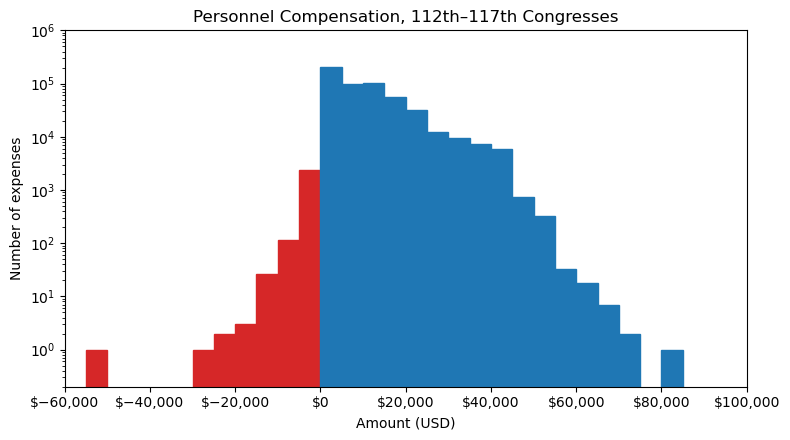

In [36]:
# Figure 1 (revised, R1 to Reviewer 3):
# Bin edges are defined explicitly so that $0 falls on a bin edge. Each bin is
# unambiguously non-positive (red) or non-negative (blue); no bin straddles $0.
# Bin width: $5,000. Colour key (per caption): blue = positive disbursement,
# red = negative (reimbursement).

_s = members_df.loc[members_df['CATEGORY'] == 'PERSONNEL COMPENSATION', 'AMOUNT']

bin_width = 5_000
bin_min = np.floor(_s.min() / bin_width) * bin_width
bin_max = np.ceil(_s.max() / bin_width) * bin_width
bins = np.arange(bin_min, bin_max + bin_width, bin_width)
assert 0.0 in bins, "Zero must be a bin edge so no bin straddles the sign boundary."

counts, bins = np.histogram(_s, bins=bins)

f, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(bins[:-1], bins, weights=counts)
ax.set_yscale('log')
ax.set_xlim((-60_000, 100_000))
ax.set_ylim((2e-1, 1e6))
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
ax.set_xlabel('Amount (USD)')
ax.set_ylabel('Number of expenses')
ax.set_title('Personnel Compensation, 112th–117th Congresses')

# Colour bins by sign: right edge <= 0 is wholly non-positive (red);
# left edge >= 0 is wholly non-negative (blue).
for _i in range(len(bins) - 1):
    if bins[_i + 1] <= 0:
        ax.patches[_i].set_color('tab:red')
    else:
        ax.patches[_i].set_color('tab:blue')

f.tight_layout()
f.savefig('personnel_compensation.png', dpi=300, bbox_inches='tight')


In [37]:
len(_s[_s > 50000]), len(_s[_s > 50000]) / len(_s)

(384, 0.0007139311391105979)

In [38]:
c0 = members_df['CATEGORY'] == 'PERSONNEL COMPENSATION'
c1 = members_df['AMOUNT'] > 50000
members_df.loc[c0 & c1,:].sort_values('AMOUNT',ascending=False)

,YEAR-QUARTER,YEAR,QUARTER,TERM_QUARTER,BIOGUIDE_ID,OFFICE,PROGRAM,CATEGORY,PAYEE,PURPOSE,AMOUNT,DATE,PERIOD_DATE,DATE_IS_RECONSTRUCTED,START DATE,END DATE,TRANSCODE,RECORDID,VOUCHER_ID
4748125,2022Q4,2022,Q4,8,M001166,2022 HON. JERRY MCNERNEY,OFFICIAL EXPENSES OF MEMBERS,PERSONNEL COMPENSATION,PROST GARY E,SR DISTRICT REPRESENTATIVE/ADV,81250.00,NaT,2022-03-01,True,2022-03-01,2022-12-31,GL,,
4767563,2022Q4,2022,Q4,8,S001199,2022 HON. LLOYD SMUCKER,OFFICIAL EXPENSES OF MEMBERS,PERSONNEL COMPENSATION,BONNER KATHERINE J.,CHIEF OF STAFF,71733.32,NaT,2022-01-03,True,2022-01-03,2022-12-31,GL,,
4757860,2022Q4,2022,Q4,8,P000610,2022 HON. STACEY E. PLASKETT,OFFICIAL EXPENSES OF MEMBERS,PERSONNEL COMPENSATION,JABBAR ANGELINE M,CHIEF OF STAFF,71083.29,NaT,2022-06-01,True,2022-06-01,2022-11-30,GL,,
4708705,2022Q4,2022,Q4,8,C001084,2022 HON. DAVID N. CICILLINE,OFFICIAL EXPENSES OF MEMBERS,PERSONNEL COMPENSATION,BIZZACCO CHRISTOPHER J,DISTRICT DIRECTOR,67416.63,NaT,2022-06-01,True,2022-06-01,2022-12-31,GL,,
4774632,2022Q4,2022,Q4,8,V000134,2022 HON. BETH VAN DUYNE,OFFICIAL EXPENSES OF MEMBERS,PERSONNEL COMPENSATION,OLSON JACOB N,CHIEF OF STAFF,67158.32,NaT,2022-06-01,True,2022-06-01,2022-12-31,GL,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4773211,2022Q4,2022,Q4,8,T000486,2022 HON. RITCHIE TORRES,OFFICIAL EXPENSES OF MEMBERS,PERSONNEL COMPENSATION,POLLOCK SOPHIE D.,DEPUTY CHIEF OF STAFF,50000.01,NaT,2022-10-01,True,2022-10-01,2022-12-31,GL,,
4731484,2022Q4,2022,Q4,8,H000874,2022 HON. STENY H. HOYER,OFFICIAL EXPENSES OF MEMBERS,PERSONNEL COMPENSATION,CAREY STEFANIE,DEPUTY DISTRICT DIRECTOR,50000.01,NaT,2022-10-01,True,2022-10-01,2022-12-31,GL,,
4766754,2022Q4,2022,Q4,8,S000510,2022 HON. ADAM SMITH,OFFICIAL EXPENSES OF MEMBERS,PERSONNEL COMPENSATION,SERVIN SARAH L,CHIEF OF STAFF,50000.01,NaT,2022-10-01,True,2022-10-01,2022-12-31,GL,,
2756136,2017Q4,2017,Q4,4,S001199,2017 HON. LLOYD SMUCKER,OFFICIAL EXPENSES OF MEMBERS,PERSONNEL COMPENSATION,FACCHIANO GREGORY,CHIEF OF STAFF,50000.01,NaT,2017-06-01,True,2017-06-01,2017-12-31,,,NaN


In [39]:
c2 = members_df['PAYEE'] == 'VERGHESE MATTHEW M'
members_df.loc[c0 & c1 & c2,:]

,YEAR-QUARTER,YEAR,QUARTER,TERM_QUARTER,BIOGUIDE_ID,OFFICE,PROGRAM,CATEGORY,PAYEE,PURPOSE,AMOUNT,DATE,PERIOD_DATE,DATE_IS_RECONSTRUCTED,START DATE,END DATE,TRANSCODE,RECORDID,VOUCHER_ID
4256663,2021Q4,2021,Q4,4,B001304,2021 HON. ANTHONY G. BROWN,OFFICIAL EXPENSES OF MEMBERS,PERSONNEL COMPENSATION,VERGHESE MATTHEW M,CHIEF OF STAFF,53000.00,NaT,2021-09-01,True,2021-09-01,2021-12-31,,,NaN
4471014,2022Q2,2022,Q2,6,B001304,2022 HON. ANTHONY G. BROWN,OFFICIAL EXPENSES OF MEMBERS,PERSONNEL COMPENSATION,VERGHESE MATTHEW M,CHIEF OF STAFF,51833.32,NaT,2022-03-01,True,2022-03-01,2022-06-30,,,NaN
4583111,2022Q3,2022,Q3,7,B001304,2022 HON. ANTHONY G. BROWN,OFFICIAL EXPENSES OF MEMBERS,PERSONNEL COMPENSATION,VERGHESE MATTHEW M,CHIEF OF STAFF,50750.01,NaT,2022-07-01,True,2022-07-01,2022-09-30,,,NaN
4702469,2022Q4,2022,Q4,8,B001304,2022 HON. ANTHONY G. BROWN,OFFICIAL EXPENSES OF MEMBERS,PERSONNEL COMPENSATION,VERGHESE MATTHEW M,CHIEF OF STAFF,50750.01,NaT,2022-10-01,True,2022-10-01,2022-12-31,GL,,


### Ending in even digits

HC: Both before and after the decimal

In [40]:
amounts = members_bioguide_df['AMOUNT'].dropna().apply(np.abs).map('{:.2f}'.format).astype(str)

two_digits_before = amounts.str.split('.').apply(lambda x:str(int(x[0][-2:])))
two_digits_after = amounts.str.split('.').apply(lambda x:x[1])

In [41]:
two_digits_before_counts = two_digits_before.value_counts()
two_digits_after_counts = two_digits_after.value_counts()

two_digits_before_counts.index = ["{0:02d}".format(int(i)) for i in two_digits_before_counts.index]
two_digits_after_counts.index = ["{0:02d}".format(int(i)) for i in two_digits_after_counts.index]

# last_two_digits_counts = last_two_digits_counts[last_two_digits_counts.index.astype(int) >= 0]

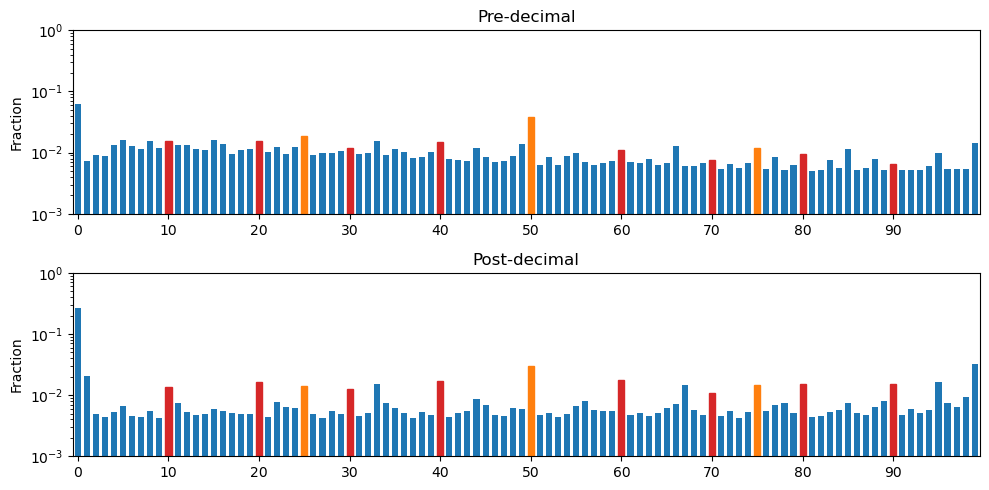

In [42]:
f,axs = plt.subplots(2,1,figsize=(10,5),subplot_kw={'yscale':'log','ylim':(1e-3,1e0),'ylabel':'Fraction'})

before_frac = two_digits_before_counts / two_digits_before_counts.sum()
after_frac = two_digits_after_counts / two_digits_after_counts.sum()

before_frac.sort_index().plot(width=.67, kind='bar',ax=axs[0])
after_frac.sort_index().plot(width=.67, kind='bar',ax=axs[1])

# axs[0].xaxis.set_major_locator(plt.MaxNLocator(90))
axs[0].set_xticks(range(0,100,10),range(0,100,10),rotation=0)
axs[1].set_xticks(range(0,100,10),range(0,100,10),rotation=0)

axs[0].set_title('Pre-decimal')
axs[1].set_title('Post-decimal')

axs[0].set_xlabel(None)
axs[1].set_xlabel(None)

for _i in range(0,100,10):
    if _i > 0:
        axs[0].patches[_i].set_color('tab:red')
        axs[1].patches[_i].set_color('tab:red')
    
for _i in range(0,100,25):
    if _i > 0:
        axs[0].patches[_i].set_color('tab:orange')
        axs[1].patches[_i].set_color('tab:orange')

f.tight_layout()
f.savefig('pre_post_decimal.png',dpi=300,bbox_inches='tight')

### Benford's law

In [44]:
benfords_d = {}

for i in range(1,10):
    benfords_d[str(i)] = np.log10(1+(1/i))
    
benfords_s = pd.Series(benfords_d)
benfords_s

1   0.30
2   0.18
3   0.12
4   0.10
5   0.08
6   0.07
7   0.06
8   0.05
9   0.05
dtype: float64

In [45]:
def leading_digits_count(s):
    if type(s) == pd.Series:
        _gt0 = s[s > 0]
        _str = _gt0.astype(str)
        _leading = _str.str.get(0)
        _not0 = _leading[_leading != '0']
        
        return _not0.value_counts().sort_index()

#### Aggregate

In [46]:
leading_digit_dist_by_cat = {}

for _cat in members_df['CATEGORY'].value_counts().iloc[:-3].index:
    _amount = members_df.loc[members_df['CATEGORY'] == _cat,'AMOUNT']
    leading_digit_dist_by_cat[_cat] = leading_digits_count(_amount)
#     leading_digit_dist_by_cat[_cat] = _leading_digits / _leading_digits.sum()

leading_digit_dist_by_cat_df = pd.DataFrame(leading_digit_dist_by_cat)

leading_digit_dist_by_cat_df

,TRAVEL,RENT COMMUNICATION UTILITIES,SUPPLIES AND MATERIALS,PERSONNEL COMPENSATION,OTHER SERVICES,PRINTING AND REPRODUCTION,FRANKED MAIL,EQUIPMENT
AMOUNT,,,,,,,,
1,286293,290642,202335,210391,94810,42932,23916,32674
2,191485,131491,121782,98304,30281,29808,14422,24521
3,133931,111496,92613,57153,28670,23645,9538,16260
4,97771,114079,71606,35941,10649,17659,6969,10039
5,77942,86635,55878,25789,12051,14509,5412,7719
6,61603,65639,47341,21541,5855,12323,4437,4646
7,49147,51084,37181,23408,7339,10911,3925,4095
8,44113,49203,32427,28740,3826,7639,3547,4397
9,38828,40484,30296,33928,4469,9308,3294,3364


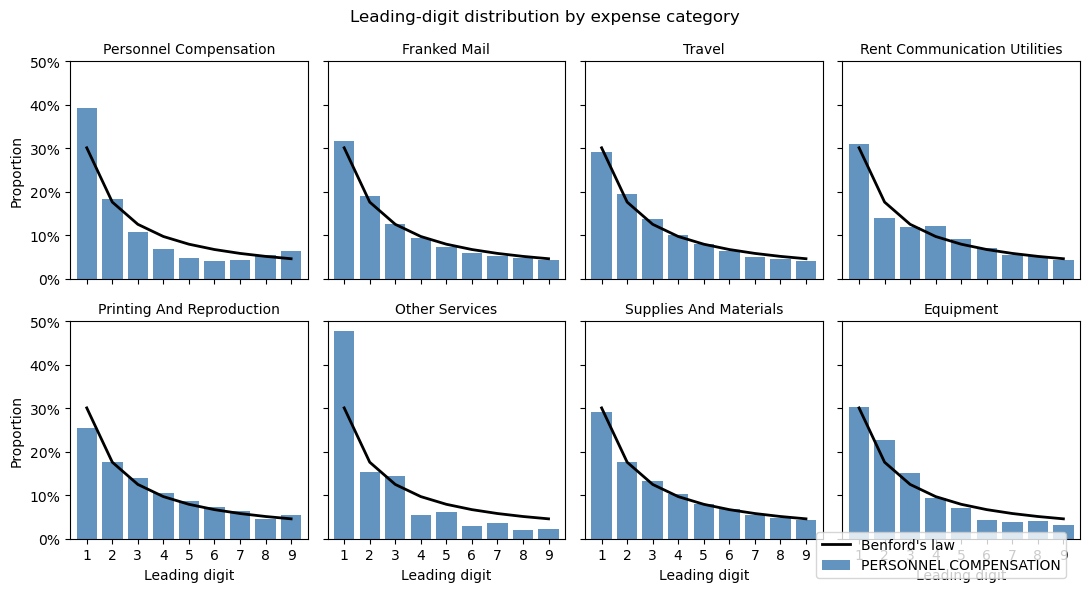

In [47]:
# Figure 3 (revised, R1 to Reviewer 3):
# Small multiples replace the previous grouped bars; the eight expense
# categories now each have their own panel with the Benford reference line.
# Colour key (per caption): blue bars = observed leading-digit share,
# black line = Benford expectation.

leading_digit_dist_by_cat_norm_df = leading_digit_dist_by_cat_df / leading_digit_dist_by_cat_df.sum()

categories = [c for c in top_cats if c in leading_digit_dist_by_cat_norm_df.columns]
n_cats = len(categories)
n_cols = 4
n_rows = int(np.ceil(n_cats / n_cols))

f, axs = plt.subplots(n_rows, n_cols, figsize=(11, 3 * n_rows), sharex=True, sharey=True)
axs = np.array(axs).flatten()

for i, _cat in enumerate(categories):
    ax = axs[i]
    leading_digit_dist_by_cat_norm_df[_cat].plot(
        kind='bar', ax=ax, color='steelblue', width=0.8, alpha=0.85
    )
    benfords_s.plot(ax=ax, color='black', lw=2, label="Benford's law", zorder=10)
    ax.set_title(_cat.title(), fontsize=10)
    ax.set_xticks(range(9))
    ax.set_xticklabels(range(1, 10), rotation=0)
    ax.set_ylim((0, 0.5))
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
    if i % n_cols == 0:
        ax.set_ylabel('Proportion')
    if i >= n_cats - n_cols:
        ax.set_xlabel('Leading digit')

for j in range(n_cats, len(axs)):
    axs[j].axis('off')

handles, labels = axs[0].get_legend_handles_labels()
f.legend(handles, labels, loc='lower right', bbox_to_anchor=(0.98, 0.02), fontsize=10)

f.suptitle("Leading-digit distribution by expense category", fontsize=12)
f.tight_layout()
f.savefig('benford_all_cat.png', dpi=300, bbox_inches='tight')


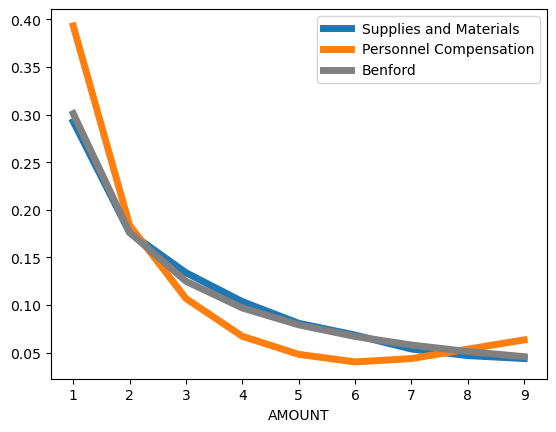

In [48]:
f,ax = plt.subplots()
leading_digit_dist_by_cat_norm_df['SUPPLIES AND MATERIALS'].plot(lw=5,label='Supplies and Materials',ax=ax)
leading_digit_dist_by_cat_norm_df['PERSONNEL COMPENSATION'].plot(lw=5,label='Personnel Compensation',ax=ax)
benfords_s.plot(ax=ax,lw=5,label='Benford',c='grey')
ax.legend()

In [49]:
dist_test_by_col = {}

for _col in leading_digit_dist_by_cat_df.columns:
    
    _col_vals = leading_digit_dist_by_cat_df.loc[:,_col]
    _exp_vals = _col_vals.sum() * benfords_s
    
    _ks_test = stats.ks_2samp(_col_vals,_exp_vals)
    _chi2_test = stats.chisquare(_col_vals,_exp_vals)
    
    dist_test_by_col[_col] = {
        'ks_statistic':_ks_test.statistic,'ks_pvalue':_ks_test.pvalue,
        'chi2_statistic':_chi2_test.statistic,'chi2_pvalue':_chi2_test.pvalue
    }
        
dist_test_df = pd.DataFrame(dist_test_by_col).T
dist_test_df.sort_values('chi2_statistic',ascending=False)

,ks_statistic,ks_pvalue,chi2_statistic,chi2_pvalue
PERSONNEL COMPENSATION,0.22,0.99,39322.77,0.00
OTHER SERVICES,0.44,0.35,38546.60,0.00
RENT COMMUNICATION UTILITIES,0.11,1.00,15800.98,0.00
TRAVEL,0.22,0.99,6297.38,0.00
EQUIPMENT,0.44,0.35,4678.67,0.00
PRINTING AND REPRODUCTION,0.11,1.00,2395.30,0.00
SUPPLIES AND MATERIALS,0.11,1.00,1487.32,0.00
FRANKED MAIL,0.11,1.00,384.73,0.00


In [50]:
stats.zscore(leading_digit_dist_by_cat_df,axis=1)

array([[ 1.31202167e+00,  1.35328150e+00,  5.15495320e-01,
         5.91924204e-01, -5.04615873e-01, -9.96792842e-01,
        -1.17720144e+00, -1.09411254e+00],
       [ 1.83066298e+00,  8.43200423e-01,  6.83396543e-01,
         2.96963802e-01, -8.22650918e-01, -8.30436193e-01,
        -1.08367983e+00, -9.17456804e-01],
       [ 1.67465470e+00,  1.17215358e+00,  7.49210468e-01,
        -4.50257579e-02, -6.82990519e-01, -7.95540915e-01,
        -1.11151075e+00, -9.60950800e-01],
       [ 1.29747039e+00,  1.70295883e+00,  6.46893675e-01,
        -2.39894724e-01, -8.68764825e-01, -6.94465465e-01,
        -9.60265773e-01, -8.83932102e-01],
       [ 1.36980552e+00,  1.65197813e+00,  6.53613591e-01,
        -3.23067838e-01, -7.68999889e-01, -6.89213822e-01,
        -9.84500172e-01, -9.09615528e-01],
       [ 1.37520504e+00,  1.54000160e+00,  7.92863974e-01,
        -2.60592727e-01, -9.01078068e-01, -6.36978923e-01,
        -9.58977355e-01, -9.50443539e-01],
       [ 1.38064449e+00,  1.484457

#### By representative

In [51]:
transaction_count = members_df['BIOGUIDE_ID'].value_counts()
members_gt1000_transactions = transaction_count[transaction_count >= 1000].index

In [52]:
leading_digit_dist_by_member = {}

for _member in members_gt1000_transactions:
    _amount = members_df.loc[members_df['BIOGUIDE_ID'] == _member,'AMOUNT']
    leading_digit_dist_by_member[_member] = leading_digits_count(_amount)
#     leading_digit_dist_by_member[_member] = _leading_digits / _leading_digits.sum()
    
leading_digit_dist_by_member_df = pd.DataFrame(leading_digit_dist_by_member)

leading_digit_dist_by_member_df

,H001053,G000565,J000292,K000376,C001063,P000601,T000193,S001172,S001185,C001051,G000546,L000491,M001157,J000032,W000809,H001058,D000600,L000566,B001270,P000597,F000449,S000522,D000616,L000551,K000009,F000459,A000055,D000615,S001177,M000087,S001148,C001061,K000362,C001053,B001248,D000191,C001087,W000791,S001150,S001195,G000551,C001080,M001165,F000450,G000552,W000800,S001192,W000795,T000460,G000553,...,Q000024,M001154,B000220,M001207,M001215,B001232,M000687,G000580,M001214,P000149,F000339,C001085,B001280,M001186,L000553,K000336,O000086,T000326,G000597,A000358,P000583,S001218,K000390,S000937,M001135,G000021,A000366,G000575,S000810,M001211,H001062,F000471,I000026,T000486,B001234,N000192,D000492,E000071,J000305,H001078,A000373,R000462,R000611,F000444,G000595,S001210,T000473,C001116,R000305,G000480
AMOUNT,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,4665,4398,3784,4174,4255,3766,4095,3994,3880,3681,3451,3790,3824,3686,3446,3218,3108,3549,3190,3538,2862,2757,3128,3370,3248,2920,3519,2729,3204,2710,3246,3013,2947,3194,2634,3155,2999,2789,3141,3475,2719,2998,3039,3186,2462,2956,2969,2774,3533,2881,...,369,412,318,402,432,360,359,459,473,356,346,378,361,447,374,318,350,390,395,328,342,391,363,315,323,305,394,323,321,341,328,372,321,371,336,393,310,357,347,376,325,267,319,270,308,300,294,331,330,315
2,2613,2560,2267,2264,2232,1901,2137,1919,2167,2039,1885,1999,1921,1929,2202,1849,2339,1792,1800,2138,1777,2259,1601,1669,1801,1855,1591,1804,1692,1581,1740,1414,1728,1691,1800,1842,1516,1735,1441,1417,1665,1606,1387,1622,1854,1885,1484,1633,1525,1354,...,193,175,251,177,205,208,199,200,217,277,207,206,197,186,163,267,222,152,177,218,179,200,190,218,190,178,176,186,160,199,202,222,154,193,138,169,146,191,168,190,162,173,146,184,215,215,141,185,169,158
3,1668,2108,2058,1687,1396,1896,1754,1317,1445,1444,1393,1437,1582,1318,1416,1395,1347,1547,1379,1193,1509,1548,1318,1328,1437,1273,1068,1187,1289,1217,1310,1207,1127,1268,1375,1364,1580,1129,1047,1190,1384,956,798,962,1101,1079,1385,1150,927,1101,...,155,206,173,169,148,106,170,129,123,149,168,131,193,127,160,191,164,88,123,159,159,159,135,173,177,127,121,172,79,112,147,145,99,117,129,125,117,149,135,98,184,91,169,118,102,137,116,131,122,201
4,1406,1162,1554,1381,1077,1191,1020,1294,1191,1100,1322,1369,1295,894,1127,1204,919,814,1142,923,1287,979,1185,811,1032,1071,1017,1008,773,1023,881,1019,951,1021,1386,850,915,992,923,801,989,859,781,885,1379,1054,1003,1043,777,1241,...,154,116,140,146,118,160,145,130,96,144,106,134,145,127,126,107,118,152,72,112,143,121,118,107,114,164,111,88,150,136,129,84,150,105,108,91,82,112,118,129,86,98,130,125,119,85,121,75,98,84
5,1068,1061,1065,990,993,826,863,816,967,1060,1253,747,973,905,798,908,737,924,1144,724,958,666,707,775,778,665,781,883,1028,869,805,886,862,573,763,559,702,880,776,718,737,654,1088,849,528,804,695,771,560,639,...,103,54,123,90,77,94,130,81,86,96,82,97,76,85,140,54,109,139,138,94,77,64,83,76,90,89,93,68,131,57,69,62,97,123,91,88,128,62,100,75,53,120,47,98,57,40,73,57,88,50
6,735,753,808,797,871,795,582,726,636,681,632,705,540,742,788,719,524,694,740,647,685,719,609,508,572,721,589,667,562,745,523,669,726,611,567,631,602,703,768,584,743,643,921,558,345,426,556,600,554,759,...,80,63,53,77,59,72,79,39,89,69,109,86,67,58,94,101,75,46,68,88,91,66,54,90,76,94,104,93,92,41,55,52,77,44,109,57,103,66,67,37,75,99,60,105,66,39,80,39,45,45
7,916,619,727,670,759,847,574,522,612,574,637,633,605,627,796,499,731,408,452,510,479,496,584,551,491,446,615,826,628,678,454,619,592,613,420,428,504,472,652,480,571,657,547,450,451,404,411,426,418,450,...,80,117,70,63,43,69,55,68,61,56,57,56,47,34,47,54,54,72,74,55,49,51,51,41,42,41,44,75,80,81,51,38,50,41,60,40,41,33,41,48,75,49,34,30,51,40,65,40,33,44
8,578,577,465,530,664,648,542,786,410,506,625,439,486,885,472,499,573,393,480,367,379,443,533,501,390,420,489,500,537,515,459,422,475,329,415,492,385,436,393,474,441,481,370,370,561,377,347,413,307,320,...,45

In [53]:
ks_test_by_member = {}
for _member in leading_digit_dist_by_member_df.columns:
    _col_vals = leading_digit_dist_by_member_df[_member]
    _exp_vals = _col_vals.sum() * benfords_s
    
    _ks_test = stats.ks_2samp(_col_vals,_exp_vals)
    _chi2_test = stats.chisquare(_col_vals,_exp_vals)
    
    ks_test_by_member[_member] = {
        'ks_statistic':_ks_test.statistic,'ks_pvalue':_ks_test.pvalue,
        'chi2_statistic':_chi2_test.statistic,'chi2_pvalue':_chi2_test.pvalue
    }
        
dist_test_by_member_df = pd.DataFrame(ks_test_by_member).T
dist_test_by_member_df.sort_values('chi2_statistic',ascending=False).head(20)

,ks_statistic,ks_pvalue,chi2_statistic,chi2_pvalue
V000081,0.22,0.99,631.04,0.00
G000552,0.22,0.99,548.38,0.00
P000034,0.44,0.35,526.51,0.00
M001165,0.22,0.99,525.11,0.00
R000486,0.22,0.99,520.15,0.00
S001189,0.33,0.73,469.03,0.00
T000460,0.22,0.99,443.14,0.00
P000609,0.44,0.35,411.52,0.00
B001248,0.33,0.73,404.34,0.00
L000397,0.33,0.73,377.42,0.00


#### Member-level travel

In [54]:
leading_digit_dist_by_member_travel = {}

for _member in members_gt1000_transactions:
    _amount = members_df.loc[(members_df['BIOGUIDE_ID'] == _member) & (members_df['CATEGORY'] == 'TRAVEL'),'AMOUNT']
    leading_digit_dist_by_member_travel[_member] = leading_digits_count(_amount)
#     leading_digit_dist_by_member_travel[_member] = _leading_digits / _leading_digits.sum()
    
leading_digit_dist_by_member_travel_df = pd.DataFrame(leading_digit_dist_by_member_travel)

leading_digit_dist_by_member_travel_df

,H001053,G000565,J000292,K000376,C001063,P000601,T000193,S001172,S001185,C001051,G000546,L000491,M001157,J000032,W000809,H001058,D000600,L000566,B001270,P000597,F000449,S000522,D000616,L000551,K000009,F000459,A000055,D000615,S001177,M000087,S001148,C001061,K000362,C001053,B001248,D000191,C001087,W000791,S001150,S001195,G000551,C001080,M001165,F000450,G000552,W000800,S001192,W000795,T000460,G000553,...,Q000024,M001154,B000220,M001207,M001215,B001232,M000687,G000580,M001214,P000149,F000339,C001085,B001280,M001186,L000553,K000336,O000086,T000326,G000597,A000358,P000583,S001218,K000390,S000937,M001135,G000021,A000366,G000575,S000810,M001211,H001062,F000471,I000026,T000486,B001234,N000192,D000492,E000071,J000305,H001078,A000373,R000462,R000611,F000444,G000595,S001210,T000473,C001116,R000305,G000480
AMOUNT,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,1814,2123,1162,1009,843,690,754,1214,676,1228,1371,1568,1135,623,1131,1021,912,854,1063,1043,1042,559,874,600,883,790,726,811,881,854,691,621,901,771,614,913,1136,933,650,763,575,920,351,680,271,797,1162,752,705,525,...,65,91,66,70,150,73,8.00,54,138,46,60,95,64,111,35,92,60,53,86,74,49,113,116,40,54,57,51,75,37,108,89,91,70,92,32,98,36,49,59,114,61,26,32,43,58,107,66,124,37,92
2,1123,1384,787,760,666,473,521,685,692,791,773,1021,819,305,779,748,805,599,729,725,725,956,530,426,589,623,610,710,692,540,390,434,530,564,532,349,581,522,508,390,441,501,225,489,295,621,687,535,354,263,...,32,35,43,59,101,47,6.00,47,92,99,28,44,63,47,32,51,37,42,65,54,26,63,70,31,46,54,47,46,20,69,60,82,37,51,25,43,19,46,31,72,37,25,33,31,74,77,20,66,29,58
3,660,1306,721,535,366,318,421,481,481,645,556,657,597,325,462,563,512,430,578,532,566,414,479,296,442,402,401,505,423,406,315,275,424,375,336,253,433,460,350,355,405,375,168,292,162,451,540,255,266,212,...,32,24,41,35,76,28,6.00,32,40,73,24,26,40,64,50,28,62,21,36,24,15,66,43,12,49,22,26,29,17,51,52,68,24,36,7,19,10,73,36,33,26,14,25,15,23,27,28,29,25,31
4,553,616,653,387,282,254,253,399,291,377,588,473,393,157,287,372,554,247,415,420,298,375,378,288,245,318,349,459,282,296,247,244,405,288,628,248,281,284,248,209,244,252,215,337,339,288,440,173,180,335,...,31,37,32,73,49,22,61.00,26,27,22,16,22,31,29,14,22,54,15,10,24,15,36,23,13,30,16,15,24,21,45,33,27,17,28,3,27,10,35,19,21,15,7,16,14,29,23,30,26,13,24
5,365,590,459,329,278,233,181,312,308,360,558,371,361,128,229,328,365,132,358,238,241,145,252,322,199,218,219,441,252,233,370,175,320,216,180,183,226,254,211,163,241,195,144,189,101,212,408,237,129,162,...,14,19,28,22,47,24,17.00,14,21,14,13,5,19,26,32,14,54,12,39,19,26,29,30,11,33,15,20,13,9,15,22,21,14,50,3,39,45,12,20,24,10,3,12,18,19,11,16,14,16,18
6,277,404,285,195,186,176,139,353,166,265,319,295,226,183,264,287,269,129,306,169,172,102,211,143,214,227,226,295,203,192,182,189,252,188,149,194,207,189,268,94,173,177,116,136,56,88,235,155,116,139,...,16,13,10,14,31,17,2.00,6,23,13,10,17,13,21,5,16,31,9,24,11,17,29,17,16,11,14,13,17,4,15,14,7,12,22,3,24,29,25,27,11,10,7,10,17,35,10,13,5,9,20
7,256,304,236,185,149,199,136,176,121,194,232,232,151,164,159,224,279,88,187,130,176,100,190,138,113,113,198,313,110,163,131,136,162,137,115,172,176,161,132,112,148,142,79,172,63,94,187,111,98,124,...,12,9,14,13,29,19,1.00,19,11,5,6,17,12,12,1,16,21,13,22,15,5,23,23,10,10,11,7,10,8,30,14,7,12,4,28,9,6,4,20,9,12,7,7,8,17,12,9,6,5,23
8,204,255,199,181,127,169,96,270,80,214,244,172,148,80,161,201,210,141,179,151,120,104,142,126,95,120,120,175,163,188,184,97,145,99,134,139,127,201,133,100,102,144,73,75,76,117,196,99,58,94,...,16,21,9,5,36,17,NaN,4,9,3,6,9,32,7,5,10,17,7,10,13,6,9,22,3,8,3,2,15,15,10,14,12,8,12,7,12,3,12,18,8,9,3,5,8,14,14,27,6,4,14
9,270,230,168,144,86,129,67,207,123,158,189,290,123,98,98,146,98,109,114,122,114,91,134,117,66,85,90,146,119,143,87,118,157,95,93,164,104,180,105,122,71,120,66,90,32,81,181,80,95,107,...,14,8,10,7,21,16,3.00,6,6,8,2,14,6,8,6,11,20,16,18,13,9,17,17,7,10,7,7,11,6,13,18,36,5,

In [55]:
ks_test_by_member_travel = {}

for _member in leading_digit_dist_by_member_travel_df.columns:
    _col_vals = leading_digit_dist_by_member_travel_df.loc[:,_member]
    _exp_vals = _col_vals.sum() * benfords_s
    
    _ks_test = stats.ks_2samp(_col_vals,_exp_vals)
    _chi2_test = stats.chisquare(_col_vals,_exp_vals)
    
    ks_test_by_member_travel[_member] = {
        'ks_statistic':_ks_test.statistic,'ks_pvalue':_ks_test.pvalue,
        'chi2_statistic':_chi2_test.statistic,'chi2_pvalue':_chi2_test.pvalue
    }
        
dist_test_by_member_travel_df = pd.DataFrame(ks_test_by_member_travel).T
dist_test_by_member_travel_df.sort_values('chi2_statistic',ascending=False).head(20)

,ks_statistic,ks_pvalue,chi2_statistic,chi2_pvalue
V000081,0.44,0.35,955.10,0.00
S000185,0.33,0.73,932.78,0.00
S000522,0.44,0.35,680.67,0.00
B001248,0.22,0.99,578.12,0.00
S001165,0.44,0.35,483.12,0.00
S000244,0.33,0.73,481.45,0.00
M001143,0.22,0.99,441.67,0.00
L000559,0.44,0.35,433.72,0.00
H000067,0.22,0.99,418.96,0.00
W000207,0.22,0.99,413.50,0.00


Inspect.

In [56]:
c0 = members_df['BIOGUIDE_ID'] == 'V000081'
c1 = members_df['CATEGORY'] == 'TRAVEL'

_df = members_df.copy().loc[c0 & c1,:]

_df['leading'] = _df['AMOUNT'].apply(np.abs).astype(str).str.get(0)

_df.head()

,YEAR-QUARTER,YEAR,QUARTER,TERM_QUARTER,BIOGUIDE_ID,OFFICE,PROGRAM,CATEGORY,PAYEE,PURPOSE,AMOUNT,DATE,PERIOD_DATE,DATE_IS_RECONSTRUCTED,START DATE,END DATE,TRANSCODE,RECORDID,VOUCHER_ID,leading
97626,2011Q1,2011,Q1,1,V000081,HON. NYDIA M. VELAZQUEZ,NaN,TRAVEL,CITIBANK GOV CARD SERVICE,COMMERCIAL TRANSPORTATION,62.70,2011-02-18,2011-02-18,False,2011-01-05,2011-01-05,AP,00097608,CITIBANK GOV CARD SERVICE,6
97627,2011Q1,2011,Q1,1,V000081,HON. NYDIA M. VELAZQUEZ,NaN,TRAVEL,CITIBANK GOV CARD SERVICE,COMMERCIAL TRANSPORTATION,162.00,2011-02-18,2011-02-18,False,2011-01-07,2011-01-07,AP,00097609,CITIBANK GOV CARD SERVICE,1
97628,2011Q1,2011,Q1,1,V000081,HON. NYDIA M. VELAZQUEZ,NaN,TRAVEL,CITIBANK GOV CARD SERVICE,COMMERCIAL TRANSPORTATION,167.00,2011-02-18,2011-02-18,False,2011-01-18,2011-01-18,AP,00097610,CITIBANK GOV CARD SERVICE,1
97629,2011Q1,2011,Q1,1,V000081,HON. NYDIA M. VELAZQUEZ,NaN,TRAVEL,CITIBANK GOV CARD SERVICE,COMMERCIAL TRANSPORTATION,62.70,2011-02-18,2011-02-18,False,2011-01-22,2011-01-22,AP,00097611,CITIBANK GOV CARD SERVICE,6
97630,2011Q1,2011,Q1,1,V000081,HON. NYDIA M. VELAZQUEZ,NaN,TRAVEL,CITIBANK GOV CARD SERVICE,COMMERCIAL TRANSPORTATION,62.70,2011-02-18,2011-02-18,False,2011-01-24,2011-01-24,AP,00097612,CITIBANK GOV CARD SERVICE,6


In [57]:
_df['leading'].value_counts(normalize=True)

leading
6   0.29
1   0.23
5   0.15
2   0.10
3   0.10
9   0.03
4   0.03
7   0.03
8   0.03
0   0.00
Name: proportion, dtype: float64

In [58]:
_df.loc[_df['leading'] == '6','AMOUNT']

97626      62.70
97629      62.70
97630      62.70
97632      62.70
97633      62.70
           ...  
4667498    62.60
4667501   660.54
4775297    62.60
4775299    62.60
4775305    60.58
Name: AMOUNT, Length: 291, dtype: float64

Is there a difference between the median distribution of digits and Benford's law?

In [59]:
leading_digit_dist_by_member_travel_norm_df = leading_digit_dist_by_member_travel_df / leading_digit_dist_by_member_travel_df.sum()
top10_members_travel = leading_digit_dist_by_member_travel_norm_df.loc[:,dist_test_by_member_travel_df.sort_values('chi2_statistic',ascending=False).head(10).index]
bot10_members_travel = leading_digit_dist_by_member_travel_norm_df.loc[:,dist_test_by_member_travel_df.sort_values('chi2_statistic').head(10).index]

leading_digit_travel_median = leading_digit_dist_by_member_travel_df.median(1)
leading_digit_travel_median_norm = leading_digit_travel_median/leading_digit_travel_median.sum()

stats.chisquare(leading_digit_travel_median,leading_digit_travel_median.sum() * benfords_s)


/var/folders/lr/v195xr617d32k2zdwwh30sb40000gn/T/ipykernel_77558/3077801600.py:5: Pandas4Warning: Starting with pandas version 4.0 all arguments of median will be keyword-only.
  leading_digit_travel_median = leading_digit_dist_by_member_travel_df.median(1)


Power_divergenceResult(statistic=np.float64(9.360229051392377), pvalue=np.float64(0.3128244668810842))

In [60]:
# Helper for revised Figure 4 (R1 to Reviewer 3):
# Render Benford comparisons as small multiples — one subplot per member,
# shared axes, with both the Benford reference and the median across members.

def plot_member_benford_smallmult(members_to_plot, benfords_s, median_norm,
                                  title, fname, ylim=0.5, n_cols=5):
    """Small-multiples Benford comparison. One panel per member.

    Colour key (for caption): steelblue bars = observed leading-digit share
    for that member; solid black line = Benford expectation; dashed grey line
    = median across all members in the comparison set.
    """
    n = members_to_plot.shape[1]
    n_rows = int(np.ceil(n / n_cols))

    f, axs = plt.subplots(n_rows, n_cols, figsize=(14, 2.6 * n_rows),
                          sharex=True, sharey=True)
    axs = np.array(axs).flatten()

    for i, member in enumerate(members_to_plot.columns):
        ax = axs[i]
        members_to_plot[member].plot(
            kind='bar', ax=ax, color='steelblue', alpha=0.85, width=0.8
        )
        benfords_s.plot(ax=ax, color='black', lw=1.5, label="Benford")
        median_norm.plot(ax=ax, color='grey', lw=1.5, ls='--',
                         label='Median across members')
        ax.set_title(member, fontsize=10)
        ax.set_xticks(range(9))
        ax.set_xticklabels(range(1, 10), rotation=0)
        ax.set_ylim((0, ylim))
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
        if i % n_cols == 0:
            ax.set_ylabel('Proportion')
        if i >= n - n_cols:
            ax.set_xlabel('Leading digit')

    for j in range(n, len(axs)):
        axs[j].axis('off')

    handles, labels = axs[0].get_legend_handles_labels()
    # Take only the two reference lines, not the bar.
    f.legend(handles[-2:], labels[-2:], loc='lower right',
             bbox_to_anchor=(0.98, 0.02), fontsize=9, ncol=2)

    f.suptitle(title, fontsize=12)
    f.tight_layout()
    f.savefig(fname, dpi=300, bbox_inches='tight')
    return f


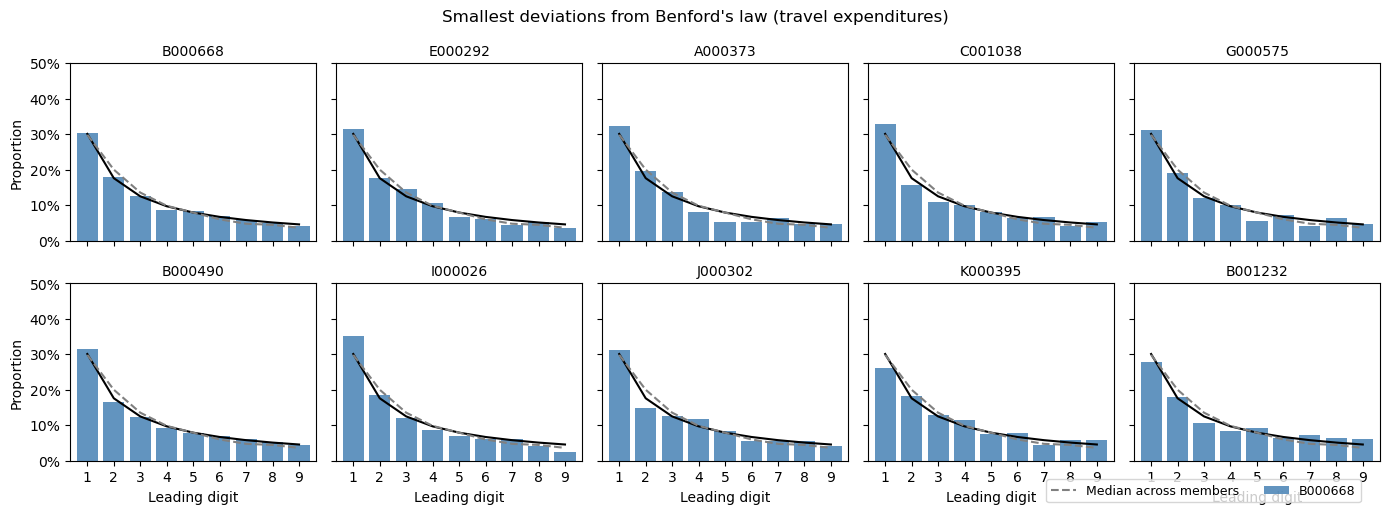

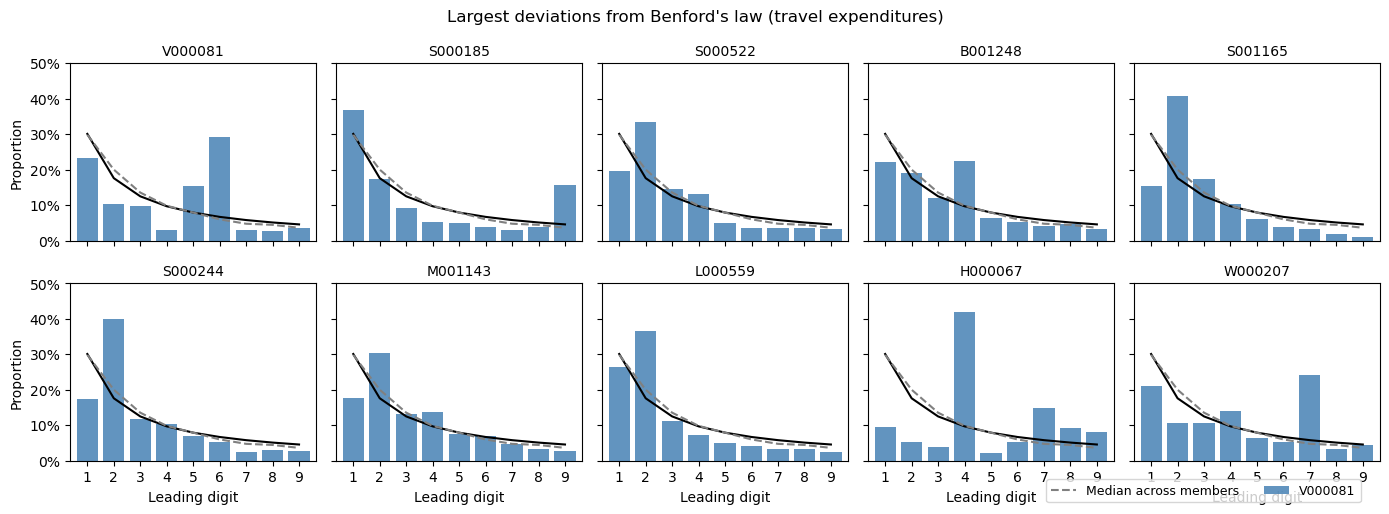

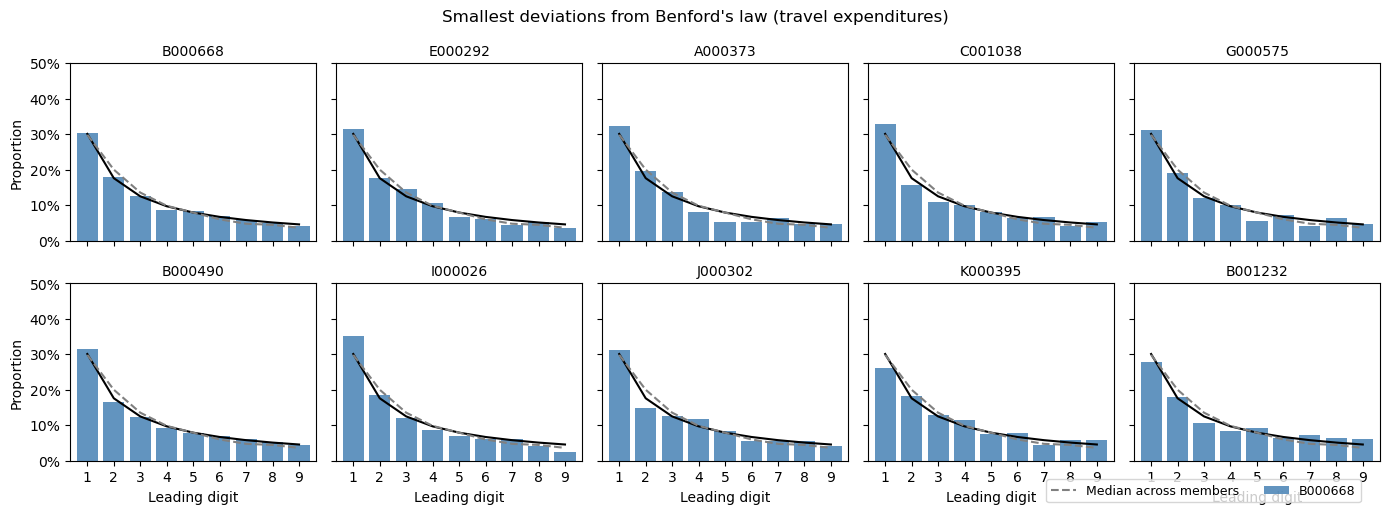

In [61]:
# Figure 4 (revised — travel, R1 to Reviewer 3):
# Replaces the previous two stacked grouped-bar panels with two small-multiples
# grids. Each member gets a dedicated panel with shared axes so deviations
# from the Benford reference can be read off directly.

plot_member_benford_smallmult(
    top10_members_travel,
    benfords_s,
    leading_digit_travel_median_norm,
    "Largest deviations from Benford's law (travel expenditures)",
    'benford_travel_top10.png',
    ylim=0.5,
)

plot_member_benford_smallmult(
    bot10_members_travel,
    benfords_s,
    leading_digit_travel_median_norm,
    "Smallest deviations from Benford's law (travel expenditures)",
    'benford_travel_bot10.png',
    ylim=0.5,
)


#### Member-level personnel expenses

In [62]:
leading_digit_dist_by_member_personnel = {}

for _member in members_gt1000_transactions:
    _amount = members_df.loc[(members_df['BIOGUIDE_ID'] == _member) & (members_df['CATEGORY'] == 'PERSONNEL COMPENSATION'),'AMOUNT']
    leading_digit_dist_by_member_personnel[_member] = leading_digits_count(_amount)
#     leading_digit_dist_by_member_personnel[_member] = _leading_digits / _leading_digits.sum()
    
leading_digit_dist_by_member_personnel_df = pd.DataFrame(leading_digit_dist_by_member_personnel)

leading_digit_dist_by_member_personnel_df

,H001053,G000565,J000292,K000376,C001063,P000601,T000193,S001172,S001185,C001051,G000546,L000491,M001157,J000032,W000809,H001058,D000600,L000566,B001270,P000597,F000449,S000522,D000616,L000551,K000009,F000459,A000055,D000615,S001177,M000087,S001148,C001061,K000362,C001053,B001248,D000191,C001087,W000791,S001150,S001195,G000551,C001080,M001165,F000450,G000552,W000800,S001192,W000795,T000460,G000553,...,Q000024,M001154,B000220,M001207,M001215,B001232,M000687,G000580,M001214,P000149,F000339,C001085,B001280,M001186,L000553,K000336,O000086,T000326,G000597,A000358,P000583,S001218,K000390,S000937,M001135,G000021,A000366,G000575,S000810,M001211,H001062,F000471,I000026,T000486,B001234,N000192,D000492,E000071,J000305,H001078,A000373,R000462,R000611,F000444,G000595,S001210,T000473,C001116,R000305,G000480
AMOUNT,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,619,410,429,666,443,534,498,494,540,607,472,421,493,331,557,408,485,445,413,691,455,444,398,630,520,461,520,449,490,518,456,618,435,605,469,476,586,365,729,446,471,486,645,562,464,544,417,422,619,406,...,50,112,57,84,46,70,82,84,76,73,103,86,78,62,74,104,75,90,79,55,88,79,67,74,86,52.00,68,46,61,67,57,58,56,61,103,73,89,45,81,59,81,92,76,85,85,54,48,57,100,59
2,178,193,177,314,167,178,248,225,196,260,164,204,228,199,211,220,182,176,212,285,249,241,112,212,159,203,222,274,206,253,241,281,174,223,291,261,242,235,282,133,250,235,247,226,254,222,259,212,303,208,...,29,41,27,45,36,28,53,24,36,30,58,46,46,51,44,55,41,47,28,39,43,61,37,55,43,28.00,30,29,15,39,19,22,33,51,32,51,31,31,50,16,33,44,25,59,38,28,21,49,59,29
3,133,117,109,147,80,136,137,126,105,130,92,133,142,133,132,113,85,138,147,117,126,128,91,119,95,94,100,123,101,106,107,212,81,135,97,147,93,89,139,87,143,160,112,104,99,87,142,66,141,146,...,18,21,20,22,20,17,26,15,12,26,26,13,15,24,16,16,22,16,22,31,24,17,18,21,46,27.00,10,23,17,15,25,4,20,25,21,19,20,15,36,7,26,24,24,17,9,24,11,17,27,28
4,77,85,64,116,79,73,48,76,63,106,118,90,94,68,59,137,28,62,121,55,62,85,71,54,69,48,96,66,51,99,62,118,53,32,103,54,68,91,80,54,83,71,66,65,105,112,63,94,74,117,...,5,14,6,12,5,20,17,13,19,24,23,16,19,15,10,11,7,7,15,13,25,18,12,12,10,21.00,10,13,15,12,15,20,18,20,14,12,12,12,12,11,12,19,23,9,22,16,12,13,7,10
5,35,76,48,66,71,62,51,33,43,106,84,35,68,56,35,50,32,24,86,34,69,100,24,85,35,49,66,70,92,85,37,61,64,38,57,38,45,33,33,27,43,42,49,80,67,41,70,62,72,58,...,10,10,10,10,7,8,18,13,3,20,21,9,14,14,13,8,5,7,17,13,9,9,5,12,16,7.00,9,10,5,14,12,10,4,21,13,13,6,10,16,3,4,9,12,11,6,5,4,2,14,5
6,21,50,88,68,77,53,80,28,33,86,32,37,53,59,22,58,36,20,41,35,63,127,28,50,39,20,34,44,36,101,52,58,53,31,27,56,17,35,27,46,55,61,48,66,44,28,42,63,49,34,...,7,11,6,10,8,16,11,2,6,11,8,11,7,6,11,3,12,3,11,13,13,9,7,11,16,14.00,11,14,11,5,5,10,8,4,11,8,7,2,10,10,19,11,4,9,5,3,8,5,12,4
7,69,85,75,61,133,57,36,44,27,61,69,14,58,55,30,73,55,29,50,22,61,69,34,59,55,65,35,66,46,54,38,52,39,22,46,53,18,46,36,38,40,34,55,61,56,72,26,62,38,61,...,5,9,15,12,4,1,3,7,7,12,7,12,7,4,14,13,7,2,4,7,5,4,12,11,12,NaN,17,16,24,4,9,8,12,9,7,2,4,2,7,9,11,14,4,1,4,7,15,4,5,8
8,72,79,72,87,151,87,87,86,54,97,84,57,62,83,63,102,81,49,58,38,61,82,54,85,45,68,39,63,29,81,51,90,48,28,85,90,66,70,47,45,58,71,30,86,79,74,42,109,53,56,...,10,14,10,10,4,3,9,9,7,9,15,9,14,1,23,11,2,11,4,4,12,6,14,14,10,4.00,9,22,11,4,17,8,37,13,23,7,22,1,6,6,11,22,20,4,7,7,10,5,5,10
9,69,85,80,115,106,81,122,67,110,83,84,89,79,92,90,95,85,47,45,56,99,66,81,97,57,89,37,73,54,131,40,82,72,69,41,89,48,46,55,69,67,64,46,84,132,70,48,105,53,51,...,11,8,22,14,8,15,9,11,7,10,16,27,16,14,5,7,1,3,8,10,6,5,14,15,7,6.00,9,24,15,12,18,9,10,8,16,6,6,3,7,4,8,11,11,11,9,16,14,6,9,10


In [63]:
ks_test_by_member_personnel = {}

for _member in leading_digit_dist_by_member_personnel_df.columns:
    _col_vals = leading_digit_dist_by_member_personnel_df.loc[:,_member]
    _exp_vals = _col_vals.sum() * benfords_s
    
    _ks_test = stats.ks_2samp(_col_vals,_exp_vals)
    _chi2_test = stats.chisquare(_col_vals,_exp_vals)
    
    ks_test_by_member_personnel[_member] = {
        'ks_statistic':_ks_test.statistic,'ks_pvalue':_ks_test.pvalue,
        'chi2_statistic':_chi2_test.statistic,'chi2_pvalue':_chi2_test.pvalue
    }
        
dist_test_by_member_personnel_df = pd.DataFrame(ks_test_by_member_personnel).T
dist_test_by_member_personnel_df.sort_values('chi2_statistic',ascending=False).head(20)

,ks_statistic,ks_pvalue,chi2_statistic,chi2_pvalue
P000597,0.67,0.03,412.10,0.00
B000911,0.33,0.73,409.52,0.00
S001150,0.56,0.13,388.52,0.00
J000289,0.33,0.73,380.50,0.00
C001053,0.56,0.13,351.29,0.00
S001189,0.56,0.13,348.97,0.00
L000570,0.44,0.35,327.64,0.00
G000568,0.22,0.99,315.24,0.00
V000131,0.44,0.35,311.02,0.00
S001157,0.44,0.35,306.64,0.00


Is there a difference between the distribution of median leading digits and Benford's law?

In [64]:
leading_digit_dist_by_member_personnel_norm_df = leading_digit_dist_by_member_personnel_df / leading_digit_dist_by_member_personnel_df.sum()
top10_members_personnel = leading_digit_dist_by_member_personnel_norm_df.loc[:,dist_test_by_member_personnel_df.sort_values('chi2_statistic',ascending=False).head(10).index]
bot10_members_personnel = leading_digit_dist_by_member_personnel_norm_df.loc[:,dist_test_by_member_personnel_df.sort_values('chi2_statistic').head(10).index]

leading_digit_personnel_median = leading_digit_dist_by_member_personnel_df.median(1)
leading_digit_personnel_median_norm = leading_digit_personnel_median/leading_digit_personnel_median.sum()

stats.chisquare(leading_digit_personnel_median,leading_digit_personnel_median.sum() * benfords_s)


/var/folders/lr/v195xr617d32k2zdwwh30sb40000gn/T/ipykernel_77558/2624659777.py:5: Pandas4Warning: Starting with pandas version 4.0 all arguments of median will be keyword-only.
  leading_digit_personnel_median = leading_digit_dist_by_member_personnel_df.median(1)


Power_divergenceResult(statistic=np.float64(46.47471205963341), pvalue=np.float64(1.930731533785927e-07))

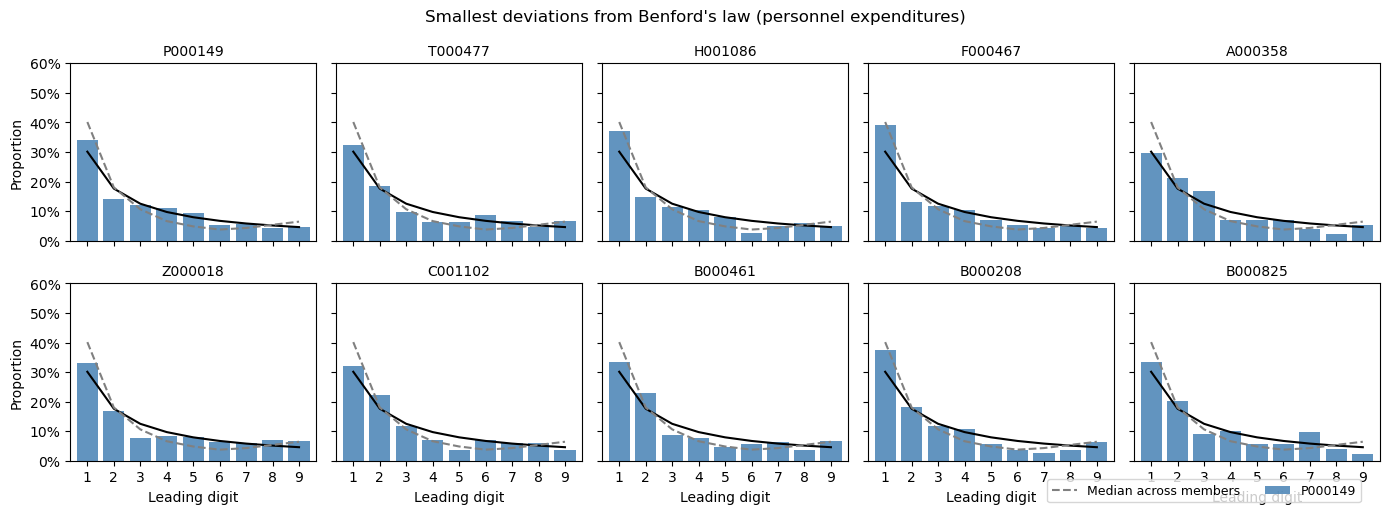

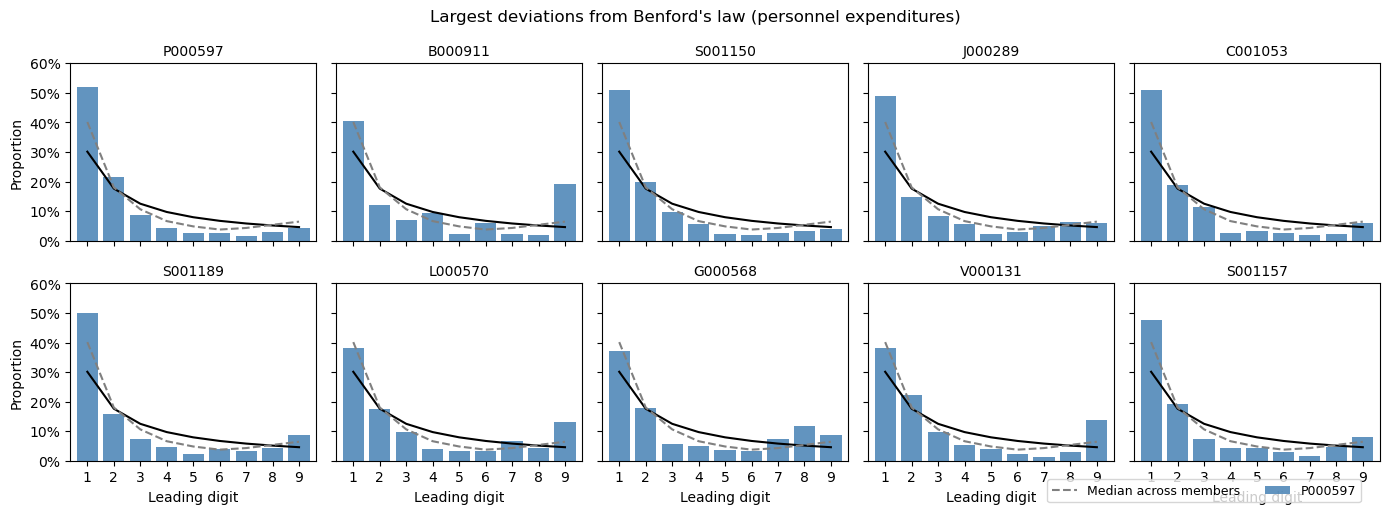

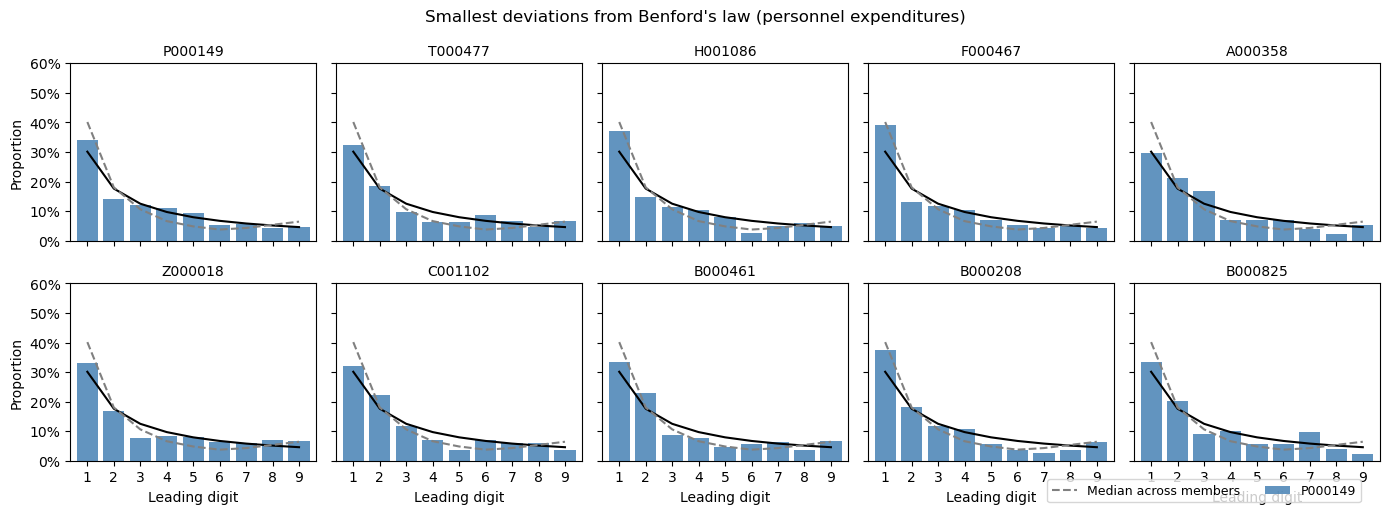

In [65]:
# Figure 4 (revised — personnel, R1 to Reviewer 3):
# Same small-multiples treatment for the personnel-compensation comparison.

plot_member_benford_smallmult(
    top10_members_personnel,
    benfords_s,
    leading_digit_personnel_median_norm,
    "Largest deviations from Benford's law (personnel expenditures)",
    'benford_personnel_top10.png',
    ylim=0.6,
)

plot_member_benford_smallmult(
    bot10_members_personnel,
    benfords_s,
    leading_digit_personnel_median_norm,
    "Smallest deviations from Benford's law (personnel expenditures)",
    'benford_personnel_bot10.png',
    ylim=0.6,
)


Within member, by year, across categories. Biggest member-year-category deviations from Benfords'

In [66]:
annual_member_cat_leading_digits_df = members_df.groupby(['BIOGUIDE_ID','YEAR','CATEGORY'])['AMOUNT'].apply(leading_digits_count)
annual_member_cat_leading_digits_df.head()

BIOGUIDE_ID  YEAR  CATEGORY       
A000022      2011  EQUIPMENT     1    12
                                 2     7
                                 4     1
                   FRANKED MAIL  1     7
                                 2     1
Name: AMOUNT, dtype: int64

In [67]:
annual_member_cat_leading_digits_df.unstack([2,1]).sort_index(axis=1)

CATEGORY      BENEFITS TO FORMER PERSONNEL EQUIPMENT                       \
YEAR                                  2017      2011  2012 2013 2014 2015   
BIOGUIDE_ID                                                                 
A000022     1                          NaN     12.00 12.00 1.00  NaN  NaN   
            2                          NaN      7.00  1.00  NaN  NaN  NaN   
            3                          NaN       NaN   NaN  NaN  NaN  NaN   
            4                          NaN      1.00   NaN  NaN  NaN  NaN   
            5                          NaN       NaN   NaN  NaN  NaN  NaN   
...                                    ...       ...   ...  ...  ...  ...   
Z000018     5                          NaN       NaN   NaN  NaN  NaN 1.00   
            6                          NaN       NaN   NaN  NaN  NaN  NaN   
            7                          NaN       NaN   NaN  NaN  NaN 1.00   
            8                          NaN       NaN   NaN  NaN  NaN 1.00   
            9                          NaN       NaN   NaN  NaN  NaN  NaN   

CATEGORY                                         FRANKED MAIL                 \
YEAR          2016 2017 2018 2019 2020 2021 2022         2011 2012 2013 2014   
BIOGUIDE_ID                                                                    
A000022     1  NaN  NaN  NaN  NaN  NaN  NaN  NaN         7.00 5.00  NaN  NaN   
            2  NaN  NaN  NaN  NaN  NaN  NaN  NaN         1.00 3.00 1.00  NaN   
            3  NaN  NaN  NaN  NaN  NaN  NaN  NaN         1.00 1.00  NaN  NaN   
            4  NaN  NaN  NaN  NaN  NaN  NaN  NaN         3.00 1.00  NaN  NaN   
            5  NaN  NaN  NaN  NaN  NaN  NaN  NaN          NaN 1.00 1.00  NaN   
...            ...  ...  ...  ...  ...  ...  ...          ...  ...  ...  ...   
Z000018     5  NaN  NaN  NaN  NaN  NaN  NaN  NaN          NaN  NaN  NaN  NaN   
            6  NaN  NaN  NaN  NaN  NaN  NaN  NaN          NaN  NaN  NaN  NaN   
            7  NaN 1.00  NaN  NaN  NaN  NaN  NaN          NaN  NaN  NaN  NaN   
            8  NaN  NaN  NaN  NaN  NaN  NaN  NaN          NaN  NaN  NaN  NaN   
            9  NaN  NaN  NaN  NaN  NaN  NaN  NaN          NaN  NaN  NaN  NaN   

CATEGORY                                              OTHER SERVICES        \
YEAR          2015 2016 2017 2018 2019 2020 2021 2022           2011  2012   
BIOGUIDE_ID                                                                  
A000022     1  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN          17.00  2.00   
            2  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN          20.00 13.00   
            3  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN           4.00 10.00   
            4  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN           1.00   NaN   
            5  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN           3.00  1.00   
...            ...  ...  ...  ...  ...  ...  ...  ...            ...   ...   
Z000018     5  NaN 1.00  NaN  NaN  NaN  NaN  NaN  NaN            NaN   NaN   
            6  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN            NaN   NaN   
            7 1.00 2.00  NaN  NaN  NaN  NaN  NaN  NaN            NaN   NaN   
            8 1.00  NaN  NaN  NaN  NaN  NaN  NaN  NaN            NaN   NaN   
            9 2.00 1.00 1.00  NaN  NaN  NaN  NaN  NaN            NaN   NaN   

CATEGORY                                                          \
YEAR          2013 2014 2015  2016 2017 2018 2019 2020 2021 2022   
BIOGUIDE_ID                                                        
A000022     1 2.00  NaN  NaN   NaN  NaN  NaN  NaN  NaN  NaN  NaN   
            2  NaN  NaN  NaN   NaN  NaN  NaN  NaN  NaN  NaN  NaN   
            3 3.00  NaN  NaN   NaN  NaN  NaN  NaN  NaN  NaN  NaN   
            4  NaN  NaN  NaN   NaN  NaN  NaN  NaN  NaN  NaN  NaN   
            5  NaN  NaN  NaN   NaN  NaN  NaN  NaN  NaN  NaN  NaN   
...            ...  ...  ...   ...  ...  ...  ...  ...  ...  ...   
Z000018     5  NaN  NaN 1.00   NaN 3.00  NaN  NaN  NaN  NaN  NaN   
            6  NaN  NaN  Na

### Relative size factor

Divide biggest expense by second biggest expense (within member-category-time).

In [68]:
two_largest_expenses = members_df.groupby(['BIOGUIDE_ID','YEAR','CATEGORY']).agg({'AMOUNT':lambda x:x.nlargest(2)})['AMOUNT']

two_largest_expenses = two_largest_expenses[two_largest_expenses.apply(lambda x:isinstance(x,np.ndarray))]
two_largest_expenses = two_largest_expenses[(two_largest_expenses.apply(lambda x:x[0] > 0)) & (two_largest_expenses.apply(lambda x:x[1] > 0))]

largest_expenses_ratio = two_largest_expenses.apply(lambda x:x[0]/x[1])

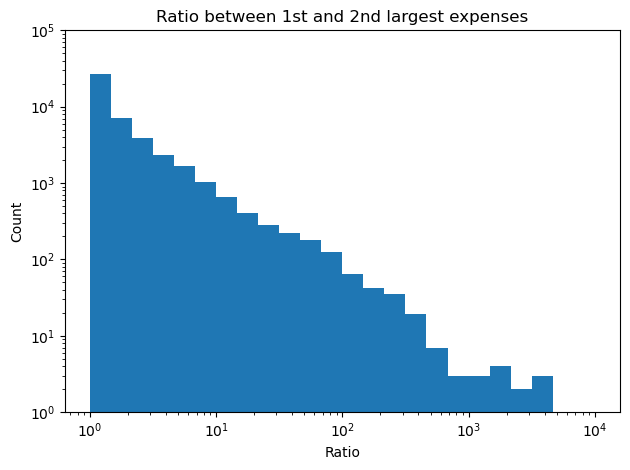

In [69]:
f,ax = plt.subplots()

largest_expenses_ratio.hist(bins=np.logspace(0,4,25),ax=ax)
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(None)
ax.set_ylim((1e0,1e5))
ax.set_xlabel('Ratio')
ax.set_ylabel('Count')
ax.set_title('Ratio between 1st and 2nd largest expenses')

f.tight_layout()
f.savefig('two_largest_ratio.png',bbox_inches='tight')

In [70]:
len(largest_expenses_ratio[largest_expenses_ratio <= 10]) / len(largest_expenses_ratio)

0.9542081689952537

In [71]:
largest_expenses_ratio[largest_expenses_ratio > 500].sort_index()

BIOGUIDE_ID  YEAR  CATEGORY                 
B001311      2022  FRANKED MAIL                 675.18
C001077      2019  PRINTING AND REPRODUCTION    716.32
C001118      2022  OTHER SERVICES              2310.00
D000533      2019  FRANKED MAIL                2076.64
E000071      2021  FRANKED MAIL                2001.70
F000461      2021  FRANKED MAIL                6822.95
G000571      2021  FRANKED MAIL                 582.02
K000390      2019  FRANKED MAIL                3512.39
L000551      2022  FRANKED MAIL                1048.24
L000573      2019  FRANKED MAIL                1164.02
L000574      2013  PRINTING AND REPRODUCTION    604.78
L000581      2022  FRANKED MAIL                 582.08
M001137      2020  FRANKED MAIL                 776.66
P000096      2022  FRANKED MAIL                2038.29
P000604      2016  FRANKED MAIL                 783.23
             2019  FRANKED MAIL                2967.06
             2020  FRANKED MAIL                3510.64
             2021  F

In [72]:
c0 = members_df['YEAR'] == 2021
c1 = members_df['CATEGORY'] == 'FRANKED MAIL'
c2 = members_df['BIOGUIDE_ID'] == 'P000604'

members_df.loc[c0 & c1 & c2,:].sort_values('AMOUNT',ascending=False)

,YEAR-QUARTER,YEAR,QUARTER,TERM_QUARTER,BIOGUIDE_ID,OFFICE,PROGRAM,CATEGORY,PAYEE,PURPOSE,AMOUNT,DATE,PERIOD_DATE,DATE_IS_RECONSTRUCTED,START DATE,END DATE,TRANSCODE,RECORDID,VOUCHER_ID
4308923,2021Q4,2021,Q4,4,P000604,2021 HON. DONALD M. PAYNE JR.,OFFICIAL EXPENSES OF MEMBERS,FRANKED MAIL,UNITED STATES POSTAL SERVICE,FRANKED MAIL,44504.54,2021-12-30,2021-12-30,False,2021-11-01,2021-11-30,AP,1509423,NaN
4017621,2021Q1,2021,Q1,1,P000604,2021 HON. DONALD M. PAYNE JR.,OFFICIAL EXPENSES OF MEMBERS,FRANKED MAIL,UNITED STATES POSTAL SERVICE,FRANKED MAIL,23.88,2021-03-31,2021-03-31,False,2021-02-01,2021-02-28,AP,1403198,NaN
4207620,2021Q3,2021,Q3,3,P000604,2021 HON. DONALD M. PAYNE JR.,OFFICIAL EXPENSES OF MEMBERS,FRANKED MAIL,UNITED STATES POSTAL SERVICE,FRANKED MAIL,11.99,2021-08-10,2021-08-10,False,2021-06-01,2021-06-30,AP,1448678,NaN
4017690,2021Q1,2021,Q1,1,P000604,2020 HON. DONALD M. PAYNE JR.,OFFICIAL EXPENSES OF MEMBERS,FRANKED MAIL,UNITED STATES POSTAL SERVICE,FRANKED MAIL,8.24,2021-01-28,2021-01-28,False,2020-12-01,2021-01-02,AP,1379944,NaN
4308921,2021Q4,2021,Q4,4,P000604,2021 HON. DONALD M. PAYNE JR.,OFFICIAL EXPENSES OF MEMBERS,FRANKED MAIL,UNITED STATES POSTAL SERVICE,FRANKED MAIL,7.71,2021-11-30,2021-11-30,False,2021-10-01,2021-10-31,AP,1496444,NaN
4017620,2021Q1,2021,Q1,1,P000604,2021 HON. DONALD M. PAYNE JR.,OFFICIAL EXPENSES OF MEMBERS,FRANKED MAIL,UNITED STATES POSTAL SERVICE,FRANKED MAIL,4.80,2021-03-01,2021-03-01,False,2021-01-03,2021-01-31,AP,1391759,NaN
4111922,2021Q2,2021,Q2,2,P000604,2021 HON. DONALD M. PAYNE JR.,OFFICIAL EXPENSES OF MEMBERS,FRANKED MAIL,UNITED STATES POSTAL SERVICE,FRANKED MAIL,3.80,2021-06-23,2021-06-23,False,2021-05-01,2021-05-31,AP,1435123,NaN
4207621,2021Q3,2021,Q3,3,P000604,2021 HON. DONALD M. PAYNE JR.,OFFICIAL EXPENSES OF MEMBERS,FRANKED MAIL,UNITED STATES POSTAL SERVICE,FRANKED MAIL,3.00,2021-09-01,2021-09-01,False,2021-07-01,2021-07-31,AP,1460065,NaN
4308920,2021Q4,2021,Q4,4,P000604,2021 HON. DONALD M. PAYNE JR.,OFFICIAL EXPENSES OF MEMBERS,FRANKED MAIL,,FRANKED MAIL,-8.85,2021-10-31,2021-10-31,False,2021-10-20,2021-10-31,GL,FLG0110648,NaN
4308922,2021Q4,2021,Q4,4,P000604,2021 HON. DONALD M. PAYNE JR.,OFFICIAL EXPENSES OF MEMBERS,FRANKED MAIL,,FRANKED MAIL,-16.95,2021-11-30,2021-11-30,False,2021-11-20,2021-11-30,GL,FLG0111311,NaN


(0.0, 12000.0)

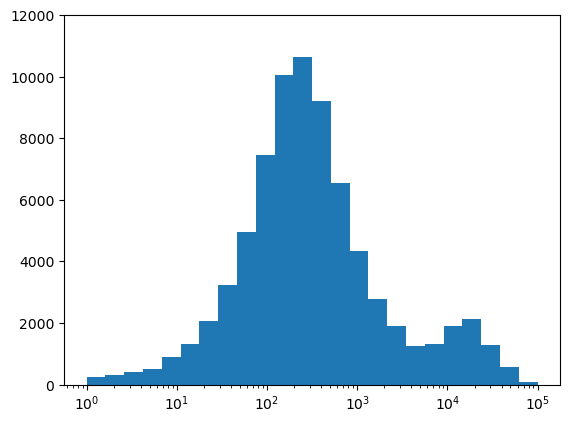

In [73]:
# ax = members_df[c1].groupby(['YEAR','BIOGUIDE_ID']).agg({'AMOUNT':'sum'})['AMOUNT'].hist(bins=np.logspace(0,7,25))
ax = members_df.loc[c1,'AMOUNT'].hist(bins=np.logspace(0,5,25))
ax.set_xscale('log')
ax.grid(None)
ax.set_ylim((0,12000))

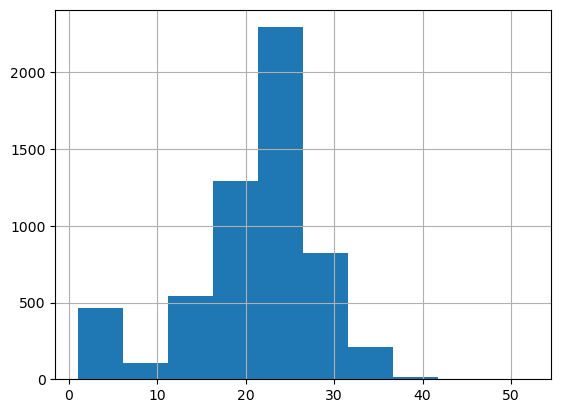

In [74]:
ax = members_df[c1].groupby(['YEAR','BIOGUIDE_ID']).agg({'AMOUNT':'nunique'})['AMOUNT'].hist()

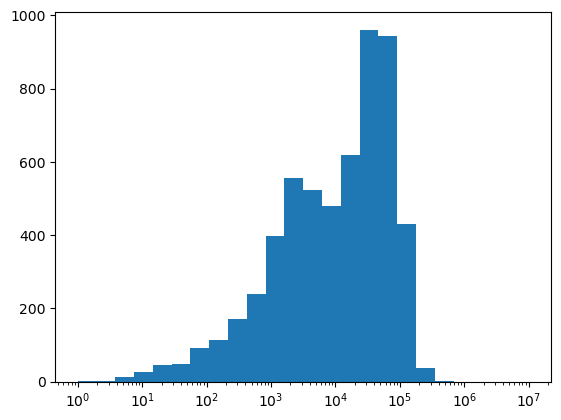

In [75]:
_s = members_df[c1].groupby(['YEAR','BIOGUIDE_ID']).agg({'AMOUNT':'sum'})['AMOUNT']
ax = _s.hist(bins=np.logspace(0,7,25))
ax.set_xscale('log')
ax.grid(None)

In [76]:
_s.describe()

count     5752.00
mean     29975.08
std      38323.04
min     -19684.53
25%       2153.53
50%      14060.08
75%      45778.57
max     449260.41
Name: AMOUNT, dtype: float64

In [77]:
members_df[members_df['BIOGUIDE_ID'] == 'P000604']

,YEAR-QUARTER,YEAR,QUARTER,TERM_QUARTER,BIOGUIDE_ID,OFFICE,PROGRAM,CATEGORY,PAYEE,PURPOSE,AMOUNT,DATE,PERIOD_DATE,DATE_IS_RECONSTRUCTED,START DATE,END DATE,TRANSCODE,RECORDID,VOUCHER_ID
812098,2012Q4,2012,Q4,8,P000604,HON. DONALD PAYNE JR,NaN,PERSONNEL COMPENSATION,"ALEXANDER, LAVERNE",CHIEF OF STAFF,22819.45,NaT,2012-11-08,True,2012-11-08,2012-12-31,NaN,NaN,"ALEXANDER, LAVERNE"
812099,2012Q4,2012,Q4,8,P000604,HON. DONALD PAYNE JR,NaN,PERSONNEL COMPENSATION,"CAMPBELL, PATRICIA M",STAFF ASSISTANT,2745.70,NaT,2012-11-08,True,2012-11-08,2012-12-31,NaN,NaN,"CAMPBELL, PATRICIA M"
812100,2012Q4,2012,Q4,8,P000604,HON. DONALD PAYNE JR,NaN,PERSONNEL COMPENSATION,"COLLIER, TIA",SENIOR LEGISLATIVE ASSISTANT,8659.61,NaT,2012-11-08,True,2012-11-08,2012-12-31,NaN,NaN,"COLLIER, TIA"
812101,2012Q4,2012,Q4,8,P000604,HON. DONALD PAYNE JR,NaN,PERSONNEL COMPENSATION,"CRUZ, ISABEL",SPECIAL ASSISTANT,11172.70,NaT,2012-11-08,True,2012-11-08,2012-12-31,NaN,NaN,"CRUZ, ISABEL"
812102,2012Q4,2012,Q4,8,P000604,HON. DONALD PAYNE JR,NaN,PERSONNEL COMPENSATION,"HATCHETT, YVONNE",SPECIAL ASSISTANT,6133.28,NaT,2012-11-08,True,2012-11-08,2012-12-31,NaN,NaN,"HATCHETT, YVONNE"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4756057,2022Q4,2022,Q4,8,P000604,2022 HON. DONALD M. PAYNE JR.,OFFICIAL EXPENSES OF MEMBERS,SUPPLIES AND MATERIALS,,OFFICE SUPPLY (TRANSFER),76.55,2022-12-31,2022-12-31,False,2022-12-01,2022-12-31,GL,RMS0121216,
4756058,2022Q4,2022,Q4,8,P000604,2022 HON. DONALD M. PAYNE JR.,OFFICIAL EXPENSES OF MEMBERS,EQUIPMENT,,MAINTENANCE / REPAIRS,416.00,2022-10-31,2022-10-31,False,2022-10-01,2022-10-31,GL,MNT0119612,
4756059,2022Q4,2022,Q4,8,P000604,2022 HON. DONALD M. PAYNE JR.,OFFICIAL EXPENSES OF MEMBERS,EQUIPMENT,,MAINTENANCE / REPAIRS,416.00,2022-11-30,2022-11-30,False,2022-11-01,2022-11-30,GL,MNT0120336,
4756060,2022Q4,2022,Q4,8,P000604,2022 HON. DONALD M. PAYNE JR.,OFFICIAL EXPENSES OF MEMBERS,EQUIPMENT,,MAINTENANCE / REPAIRS,416.00,2022-12-30,2022-12-30,False,2022-12-01,2022-12-31,GL,MNT0121160,


## Categorical anomalies

In [132]:
member_expense_count_by_category_df = members_df.groupby(['YEAR-QUARTER','BIOGUIDE_ID'])
member_expense_count_by_category_df = member_expense_count_by_category_df['CATEGORY'].value_counts().unstack(-1).fillna(0)
member_expense_count_by_category_df.drop(columns=['BENEFITS TO FORMER PERSONNEL','PERSONNEL BENEFITS','TRANSPORTATION OF THINGS'],inplace=True)

member_expense_count_by_category_df

CATEGORY                  EQUIPMENT  FRANKED MAIL  OTHER SERVICES  \
YEAR-QUARTER BIOGUIDE_ID                                            
2011Q1       A000014           0.00          0.00            0.00   
             A000022           7.00          5.00           11.00   
             A000055           3.00          4.00           12.00   
             A000210           3.00          7.00           16.00   
             A000358           5.00          7.00            7.00   
...                             ...           ...             ...   
2022Q4       W000826           5.00          8.00           17.00   
             Y000033           0.00          0.00            1.00   
             Y000062           3.00          4.00           25.00   
             Y000067           2.00          0.00            3.00   
             Z000017           4.00          4.00           11.00   

CATEGORY                  PERSONNEL COMPENSATION  PRINTING AND REPRODUCTION  \
YEAR-QUARTER BIOGUIDE_ID                                                      
2011Q1       A000014                        1.00                       0.00   
             A000022                       35.00                       9.00   
             A000055                       42.00                      12.00   
             A000210                       38.00                       1.00   
             A000358                       34.00                       7.00   
...                                          ...                        ...   
2022Q4       W000826                       23.00                      24.00   
             Y000033                        0.00                       0.00   
             Y000062                       21.00                       3.00   
             Y000067                       12.00                       0.00   
             Z000017                       20.00                       3.00   

CATEGORY                  RENT COMMUNICATION UTILITIES  \
YEAR-QUARTER BIOGUIDE_ID                                 
2011Q1       A000014                              0.00   
             A000022                             65.00   
             A000055                             72.00   
             A000210                             62.00   
             A000358                             47.00   
...                                                ...   
2022Q4       W000826                             58.00   
             Y000033                              2.00   
             Y000062                             35.00   
             Y000067                              7.00   
             Z000017                             42.00   

CATEGORY                  SUPPLIES AND MATERIALS  TRAVEL  
YEAR-QUARTER BIOGUIDE_ID                                  
2011Q1       A000014                        0.00    0.00  
             A000022                       52.00   26.00  
             A000055                       48.00   47.00  
             A000210                       24.00    3.00  
             A000358                       42.00   37.00  
...                                          ...     ...  
2022Q4       W000826                       32.00   72.00  
             Y000033                        0.00    0.00  
             Y000062                       25.00   33.00  
             Y000067                        4.00    0.00  
             Z000017                       29.00   17.00  

[22678 rows x 8 columns]

In [133]:
gt10 = member_expense_count_by_category_df.sum(1)
gt10 = gt10[gt10>20]
gt10 = member_expense_count_by_category_df.loc[gt10.index]

_exp = gt10.median(axis=0)
_exp = _exp/_exp.sum()
_df = gt10.div(gt10.sum(1),axis=0)

chisquare_pvalues_expense_counts = pd.Series(data=stats.chisquare(_df,_exp,axis=1).pvalue,index=gt10.index)
gt10.loc[chisquare_pvalues_expense_counts.sort_values().head(20).index]


/var/folders/lr/v195xr617d32k2zdwwh30sb40000gn/T/ipykernel_77558/3116638434.py:1: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  gt10 = member_expense_count_by_category_df.sum(1)
/var/folders/lr/v195xr617d32k2zdwwh30sb40000gn/T/ipykernel_77558/3116638434.py:7: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  _df = gt10.div(gt10.sum(1),axis=0)


CATEGORY                  EQUIPMENT  FRANKED MAIL  OTHER SERVICES  \
YEAR-QUARTER BIOGUIDE_ID                                            
2015Q3       M000485          24.00          0.00            0.00   
2019Q4       R000580           0.00          0.00            0.00   
2021Q1       W000810          15.00          1.00            0.00   
2017Q3       M001182           9.00          0.00            1.00   
2020Q3       S001209           3.00          8.00            6.00   
2022Q3       S001219           0.00          0.00            1.00   
             C001090           8.00          5.00            8.00   
2011Q1       H001039           1.00          1.00            0.00   
2020Q3       A000376           6.00          9.00            6.00   
2015Q1       N000187           0.00          0.00            0.00   
2022Q4       H001090           3.00          6.00            0.00   
2013Q1       M001154           0.00          1.00            0.00   
2021Q1       T000470           0.00          1.00            0.00   
2020Q2       D000629          11.00          7.00           16.00   
2021Q1       C001094           0.00          0.00            4.00   
2013Q1       F000116          20.00          1.00            1.00   
2020Q3       C001110           5.00         10.00            3.00   
2011Q1       S000465           3.00          1.00            1.00   
2021Q2       T000470           0.00          0.00            0.00   
2015Q1       M001142           0.00          1.00            0.00   

CATEGORY                  PERSONNEL COMPENSATION  PRINTING AND REPRODUCTION  \
YEAR-QUARTER BIOGUIDE_ID                                                      
2015Q3       M000485                        0.00                       0.00   
2019Q4       R000580                       27.00                       0.00   
2021Q1       W000810                       11.00                       0.00   
2017Q3       M001182                        1.00                       4.00   
2020Q3       S001209                       21.00                      82.00   
2022Q3       S001219                       21.00                       1.00   
             C001090                       29.00                     122.00   
2011Q1       H001039                       47.00                       0.00   
2020Q3       A000376                       21.00                      71.00   
2015Q1       N000187                       30.00                       0.00   
2022Q4       H001090                       24.00                      85.00   
2013Q1       M001154                       25.00                       0.00   
2021Q1       T000470                       19.00                       0.00   
2020Q2       D000629                       25.00                     149.00   
2021Q1       C001094                       33.00                       0.00   
2013Q1       F000116                       16.00                       0.00   
2020Q3       C001110                       21.00                      93.00   
2011Q1       S000465                       36.00                       0.00   
2021Q2       T000470                        0.00                       0.00   
2015Q1       M001142                       19.00                       1.00   

CATEGORY                  RENT COMMUNICATION UTILITIES  \
YEAR-QUARTER BIOGUIDE_ID                                 
2015Q3       M000485                              0.00   
2019Q4       R000580                              0.00   
2021Q1       W000810                              7.00   
2017Q3       M001182                              7.00   
2020Q3       S001209                             18.00   
2022Q3       S001219                              0.00   
             C001090                             34.00   
2011Q1       H001039                              4.00   
2020Q3       A000376                             15.00   
2015Q1       N000187                              6.00   
2022Q4       H001090                          

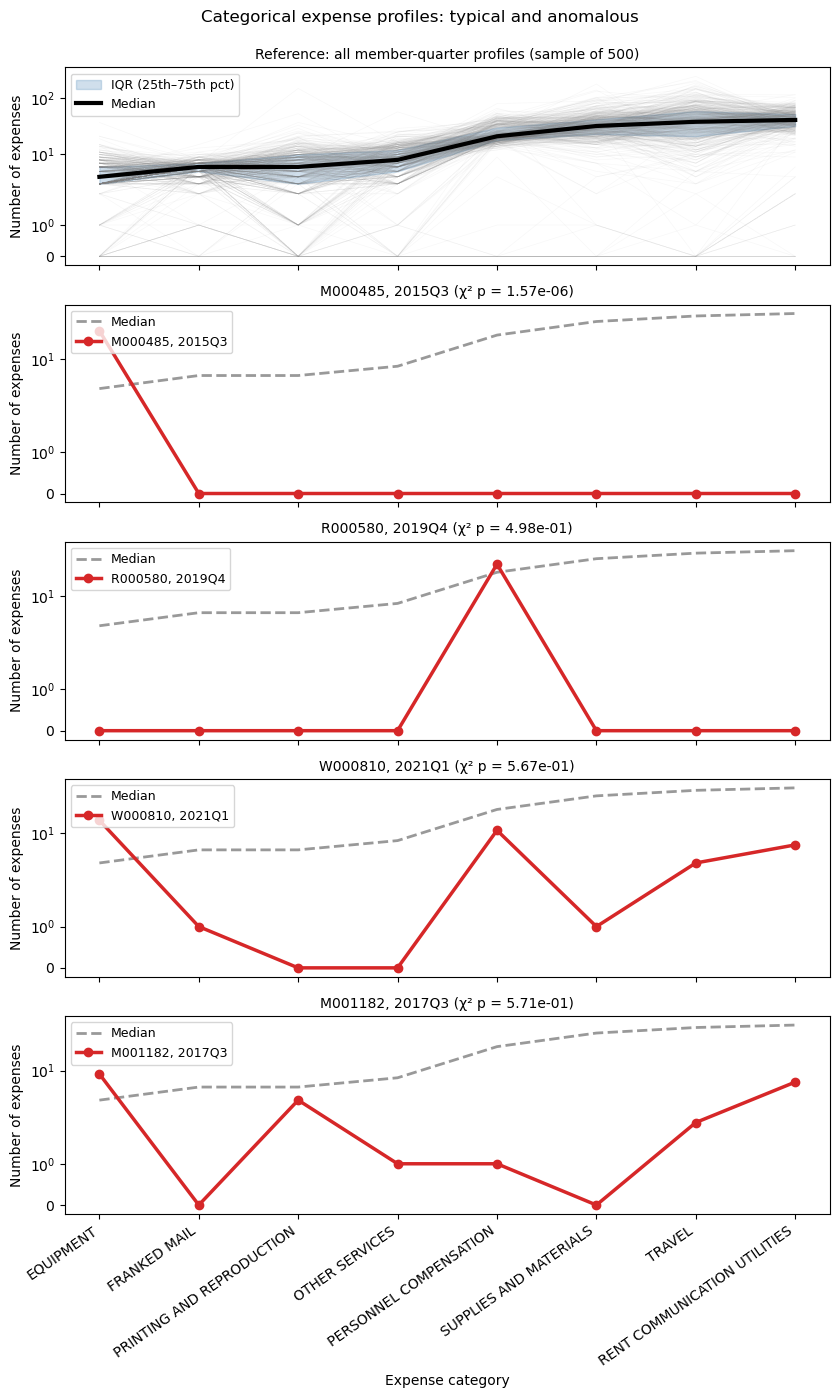

In [134]:
# Figure 6 (revised, R1 to Reviewer 3):
# Replaces dynamite bars (whose CIs were illegible) with vertically aligned
# profile plots. Top panel: a random sample of member-quarter profiles in
# pale grey, with the IQR band and the population median overlaid. Lower
# four panels: anomalous member-quarter profiles drawn on the same category
# ordering so deviations from the median profile are directly comparable.
# Colour key (for caption): grey thin lines = individual member-quarter
# profiles; blue band = interquartile range across all member-quarters;
# black line = median across all member-quarters; red line = the anomalous
# member-quarter named in the panel title.

_df = member_expense_count_by_category_df.stack().reset_index(level=[2])
_order = member_expense_count_by_category_df.median().sort_values().index.tolist()

top4_anomalies = chisquare_pvalues_expense_counts.sort_values().head(4)

f, axs = plt.subplots(5, 1, figsize=(8.5, 14), sharex=True)

# Panel 1: population reference
ax0 = axs[0]
sample = member_expense_count_by_category_df.sample(
    n=min(500, len(member_expense_count_by_category_df)), random_state=42
)
for _, row in sample.iterrows():
    ax0.plot(_order, row[_order].values, color='grey', alpha=0.06, lw=0.5)

median_profile = member_expense_count_by_category_df[_order].median()
q25 = member_expense_count_by_category_df[_order].quantile(0.25)
q75 = member_expense_count_by_category_df[_order].quantile(0.75)

ax0.fill_between(range(len(_order)), q25.values, q75.values,
                 alpha=0.25, color='steelblue', label='IQR (25th–75th pct)')
ax0.plot(_order, median_profile.values, color='black', lw=3, label='Median')

ax0.set_title('Reference: all member-quarter profiles (sample of 500)', fontsize=10)
ax0.set_ylabel('Number of expenses')
ax0.legend(fontsize=9, loc='upper left')
ax0.set_yscale('symlog')

# Panels 2–5: anomalous examples
for i, ((yq, bio_id), pval) in enumerate(top4_anomalies.items()):
    ax = axs[i + 1]
    ax.plot(_order, median_profile.values, color='grey', lw=2, ls='--',
            label='Median', alpha=0.8)
    row = member_expense_count_by_category_df.loc[(yq, bio_id), _order]
    ax.plot(_order, row.values, color='tab:red', lw=2.5, marker='o',
            label=f'{bio_id}, {yq}')
    ax.set_title(f"{bio_id}, {yq} (χ² p = {pval:.2e})", fontsize=10)
    ax.set_ylabel('Number of expenses')
    ax.legend(fontsize=9, loc='upper left')
    ax.set_yscale('symlog')

axs[-1].set_xlabel('Expense category')
plt.setp(axs[-1].get_xticklabels(), rotation=35, ha='right')

f.suptitle('Categorical expense profiles: typical and anomalous',
           fontsize=12, y=0.995)
f.tight_layout()
f.savefig('categorical_anomalies_profiles.png', dpi=300, bbox_inches='tight')


In [135]:
c0 = members_df['YEAR-QUARTER'] == '2019Q4'
c1 = members_df['BIOGUIDE_ID'] == 'R000580'
members_df.loc[c0 & c1,:]

,YEAR-QUARTER,YEAR,QUARTER,TERM_QUARTER,BIOGUIDE_ID,OFFICE,PROGRAM,CATEGORY,PAYEE,PURPOSE,AMOUNT,DATE,PERIOD_DATE,DATE_IS_RECONSTRUCTED,START DATE,END DATE,TRANSCODE,RECORDID,VOUCHER_ID
3558398,2019Q4,2019,Q4,4,R000580,2018 HON. PETER J. ROSKAM,OFFICIAL EXPENSES OF MEMBERS,PERSONNEL COMPENSATION,BILLMAN JEFFREY R,CONGRESSIONAL ASSISTANT,-546.73,NaT,2018-01-01,True,2018-01-01,2018-01-30,,,NaN
3558399,2019Q4,2019,Q4,4,R000580,2018 HON. PETER J. ROSKAM,OFFICIAL EXPENSES OF MEMBERS,PERSONNEL COMPENSATION,CAMPUZANO NEFTALI,DEPUTY DISTRICT DIRECTOR,-518.95,NaT,2018-01-01,True,2018-01-01,2018-01-30,,,NaN
3558400,2019Q4,2019,Q4,4,R000580,2018 HON. PETER J. ROSKAM,OFFICIAL EXPENSES OF MEMBERS,PERSONNEL COMPENSATION,CORRIGAN EDWARD M,LEGISLATIVE CORRESPONDENT,-668.95,NaT,2018-01-01,True,2018-01-01,2018-01-30,,,NaN
3558401,2019Q4,2019,Q4,4,R000580,2018 HON. PETER J. ROSKAM,OFFICIAL EXPENSES OF MEMBERS,PERSONNEL COMPENSATION,FAWELL JOSEPH D,LEGISLATIVE ASSISTANT,-546.72,NaT,2018-01-01,True,2018-01-01,2018-01-30,,,NaN
3558402,2019Q4,2019,Q4,4,R000580,2018 HON. PETER J. ROSKAM,OFFICIAL EXPENSES OF MEMBERS,PERSONNEL COMPENSATION,GOLLINGER JOSEPH B,STAFF ASSISTANT,-763.39,NaT,2018-01-01,True,2018-01-01,2018-01-30,,,NaN
3558403,2019Q4,2019,Q4,4,R000580,2018 HON. PETER J. ROSKAM,OFFICIAL EXPENSES OF MEMBERS,PERSONNEL COMPENSATION,HILLSTROM EMILY E,STAFF ASSISTANT,-768.95,NaT,2018-01-01,True,2018-01-01,2018-01-30,,,NaN
3558404,2019Q4,2019,Q4,4,R000580,2018 HON. PETER J. ROSKAM,OFFICIAL EXPENSES OF MEMBERS,PERSONNEL COMPENSATION,KALLENBACH JOSEPH M,STAFF ASSISTANT,-735.62,NaT,2018-01-01,True,2018-01-01,2018-01-30,,,NaN
3558405,2019Q4,2019,Q4,4,R000580,2018 HON. PETER J. ROSKAM,OFFICIAL EXPENSES OF MEMBERS,PERSONNEL COMPENSATION,KUBAS ANNA,CONGRESSIONAL ASSISTANT,-630.06,NaT,2018-01-01,True,2018-01-01,2018-01-30,,,NaN
3558406,2019Q4,2019,Q4,4,R000580,2018 HON. PETER J. ROSKAM,OFFICIAL EXPENSES OF MEMBERS,PERSONNEL COMPENSATION,MORK DAVID I,CASEWORK MANAGER (OTHER COMPENSATION),-2700.92,NaT,2018-12-01,True,2018-12-01,2018-12-31,,,NaN
3558407,2019Q4,2019,Q4,4,R000580,2018 HON. PETER J. ROSKAM,OFFICIAL EXPENSES OF MEMBERS,PERSONNEL COMPENSATION,PETERMAN RYAN C,CONSTITUENT ADVOCATE,-657.84,NaT,2018-01-01,True,2018-01-01,2018-01-30,,,NaN


In [82]:
members_df.loc[c0 & c1,'PAYEE'].value_counts()

PAYEE
BILLMAN JEFFREY R      2
CAMPUZANO NEFTALI      2
CORRIGAN EDWARD M      2
FAWELL JOSEPH D        2
GOLLINGER JOSEPH B     2
HILLSTROM EMILY E      2
KALLENBACH JOSEPH M    2
KUBAS ANNA             2
PETERMAN RYAN C        2
RAHMIL OMRI H          2
SALTER REBECCA G       2
SCHILLER HANNAH M.     2
VERA VERONICA L        2
MORK DAVID I           1
Name: count, dtype: int64

Compare spending by party.

In [83]:
member_quarterly_category_amount_df = members_df.groupby(['YEAR-QUARTER','BIOGUIDE_ID','CATEGORY']).agg({'AMOUNT':'sum','OFFICE':len}).reset_index()

member_quarterly_category_amount_df.rename(columns={'OFFICE':'EXPENSE COUNT'},inplace=True)

member_quarterly_category_amount_df = pd.merge(
    left = member_quarterly_category_amount_df,
    right = propublica_members_df[['id','gender','party']].drop_duplicates(subset=['id']),
    left_on = 'BIOGUIDE_ID',
    right_on = 'id',
    how = 'left'
)

member_quarterly_category_amount_df.head()

,YEAR-QUARTER,BIOGUIDE_ID,CATEGORY,AMOUNT,EXPENSE COUNT,id,gender,party
0,2011Q1,A000014,PERSONNEL COMPENSATION,-16.67,1,A000014,M,Democrat
1,2011Q1,A000022,EQUIPMENT,29771.60,7,A000022,M,Democrat
2,2011Q1,A000022,FRANKED MAIL,1909.79,5,A000022,M,Democrat
3,2011Q1,A000022,OTHER SERVICES,14544.05,11,A000022,M,Democrat
4,2011Q1,A000022,PERSONNEL COMPENSATION,221917.86,35,A000022,M,Democrat


In [84]:
c0 = member_quarterly_category_amount_df['EXPENSE COUNT'] >= 5
c1 = ~member_quarterly_category_amount_df['CATEGORY'].isin(['PERSONNEL BENEFITS','TRANSPORTATION OF THINGS'])
c2 = member_quarterly_category_amount_df['party'].isin(['D','R'])

clean_bio_cat_df = member_quarterly_category_amount_df[c0 & c1 & c2]

In [85]:
member_quarterly_category_amount_df.loc[~member_quarterly_category_amount_df['party'].isin(['D','R']),'id'].unique()

<StringArray>
['A000014', 'A000022', 'A000055', 'A000210', 'A000358', 'A000361', 'A000362',
 'A000363', 'A000364', 'A000365',
 ...
 'C001126', 'C001127', 'C001128', 'F000473', 'F000474', 'F000475', 'P000619',
 'R000579', 'S001219', 'Y000067']
Length: 938, dtype: str

Sample sizes:
  M: 0 member-quarter-category observations, 0 unique members
  F: 0 member-quarter-category observations, 0 unique members

Per-category tests (log10 amounts):
Category                           N_M   N_F  t(log)      p(t)      d    p(MWU)     rb


/var/folders/lr/v195xr617d32k2zdwwh30sb40000gn/T/ipykernel_77558/2280736320.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Gender', loc='lower right')


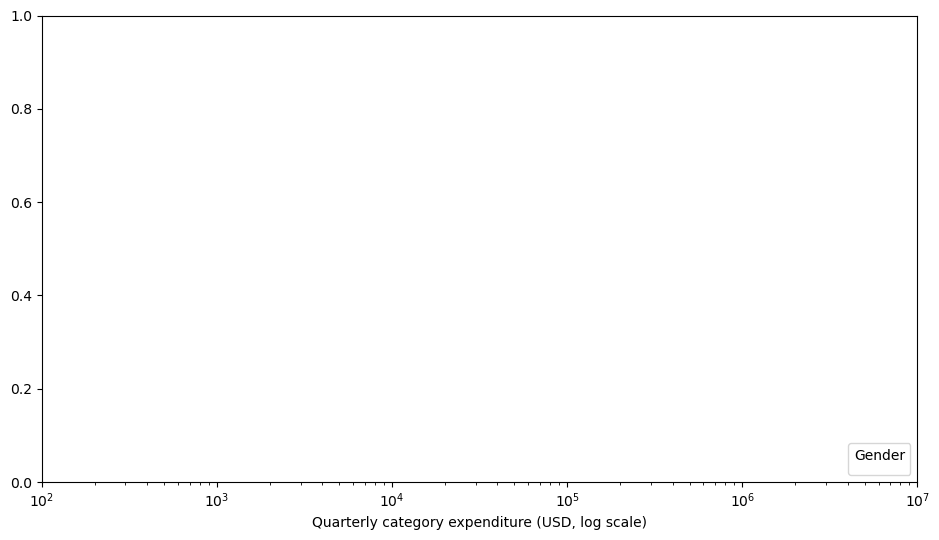

In [136]:
# Figure 7 (revised, R1 to Reviewer 3):
# Replaces the bar-with-error-bar plot with paired boxplots (showfliers off).
# Heavy right skew makes t-tests on raw amounts unreliable, so the
# accompanying statistics report (i) sample size per group, (ii) Welch's t
# on log10-transformed amounts with Cohen's d on the log scale, and
# (iii) Mann–Whitney U with rank-biserial r as a nonparametric check.
# Colour key (for caption): orange = female; teal = male.

# 1. Report sample sizes — Reviewer 3 noted this was omitted.
gender_counts = clean_bio_cat_df.groupby('gender').size()
gender_unique_members = clean_bio_cat_df.groupby('gender')['BIOGUIDE_ID'].nunique()
print("Sample sizes:")
for g in ['M', 'F']:
    n_obs = int(gender_counts.get(g, 0))
    n_mem = int(gender_unique_members.get(g, 0))
    print(f"  {g}: {n_obs:,} member-quarter-category observations, {n_mem:,} unique members")
print()

# 2. Paired boxplots, sorted by overall median
_order = clean_bio_cat_df.groupby('CATEGORY')['AMOUNT'].median().sort_values().index.tolist()
gender_palette = {'F': '#DD8452', 'M': '#4C72B0'}

f, ax = plt.subplots(figsize=(9.5, 5.5))
sb.boxplot(
    data=clean_bio_cat_df,
    x='AMOUNT',
    y='CATEGORY',
    hue='gender',
    order=_order,
    palette=gender_palette,
    showfliers=False,
    ax=ax,
)
ax.set_xscale('log')
ax.set_xlim((1e2, 1e7))
ax.set_xlabel('Quarterly category expenditure (USD, log scale)')
ax.set_ylabel(None)
ax.legend(title='Gender', loc='lower right')

# 3. Report tests for each category — log-transformed parametric and
#    nonparametric, with effect sizes.
print("Per-category tests (log10 amounts):")
print(f"{'Category':<32s} {'N_M':>5s} {'N_F':>5s} "
      f"{'t(log)':>7s} {'p(t)':>9s} {'d':>6s} "
      f"{'p(MWU)':>9s} {'rb':>6s}")
for _cat in _order:
    _c0 = clean_bio_cat_df['CATEGORY'] == _cat
    _men = clean_bio_cat_df.loc[_c0 & (clean_bio_cat_df['gender'] == 'M'), 'AMOUNT']
    _women = clean_bio_cat_df.loc[_c0 & (clean_bio_cat_df['gender'] == 'F'), 'AMOUNT']
    n1, n2 = len(_men), len(_women)
    if n1 < 5 or n2 < 5:
        continue

    _men_log = np.log10(_men[_men > 0])
    _women_log = np.log10(_women[_women > 0])
    t_log = stats.ttest_ind(_men_log, _women_log, equal_var=False)
    pooled_sd = np.sqrt((_men_log.var(ddof=1) + _women_log.var(ddof=1)) / 2)
    cohens_d = (_men_log.mean() - _women_log.mean()) / pooled_sd if pooled_sd > 0 else np.nan

    mw = stats.mannwhitneyu(_men, _women, alternative='two-sided')
    rb = 1 - 2 * mw.statistic / (n1 * n2)

    print(f"{_cat[:32]:<32s} {n1:>5d} {n2:>5d} "
          f"{t_log.statistic:>7.2f} {t_log.pvalue:>9.2e} {cohens_d:>6.2f} "
          f"{mw.pvalue:>9.2e} {rb:>6.2f}")

f.tight_layout()
f.savefig('category_spending_gender.png', dpi=300, bbox_inches='tight')


Sample sizes:
  D: 0 member-quarter-category observations, 0 unique members
  R: 0 member-quarter-category observations, 0 unique members

Per-category tests (log10 amounts):
Category                           N_D   N_R  t(log)      p(t)      d    p(MWU)     rb


/var/folders/lr/v195xr617d32k2zdwwh30sb40000gn/T/ipykernel_77558/1622372952.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Party', loc='lower right')


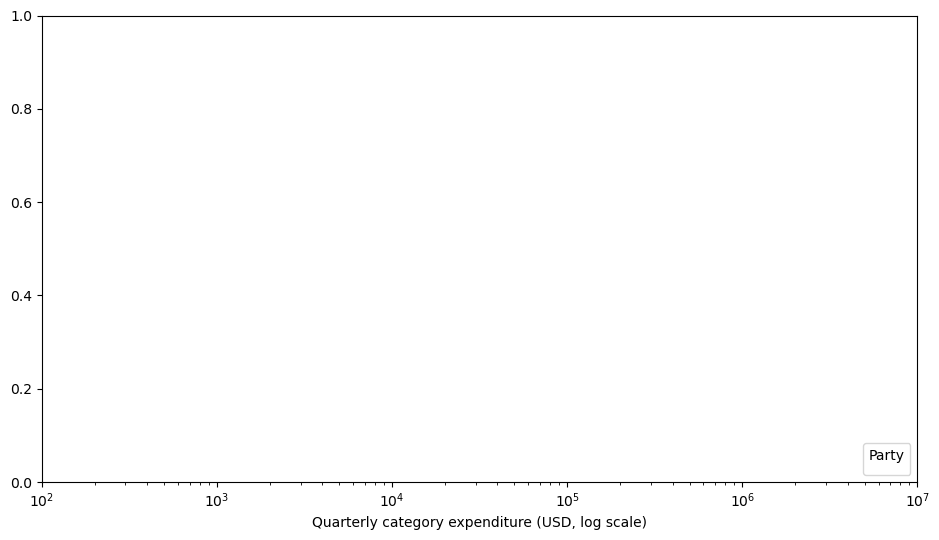

In [128]:
# Figure 8 (revised, R1 to Reviewer 3):
# Same treatment as Figure 7, by party.
# Colour key (for caption): blue = Democratic; red = Republican.

party_counts = clean_bio_cat_df[clean_bio_cat_df['party'].isin(['D','R'])].groupby('party').size()
party_unique_members = (
    clean_bio_cat_df[clean_bio_cat_df['party'].isin(['D','R'])]
    .groupby('party')['BIOGUIDE_ID'].nunique()
)
print("Sample sizes:")
for p in ['D', 'R']:
    n_obs = int(party_counts.get(p, 0))
    n_mem = int(party_unique_members.get(p, 0))
    print(f"  {p}: {n_obs:,} member-quarter-category observations, {n_mem:,} unique members")
print()

_order = clean_bio_cat_df.groupby('CATEGORY')['AMOUNT'].median().sort_values().index.tolist()
party_palette = {'D': '#3274A1', 'R': '#C44E52'}

f, ax = plt.subplots(figsize=(9.5, 5.5))
sb.boxplot(
    data=clean_bio_cat_df[clean_bio_cat_df['party'].isin(['D','R'])],
    x='AMOUNT',
    y='CATEGORY',
    hue='party',
    hue_order=['D', 'R'],
    order=_order,
    palette=party_palette,
    showfliers=False,
    ax=ax,
)
ax.set_xscale('log')
ax.set_xlim((1e2, 1e7))
ax.set_xlabel('Quarterly category expenditure (USD, log scale)')
ax.set_ylabel(None)
ax.legend(title='Party', loc='lower right')

print("Per-category tests (log10 amounts):")
print(f"{'Category':<32s} {'N_D':>5s} {'N_R':>5s} "
      f"{'t(log)':>7s} {'p(t)':>9s} {'d':>6s} "
      f"{'p(MWU)':>9s} {'rb':>6s}")
for _cat in _order:
    _c0 = clean_bio_cat_df['CATEGORY'] == _cat
    _dem = clean_bio_cat_df.loc[_c0 & (clean_bio_cat_df['party'] == 'D'), 'AMOUNT']
    _rep = clean_bio_cat_df.loc[_c0 & (clean_bio_cat_df['party'] == 'R'), 'AMOUNT']
    n1, n2 = len(_dem), len(_rep)
    if n1 < 5 or n2 < 5:
        continue

    _dem_log = np.log10(_dem[_dem > 0])
    _rep_log = np.log10(_rep[_rep > 0])
    t_log = stats.ttest_ind(_dem_log, _rep_log, equal_var=False)
    pooled_sd = np.sqrt((_dem_log.var(ddof=1) + _rep_log.var(ddof=1)) / 2)
    cohens_d = (_dem_log.mean() - _rep_log.mean()) / pooled_sd if pooled_sd > 0 else np.nan

    mw = stats.mannwhitneyu(_dem, _rep, alternative='two-sided')
    rb = 1 - 2 * mw.statistic / (n1 * n2)

    print(f"{_cat[:32]:<32s} {n1:>5d} {n2:>5d} "
          f"{t_log.statistic:>7.2f} {t_log.pvalue:>9.2e} {cohens_d:>6.2f} "
          f"{mw.pvalue:>9.2e} {rb:>6.2f}")

f.tight_layout()
f.savefig('category_spending_party.png', dpi=300, bbox_inches='tight')


HC:
1. Pull list of members (systems controls) who "left/lost access/separated" and still getting compensated/reimbursed. Are payments acceptable? Cross-over between temporal and categorical anomalies.
2. Laurie website on fraud scores for members of congress and we validate against these results. External validity for our ensemble of scores.

## Temporal anomalies

In [88]:
members_travel_df = members_df[members_df['CATEGORY'] == 'TRAVEL']
members_travel_df.head()

,YEAR-QUARTER,YEAR,QUARTER,TERM_QUARTER,BIOGUIDE_ID,OFFICE,PROGRAM,CATEGORY,PAYEE,PURPOSE,AMOUNT,DATE,PERIOD_DATE,DATE_IS_RECONSTRUCTED,START DATE,END DATE,TRANSCODE,RECORDID,VOUCHER_ID
6442,2011Q1,2011,Q1,1,A000022,HON. GARY L. ACKERMAN,NaN,TRAVEL,CITIBANK GOV CARD SERVICE,COMMERCIAL TRANSPORTATION,125.40,2011-01-14,2011-01-14,False,2011-01-04,2011-01-04,AP,00071191,CITIBANK GOV CARD SERVICE
6443,2011Q1,2011,Q1,1,A000022,HON. GARY L. ACKERMAN,NaN,TRAVEL,INTABORO,TAXI/PARKING/TOLLS,93.14,2011-03-02,2011-03-02,False,2011-01-05,2011-01-05,AP,00104251,INTABORO
6444,2011Q1,2011,Q1,1,A000022,HON. GARY L. ACKERMAN,NaN,TRAVEL,"MOSKOWITZ, JEDD I",TAXI/PARKING/TOLLS,12.00,2011-03-02,2011-03-02,False,2011-02-11,2011-02-11,AP,00104259,"MOSKOWITZ, JEDD I"
6445,2011Q1,2011,Q1,1,A000022,HON. GARY L. ACKERMAN,NaN,TRAVEL,"MOSKOWITZ, JEDD I",TAXI/PARKING/TOLLS,30.00,2011-03-02,2011-03-02,False,2011-02-17,2011-02-17,AP,00104260,"MOSKOWITZ, JEDD I"
6446,2011Q1,2011,Q1,1,A000022,HON. GARY L. ACKERMAN,NaN,TRAVEL,"MOSKOWITZ, JEDD I",MEALS,2.47,2011-03-10,2011-03-10,False,2011-02-19,2011-02-19,AP,00111271,"MOSKOWITZ, JEDD I"


#### Check for pre-billing

"END DATE" - "DATE" if negative: Travel advances vs. travel reimbursements

In [89]:
before_dates = members_travel_df['DATE'] - members_travel_df['START DATE']
before_dates = before_dates/pd.Timedelta(1,'d')
before_dates = before_dates[before_dates < 0]

/var/folders/lr/v195xr617d32k2zdwwh30sb40000gn/T/ipykernel_77558/3466938989.py:2: Pandas4Warning: 'd' is deprecated and will be removed in a future version. Please use 'D' instead of 'd'.
  before_dates = before_dates/pd.Timedelta(1,'d')


In [90]:
members_travel_df.loc[before_dates.sort_values().index,'YEAR'].value_counts().sort_index()

YEAR
2011     56
2012     46
2013     54
2014     66
2015     52
2016     43
2017     26
2018     38
2019     43
2020     29
2021     31
2022    118
Name: count, dtype: int64

#### Check for impact of COVID-19

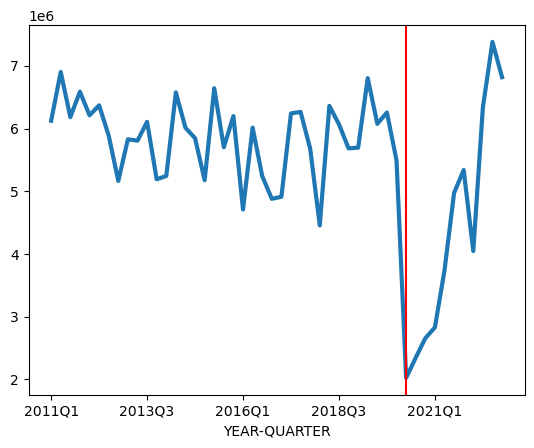

In [91]:
ax = members_travel_df.groupby('YEAR-QUARTER').agg({'AMOUNT':'sum'})['AMOUNT'].plot(lw=3)
ax.axvline(37,color='r')


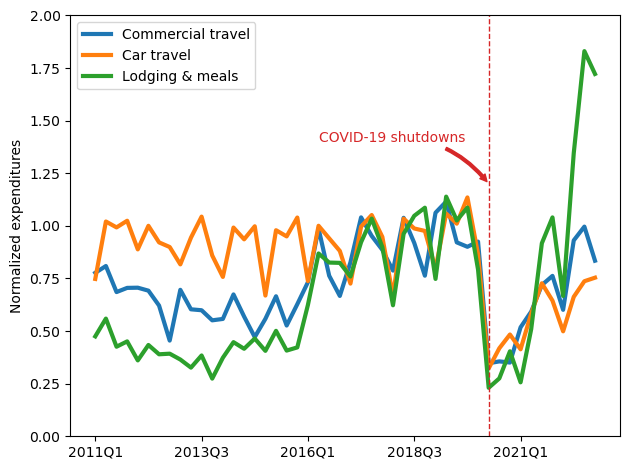

In [92]:
_df0 = members_travel_df[members_travel_df['PURPOSE'].isin(['COMMERCIAL TRANSPORTATION','AIRFARE COMMERCIAL TRANSPORT'])]
_df1 = members_travel_df[members_travel_df['PURPOSE'].isin(['PRIVATE AUTO MILEAGE','GASOLINE','TAXI/PARKING/TOLLS'])]
_df2 = members_travel_df[members_travel_df['PURPOSE'].isin(['LODGING','MEALS'])]

f,ax = plt.subplots()
_df0_agg = _df0.groupby('YEAR-QUARTER').agg({'AMOUNT':'sum'})['AMOUNT']
_df1_agg = _df1.groupby('YEAR-QUARTER').agg({'AMOUNT':'sum'})['AMOUNT']
_df2_agg = _df2.groupby('YEAR-QUARTER').agg({'AMOUNT':'sum'})['AMOUNT']

_df0_norm = _df0_agg.div(_df0_agg.loc[['2019Q1','2019Q2','2019Q3','2019Q4']].mean())
_df1_norm = _df1_agg.div(_df1_agg.loc[['2019Q1','2019Q2','2019Q3','2019Q4']].mean())
_df2_norm = _df2_agg.div(_df2_agg.loc[['2019Q1','2019Q2','2019Q3','2019Q4']].mean())

_df0_norm.plot(lw=3,ax=ax,label='Commercial travel')
_df1_norm.plot(lw=3,ax=ax,label='Car travel')
_df2_norm.plot(lw=3,ax=ax,label='Lodging & meals')

ax.axvline(37,color='tab:red',ls='--',lw=1)
ax.legend()
ax.set_ylim((0,2))
ax.set_ylabel('Normalized expenditures')
ax.set_xlabel(None)
ax.annotate(
    'COVID-19 shutdowns',
    xy=(37,1.2),
    xytext=(21,1.4),
    color='tab:red',
    arrowprops={
        'facecolor':'tab:red',
        'edgecolor':'tab:red',
        'arrowstyle':'simple',
        'connectionstyle':'arc3,rad=-0.25'
    }
)

f.tight_layout()
f.savefig('temporal_covid_shutdowns.png',dpi=300,bbox_inches='tight')

In [93]:
_df1_agg.iloc[36:48].shape,_df1_agg.iloc[24:36].shape

((12,), (12,))

In [94]:
stats.ttest_ind(_df1_agg.iloc[36:48],_df1_agg.iloc[24:36])

TtestResult(statistic=np.float64(-5.617400821710344), pvalue=np.float64(1.1984548179613084e-05), df=np.float64(22.0))

HC: Break it on party affiliation to see how it changes.

In [95]:
travel_by_member = members_travel_df.groupby(['YEAR-QUARTER','BIOGUIDE_ID']).agg({'AMOUNT':'sum'}).reset_index()

travel_by_member[['gender','party']] = travel_by_member['BIOGUIDE_ID'].apply(lambda x:pd.Series(bioguide_gender_party_map.get(x)))

travel_by_member.head()


,YEAR-QUARTER,BIOGUIDE_ID,AMOUNT,gender,party
0,2011Q1,A000022,4408.29,M,Democrat
1,2011Q1,A000055,10240.27,M,Republican
2,2011Q1,A000210,4984.00,M,Democrat
3,2011Q1,A000358,8645.69,M,Republican
4,2011Q1,A000361,38696.55,M,Republican


In [96]:
travel_by_member.groupby(['YEAR-QUARTER','party']).agg({'AMOUNT':'sum','BIOGUIDE_ID':'nunique'})

AMOUNT  BIOGUIDE_ID
YEAR-QUARTER party                              
2011Q1       Democrat    2702087.19          265
             Libertarian    5028.78            1
             Republican  3417955.82          263
2011Q2       Democrat    2663212.06          216
             Libertarian    6197.06            1
...                             ...          ...
2022Q2       Republican  3790100.81          217
2022Q3       Democrat    3080501.68          220
             Republican  4293352.49          219
2022Q4       Democrat    2799689.23          220
             Republican  4014792.52          218

[169 rows x 2 columns]

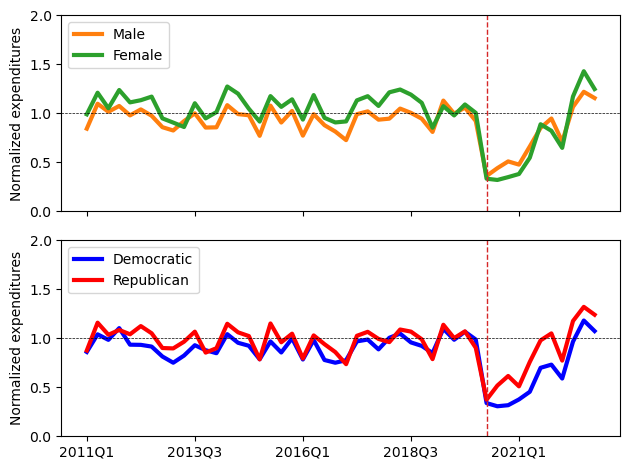

In [98]:
travel_gender_df = travel_by_member.groupby(['YEAR-QUARTER','gender']).agg({'AMOUNT':'sum','BIOGUIDE_ID':'nunique'})
travel_gender_df = travel_gender_df['AMOUNT'] / travel_gender_df['BIOGUIDE_ID']
travel_gender_df = travel_gender_df.unstack(1)
travel_gender_df = travel_gender_df.div(travel_gender_df.loc[['2019Q1','2019Q2','2019Q3','2019Q4']].mean())

travel_party_df = travel_by_member.groupby(['YEAR-QUARTER','party']).agg({'AMOUNT':'sum','BIOGUIDE_ID':'nunique'})
travel_party_df = travel_party_df['AMOUNT'] / travel_party_df['BIOGUIDE_ID']
travel_party_df = travel_party_df.unstack(1)
travel_party_df = travel_party_df.div(travel_party_df.loc[['2019Q1','2019Q2','2019Q3','2019Q4']].mean())

f,axs = plt.subplots(2,1,sharex=True)
travel_gender_df.loc[:,['M','F']].plot.line(ax=axs[0],lw=3,color=['tab:orange','tab:green'])
travel_party_df.loc[:,['Democrat','Republican']].plot(ax=axs[1],lw=3,color=['blue','red'])

axs[0].set_ylim((0,2))
axs[1].set_ylim((0,2))

axs[0].legend(['Male','Female'],loc='upper left')
axs[1].legend(['Democratic','Republican'],loc='upper left')

axs[0].set_ylabel('Normalized expenditures')
axs[1].set_ylabel('Normalized expenditures')
axs[1].set_xlabel(None)

axs[0].axhline(1,ls='--',lw=.5,c='k')
axs[1].axhline(1,ls='--',lw=.5,c='k')

axs[0].axvline(37,color='tab:red',ls='--',lw=1)
axs[1].axvline(37,color='tab:red',ls='--',lw=1)

f.tight_layout()

/var/folders/lr/v195xr617d32k2zdwwh30sb40000gn/T/ipykernel_77558/1557284076.py:3: Pandas4Warning: Starting with pandas version 4.0 all arguments of mean will be keyword-only.
  pandemic_impact_norm = travel_by_member_pivot.loc[:,'2020Q2'] / travel_by_member_pivot.loc[:,['2019Q1','2019Q2','2019Q3','2019Q4']].mean(1)


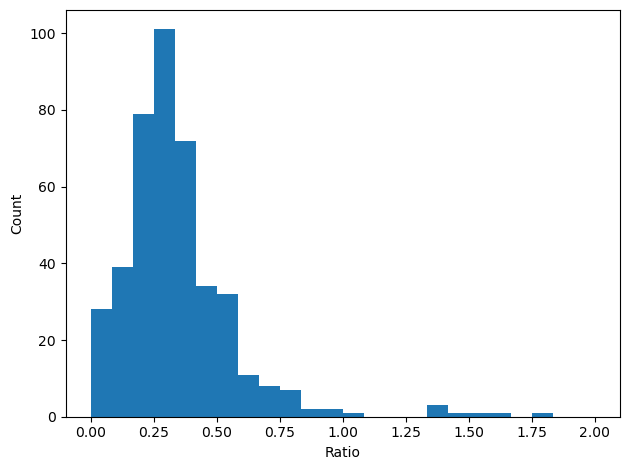

In [99]:
travel_by_member_pivot = travel_by_member.pivot(index=['BIOGUIDE_ID'],columns=['YEAR-QUARTER'],values='AMOUNT')

pandemic_impact_norm = travel_by_member_pivot.loc[:,'2020Q2'] / travel_by_member_pivot.loc[:,['2019Q1','2019Q2','2019Q3','2019Q4']].mean(1)
pandemic_impact_norm.dropna(inplace=True)

f,ax = plt.subplots()
pandemic_impact_norm.hist(bins=np.linspace(0,2,25),ax=ax)
ax.grid(None)
ax.set_xlabel('Ratio')
ax.set_ylabel('Count')

f.tight_layout()
f.savefig('pandemic_impact_hist.png',dpi=300,bbox_inches='tight')

In [100]:
len(pandemic_impact_norm[pandemic_impact_norm < 1]) / len(pandemic_impact_norm)

0.9788235294117648

In [101]:
pandemic_impact_norm[pandemic_impact_norm >= 1]

BIOGUIDE_ID
B001307   1.40
C001090   1.61
C001120   1.05
G000589   1.34
H001038   1.80
H001065   2.01
L000557   1.50
L000590   1.49
W000187   1.34
dtype: float64

In [102]:
pandemic_impact_norm.mean()

np.float64(0.3448850131404217)

In [103]:
travel_by_member_pivot.loc['H001065',['2019Q1','2019Q2','2019Q3','2019Q4']].mean(), travel_by_member_pivot.loc['H001065','2020Q2']


(np.float64(6078.567500000001), np.float64(12191.21))

In [104]:
c0 = members_travel_df['BIOGUIDE_ID'] == 'H001065'
c1 = members_travel_df['YEAR-QUARTER'] == '2020Q2'
c2 = members_travel_df['CATEGORY'] == 'TRAVEL'
c3 = members_travel_df['PURPOSE'] == 'CAR RENTAL'
members_travel_df.loc[c0 & c1 & c2 & c3,:]#'AMOUNT'].sum()

,YEAR-QUARTER,YEAR,QUARTER,TERM_QUARTER,BIOGUIDE_ID,OFFICE,PROGRAM,CATEGORY,PAYEE,PURPOSE,AMOUNT,DATE,PERIOD_DATE,DATE_IS_RECONSTRUCTED,START DATE,END DATE,TRANSCODE,RECORDID,VOUCHER_ID
3746747,2020Q2,2020,Q2,6,H001065,2020 HON. GEORGE HOLDING,OFFICIAL EXPENSES OF MEMBERS,TRAVEL,CITIBANK GOV CARD SERVICE,CAR RENTAL,1815.70,2020-05-19,2020-05-19,False,2020-04-10,2020-04-20,AP,1289779,NaN
3746750,2020Q2,2020,Q2,6,H001065,2020 HON. GEORGE HOLDING,OFFICIAL EXPENSES OF MEMBERS,TRAVEL,CITIBANK GOV CARD SERVICE,CAR RENTAL,2826.71,2020-06-17,2020-06-17,False,2020-04-10,2020-05-12,AP,1301094,NaN
3746751,2020Q2,2020,Q2,6,H001065,2020 HON. GEORGE HOLDING,OFFICIAL EXPENSES OF MEMBERS,TRAVEL,CITIBANK GOV CARD SERVICE,CAR RENTAL,687.12,2020-06-17,2020-06-17,False,2020-05-12,2020-05-19,AP,1301094,NaN


In [105]:
members_travel_df.loc[c0 & c1 & c2,:].groupby('PURPOSE').agg({'AMOUNT':'sum'})

,AMOUNT
PURPOSE,
CAR RENTAL,5329.53
COMMERCIAL TRANSPORTATION,3131.00
GASOLINE,262.49
LODGING,2111.86
MEALS,118.24
TAXI/PARKING/TOLLS,1238.09


In [106]:
c0 = members_travel_df['BIOGUIDE_ID'] == 'H001065'
c1 = members_travel_df['YEAR-QUARTER'] == '2020Q2'
c2 = members_travel_df['CATEGORY'] == 'TRAVEL'
members_travel_df.loc[c0 & c1 & c2,:].groupby('PURPOSE').agg({'AMOUNT':'sum'})

,AMOUNT
PURPOSE,
CAR RENTAL,5329.53
COMMERCIAL TRANSPORTATION,3131.00
GASOLINE,262.49
LODGING,2111.86
MEALS,118.24
TAXI/PARKING/TOLLS,1238.09


In [107]:
c0 = members_travel_df['BIOGUIDE_ID'] == 'H001065'
c4 = members_travel_df['YEAR-QUARTER'] == '2019Q2'
c2 = members_travel_df['CATEGORY'] == 'TRAVEL'
members_travel_df.loc[c0 & c4 & c2,:].groupby('PURPOSE').agg({'AMOUNT':'sum'})

,AMOUNT
PURPOSE,
COMMERCIAL TRANSPORTATION,3723.14
MEALS,6.93
PRIVATE AUTO MILEAGE,334.48
TAXI/PARKING/TOLLS,1655.01


In [108]:
members_travel_df.loc[c0 & c1 & c2,:].groupby('PURPOSE').agg({'AMOUNT':'sum'}).loc['CAR RENTAL']/members_travel_df.loc[c1 & c2 & c3,:].groupby('BIOGUIDE_ID').agg({'AMOUNT':'sum'}).mean()

AMOUNT   6.85
dtype: float64

#### Cyclical spending

(1000.0, 1000000.0)

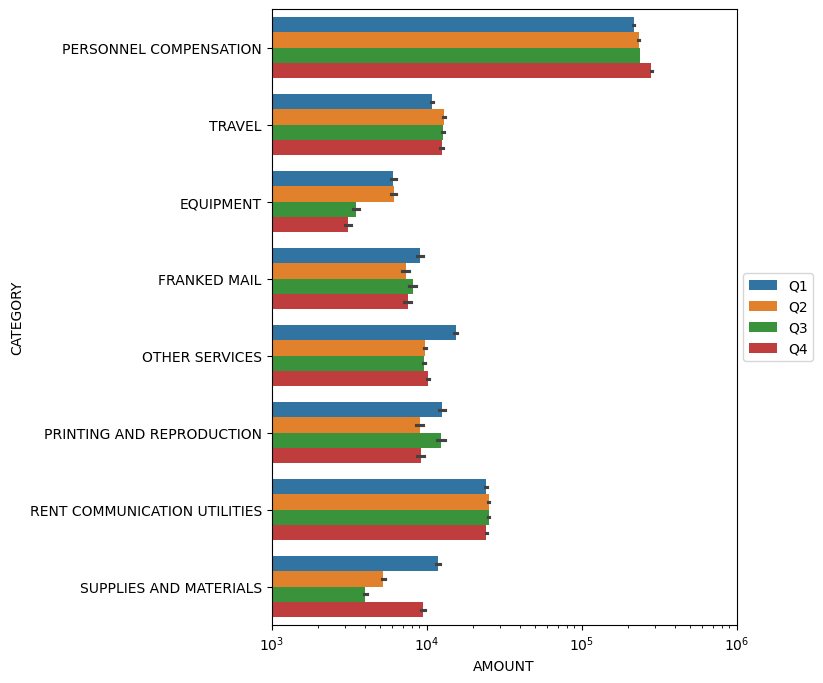

In [109]:
populated_categories = members_df['CATEGORY'].value_counts().index[:-3]
member_quarterly_spending_by_category_df = members_df[members_df['CATEGORY'].isin(populated_categories)]
member_quarterly_spending_by_category_df = member_quarterly_spending_by_category_df.groupby(['BIOGUIDE_ID','YEAR','QUARTER','CATEGORY']).agg({'AMOUNT':'sum'})
member_quarterly_spending_by_category_df.reset_index(inplace=True)

f,ax = plt.subplots(figsize=(6,8))
sb.barplot(
    data = member_quarterly_spending_by_category_df,
    x = 'AMOUNT',
    y = 'CATEGORY',
    hue = 'QUARTER',
    ax = ax
)

ax.legend(loc='center left',bbox_to_anchor=(1,.5))
ax.set_xscale('log')
ax.set_xlim((1e3,1e6))

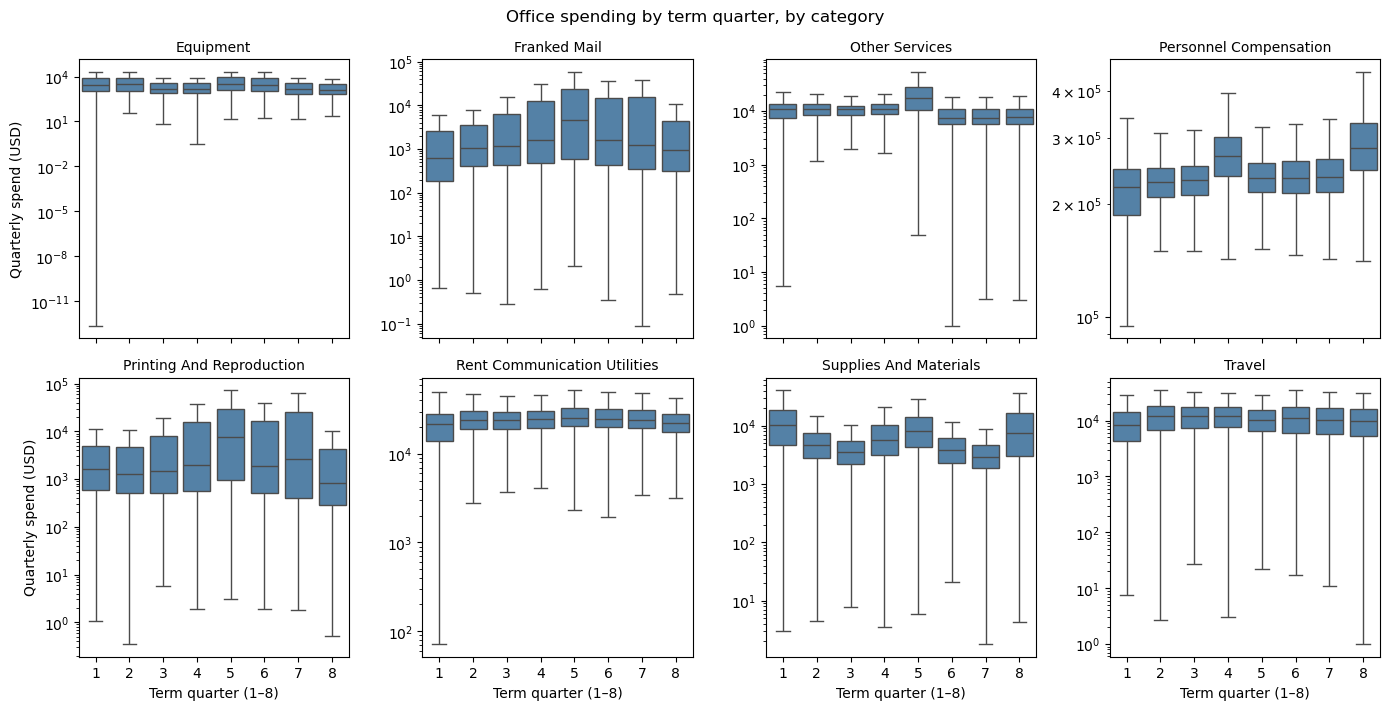

In [110]:
# Figure 10 (revised, R1 to Reviewer 3):
# Replaces the multi-colour bar chart (whose "black tips" were Seaborn's
# bootstrap CIs) with a small-multiples grid. Each category gets its own
# panel, with term quarter on the x-axis and quarterly spend (log scale)
# on the y-axis. Boxplots show distribution shape with `showfliers=False`.

populated_categories = members_df['CATEGORY'].value_counts().index[:-3]
member_termly_spending_by_category_df = members_df[members_df['CATEGORY'].isin(populated_categories)]
member_termly_spending_by_category_df = (
    member_termly_spending_by_category_df
    .groupby(['BIOGUIDE_ID','YEAR','TERM_QUARTER','CATEGORY'])
    .agg({'AMOUNT':'sum'})
    .reset_index()
)

cats_to_plot = sorted(member_termly_spending_by_category_df['CATEGORY'].unique())
n_cats = len(cats_to_plot)
n_cols = 4
n_rows = int(np.ceil(n_cats / n_cols))

f, axs = plt.subplots(n_rows, n_cols, figsize=(14, 3.6 * n_rows), sharex=True)
axs = np.array(axs).flatten()

for i, _cat in enumerate(cats_to_plot):
    ax = axs[i]
    _sub = member_termly_spending_by_category_df[
        member_termly_spending_by_category_df['CATEGORY'] == _cat
    ]
    _sub_pos = _sub[_sub['AMOUNT'] > 0]
    sb.boxplot(
        data=_sub_pos,
        x='TERM_QUARTER',
        y='AMOUNT',
        ax=ax,
        color='steelblue',
        showfliers=False,
    )
    ax.set_yscale('log')
    ax.set_title(_cat.title(), fontsize=10)
    ax.set_xlabel('Term quarter (1–8)' if i >= n_cats - n_cols else '')
    ax.set_ylabel('Quarterly spend (USD)' if i % n_cols == 0 else '')

for j in range(n_cats, len(axs)):
    axs[j].axis('off')

f.suptitle('Office spending by term quarter, by category', fontsize=12)
f.tight_layout()
f.savefig('spending_term_quarter.png', dpi=300, bbox_inches='tight')


Q3 AY is Q4 FY, members are spending down budgets in Q3 before appropriations.

HC: Comparing newcomer to incumbent, HC to find cite for govt expenditures increase in FY Q4

In [111]:
quarterly_category_spending = pd.pivot_table(
    data = member_quarterly_spending_by_category_df,
    index = 'CATEGORY',
    columns = 'QUARTER',
    values = 'AMOUNT',
    aggfunc = 'median'
)

quarterly_category_spending

QUARTER,Q1,Q2,Q3,Q4
CATEGORY,,,,
EQUIPMENT,2941.50,2905.25,1474.72,1300.80
FRANKED MAIL,1004.00,1111.52,1104.74,1116.33
OTHER SERVICES,11842.53,9675.00,9675.00,10005.00
PERSONNEL COMPENSATION,228465.45,231219.16,233148.60,273944.16
PRINTING AND REPRODUCTION,2292.81,1473.55,1708.64,1258.53
RENT COMMUNICATION UTILITIES,23552.24,24111.81,23881.81,23241.56
SUPPLIES AND MATERIALS,8881.79,4067.42,3190.54,6227.19
TRAVEL,9281.29,11680.67,11053.31,10937.28


In [112]:
for _cat in quarterly_category_spending.index:
    _obs = quarterly_category_spending.loc[_cat]
    _exp = [quarterly_category_spending.loc[_cat].mean()] * 4
    _chi2 = stats.chisquare(_obs,_exp)
    print(_cat,_chi2.pvalue)

EQUIPMENT 1.910937780601982e-238
FRANKED MAIL 0.04678119278285587
OTHER SERVICES 4.7899029125126e-68
PERSONNEL COMPENSATION 0.0
PRINTING AND REPRODUCTION 1.6766107114686506e-76
RENT COMMUNICATION UTILITIES 0.00037422003897551214
SUPPLIES AND MATERIALS 0.0
TRAVEL 2.770560917721128e-63


In [113]:
quarterly_category_spending = pd.pivot_table(
    data = member_termly_spending_by_category_df,
    index = 'CATEGORY',
    columns = 'TERM_QUARTER',
    values = 'AMOUNT',
    aggfunc = 'median'
)

quarterly_category_spending

TERM_QUARTER,1,2,3,4,5,6,7,8
CATEGORY,,,,,,,,
EQUIPMENT,2710.22,2961.18,1509.30,1423.90,3243.23,2838.36,1428.00,1226.52
FRANKED MAIL,568.47,988.88,1106.70,1476.78,3988.34,1344.69,1102.07,880.55
OTHER SERVICES,10695.00,10935.00,10725.00,10989.00,17284.26,7228.50,7257.23,7567.77
PERSONNEL COMPENSATION,222268.05,228537.45,231404.82,267306.55,234780.51,233861.88,235239.10,281573.15
PRINTING AND REPRODUCTION,1585.46,1292.30,1451.12,1896.55,7439.24,1873.90,2551.08,837.04
RENT COMMUNICATION UTILITIES,21877.49,23718.86,23640.49,24385.16,25449.46,24638.63,24203.46,22073.56
SUPPLIES AND MATERIALS,9970.58,4497.07,3474.93,5515.63,8155.24,3736.33,2869.30,7507.97
TRAVEL,8440.38,12084.33,11718.59,12048.74,10293.16,11272.38,10435.67,9929.24


#### Interevent timing 

HC: Pre/post presidential election, do franked mail costs change in month before and after election?  
HC: Conscienciousness about filing expenses, auditing for good

In [114]:
interevent_data = members_df.copy().sort_values(['BIOGUIDE_ID','CATEGORY','DATE'],ascending=True)
interevent_data = interevent_data.groupby(['BIOGUIDE_ID','CATEGORY'])
interevent_data = interevent_data['DATE'].diff()/pd.Timedelta(1,'d')
interevent_data.dropna(inplace=True)

interevent_counts = interevent_data.value_counts()
interevent_counts.index.name = 'index'
interevent_counts.sort_index(inplace=True)

/var/folders/lr/v195xr617d32k2zdwwh30sb40000gn/T/ipykernel_77558/3659523161.py:3: Pandas4Warning: 'd' is deprecated and will be removed in a future version. Please use 'D' instead of 'd'.
  interevent_data = interevent_data['DATE'].diff()/pd.Timedelta(1,'d')


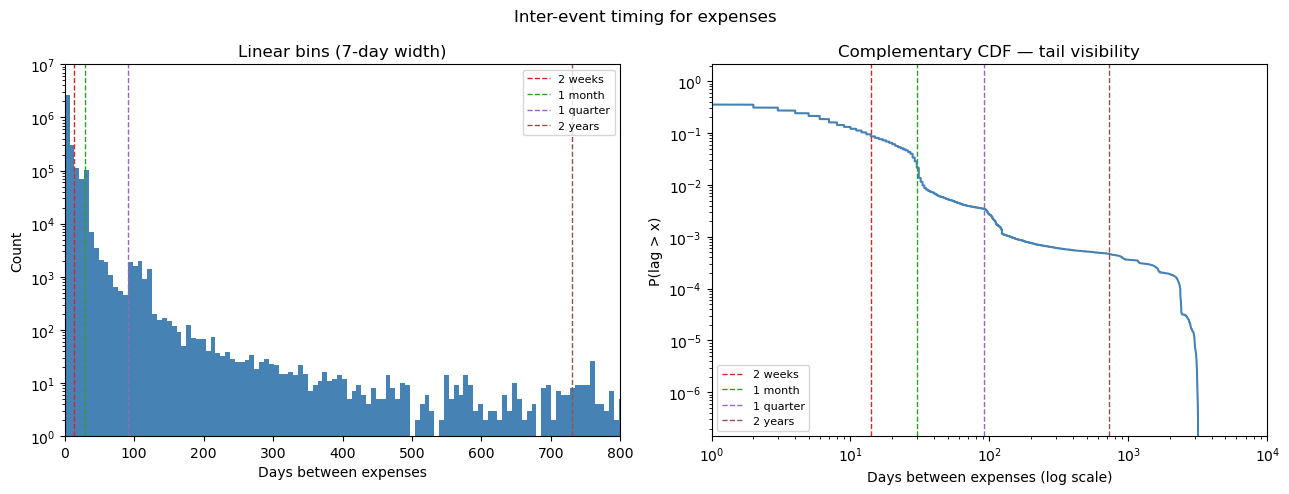

In [115]:
# Figure 11 (revised, R1 to Reviewer 3):
# Reviewer noted that log binning expanded the short-lag region at the cost
# of the long-lag tail, which is where the more interpretively interesting
# anomalies live. The revision uses (a) a linear 7-day-binned histogram
# over the full meaningful range, and (b) a complementary CDF on log–log
# axes that makes the tail visually interpretable. Cycle markers are kept
# in both panels.
# Colour key (for caption): steelblue = empirical distribution; dashed
# vertical lines mark cycles at 2 weeks (red), 1 month (green),
# 1 quarter (purple), and 2 years (brown).

cycles = [
    (14,    '2 weeks',   'tab:red'),
    (30,    '1 month',   'tab:green'),
    (91,    '1 quarter', 'tab:purple'),
    (365*2, '2 years',   'tab:brown'),
]

f, axs = plt.subplots(1, 2, figsize=(13, 5))

# Panel A: linear bins
ax = axs[0]
bins = np.arange(0, interevent_data.max() + 7, 7)
ax.hist(interevent_data, bins=bins, color='steelblue', edgecolor='none')
ax.set_yscale('log')
ax.set_xlim((0, 800))
ax.set_ylim((1e0, 1e7))
ax.set_xlabel('Days between expenses')
ax.set_ylabel('Count')
ax.set_title('Linear bins (7-day width)')
for x, label, color in cycles:
    if x <= ax.get_xlim()[1]:
        ax.axvline(x, color=color, lw=1, ls='--', label=label)
ax.legend(fontsize=8, loc='upper right')

# Panel B: CCDF — tail-focused
ax = axs[1]
sorted_lags = np.sort(interevent_data.values)
ccdf = 1.0 - np.arange(1, len(sorted_lags) + 1) / len(sorted_lags)
ax.plot(sorted_lags, ccdf, color='steelblue', lw=1.5)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim((1, 1e4))
ax.set_xlabel('Days between expenses (log scale)')
ax.set_ylabel('P(lag > x)')
ax.set_title('Complementary CDF — tail visibility')
for x, label, color in cycles:
    ax.axvline(x, color=color, lw=1, ls='--', label=label)
ax.legend(fontsize=8, loc='lower left')

f.suptitle('Inter-event timing for expenses', fontsize=12)
f.tight_layout()
f.savefig('interevent_anomalies.png', dpi=300, bbox_inches='tight')


In [116]:
interevent_data.value_counts(normalize=1).sort_index().head(10)

DATE
0.00   0.56
1.00   0.08
2.00   0.04
3.00   0.04
4.00   0.03
5.00   0.03
6.00   0.03
7.00   0.03
8.00   0.02
9.00   0.01
Name: proportion, dtype: float64

In [117]:
interevent_data.value_counts().sort_index().reset_index()

,DATE,count
0,0.00,1854315
1,1.00,275044
2,2.00,145553
3,3.00,124683
4,4.00,101491
...,...,...
1323,3136.00,1
1324,3147.00,1
1325,3161.00,1
1326,3171.00,1


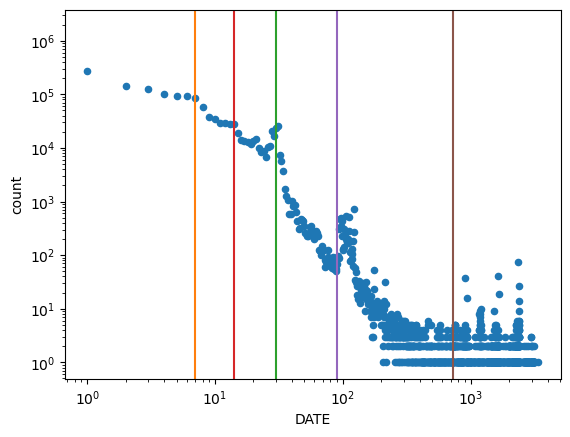

In [118]:
_df = interevent_data.value_counts().sort_index().reset_index()

ax = _df.plot(kind='scatter',x='DATE',y='count')
ax.set_xscale('log')
ax.set_yscale('log')

ax.axvline(7,c='tab:orange',label='One week')
ax.axvline(14,c='tab:red',label='Two weeks')
ax.axvline(30,c='tab:green',label='One month')
ax.axvline(90,c='tab:purple',label='One quarter')
ax.axvline(365*2,c='tab:brown',label='Two years')

HC: People at the 2-year bump are likely to have more discrepancies, they're loading up all their expenses at the end  
HC: Patterns hold up across categories? 90-day rule for reimbursements being taxable forcing stuff  
HC: Did rule change on reimbursements and how is that affecting behavior?  

## Spatial anomalies

HC: Compare members within state to each other, particularly for travel, Guam travel should be highest  
HC: Travel receipts for times when they were also voting?  
BK: Spatial patterns by office? Social influence/comparison could drive anomaly-generating behavior  

In [141]:
members_bioguide_travel_df = members_bioguide_df[members_bioguide_df['CATEGORY'] == 'TRAVEL']
members_bioguide_travel_df

,YEAR-QUARTER,YEAR,QUARTER,TERM_QUARTER,BIOGUIDE_ID,OFFICE,PROGRAM,CATEGORY,PAYEE,PURPOSE,AMOUNT,DATE,PERIOD_DATE,DATE_IS_RECONSTRUCTED,START DATE,END DATE,TRANSCODE,RECORDID,VOUCHER_ID,bioguide_id,gender,party,first_name,last_name,type,district,state
22,2011Q1,2011,Q1,1,A000022,HON. GARY L. ACKERMAN,NaN,TRAVEL,CITIBANK GOV CARD SERVICE,COMMERCIAL TRANSPORTATION,125.40,2011-01-14,2011-01-14,False,2011-01-04,2011-01-04,AP,00071191,CITIBANK GOV CARD SERVICE,A000022,M,Democrat,Gary,Ackerman,rep,5.00,NY
23,2011Q1,2011,Q1,1,A000022,HON. GARY L. ACKERMAN,NaN,TRAVEL,INTABORO,TAXI/PARKING/TOLLS,93.14,2011-03-02,2011-03-02,False,2011-01-05,2011-01-05,AP,00104251,INTABORO,A000022,M,Democrat,Gary,Ackerman,rep,5.00,NY
24,2011Q1,2011,Q1,1,A000022,HON. GARY L. ACKERMAN,NaN,TRAVEL,"MOSKOWITZ, JEDD I",TAXI/PARKING/TOLLS,12.00,2011-03-02,2011-03-02,False,2011-02-11,2011-02-11,AP,00104259,"MOSKOWITZ, JEDD I",A000022,M,Democrat,Gary,Ackerman,rep,5.00,NY
25,2011Q1,2011,Q1,1,A000022,HON. GARY L. ACKERMAN,NaN,TRAVEL,"MOSKOWITZ, JEDD I",TAXI/PARKING/TOLLS,30.00,2011-03-02,2011-03-02,False,2011-02-17,2011-02-17,AP,00104260,"MOSKOWITZ, JEDD I",A000022,M,Democrat,Gary,Ackerman,rep,5.00,NY
26,2011Q1,2011,Q1,1,A000022,HON. GARY L. ACKERMAN,NaN,TRAVEL,"MOSKOWITZ, JEDD I",MEALS,2.47,2011-03-10,2011-03-10,False,2011-02-19,2011-02-19,AP,00111271,"MOSKOWITZ, JEDD I",A000022,M,Democrat,Gary,Ackerman,rep,5.00,NY
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3843779,2022Q4,2022,Q4,8,Z000017,2022 HON. LEE M. ZELDIN,OFFICIAL EXPENSES OF MEMBERS,TRAVEL,TAYLOR NANCY L.,PRIVATE AUTO MILEAGE,31.25,2022-11-22,2022-11-22,False,2022-11-03,2022-11-03,AP,1615807,,Z000017,M,Republican,Lee,Zeldin,rep,1.00,NY
3843780,2022Q4,2022,Q4,8,Z000017,2022 HON. LEE M. ZELDIN,OFFICIAL EXPENSES OF MEMBERS,TRAVEL,TAYLOR NANCY L.,PRIVATE AUTO MILEAGE,28.76,2022-12-14,2022-12-14,False,2022-12-07,2022-12-07,AP,1619974,,Z000017,M,Republican,Lee,Zeldin,rep,1.00,NY
3843781,2022Q4,2022,Q4,8,Z000017,2022 HON. LEE M. ZELDIN,OFFICIAL EXPENSES OF MEMBERS,TRAVEL,CITIBANK GOV CARD SERVICE,AIRFARE COMMERCIAL TRANSPORT,674.00,2022-12-19,2022-12-19,False,2022-11-14,2022-11-14,AP,1620464,33707,Z000017,M,Republican,Lee,Zeldin,rep,1.00,NY
3843782,2022Q4,2022,Q4,8,Z000017,2022 HON. LEE M. ZELDIN,OFFICIAL EXPENSES OF MEMBERS,TRAVEL,CITIBANK GOV CARD SERVICE,AIRFARE COMMERCIAL TRANSPORT,553.60,2022-12-19,2022-12-19,False,2022-11-17,2022-11-17,AP,1620464,33707,Z000017,M,Republican,Lee,Zeldin,rep,1.00,NY


In [142]:
annual_member_travel = members_bioguide_travel_df.groupby(['state','YEAR']).agg({'AMOUNT':'sum','BIOGUIDE_ID':'nunique'})
annual_member_travel['per_member'] = annual_member_travel['AMOUNT'] / annual_member_travel['BIOGUIDE_ID']
annual_member_travel_per_member = annual_member_travel['per_member'].unstack('YEAR')
annual_member_travel_per_member.head()

YEAR,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
state,,,,,,,,,,,,
AK,143701.57,148198.44,90550.37,144266.27,65804.14,106577.65,82992.10,124799.67,86709.95,52647.07,46839.59,44149.52
AL,52107.18,53304.60,54770.88,49498.94,49698.91,49632.97,56046.75,54564.15,65584.03,34372.33,42316.54,74070.60
AR,47840.45,44973.11,41979.65,60370.05,43926.08,63691.07,68249.29,67609.88,79095.37,39409.66,59357.58,72266.60
AS,75475.65,121292.66,74905.19,51671.52,37289.30,90233.33,76905.74,103658.10,75011.55,51900.49,16414.43,82811.79
AZ,53084.63,61640.29,49943.56,86695.65,68217.08,63691.83,58880.79,71252.41,68008.93,45850.67,66199.89,95233.53


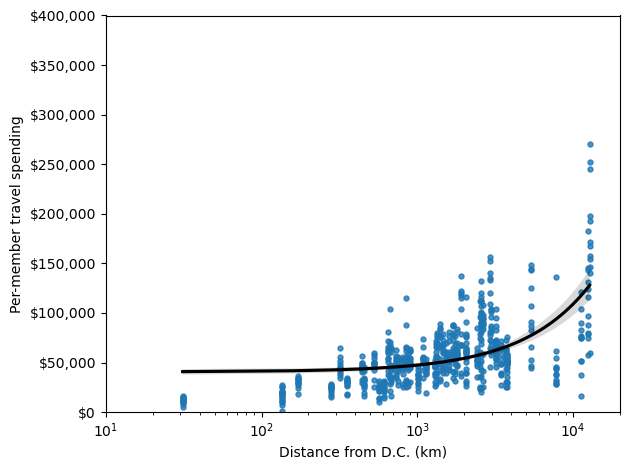

In [144]:
# avg_travel_spending = annual_member_travel_per_member.mean(axis=1).reset_index()
avg_travel_spending = annual_member_travel_per_member.stack().reset_index()
avg_travel_spending.columns = ['state','year','amount']

_merged = pd.merge(
    left = cop_df,
    right = avg_travel_spending,
    left_on = 'STUSAB',
    right_on = 'state',
    how = 'outer'
)

_merged = _merged[_merged['DC_DIST'] > 0]

f,ax = plt.subplots()
sb.regplot(data=_merged,x='DC_DIST',y='amount',line_kws={'color':'k'},scatter_kws={'s':13},ax=ax)
ax.set_xscale('log')
ax.set_xlim((1e1,2e4))
ax.set_xlabel('Distance from D.C. (km)')
ax.set_ylabel('Per-member travel spending')
ax.set_ylim((0,400000))
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

f.tight_layout()
f.savefig('travel_distance.png',dpi=300,bbox_inches='tight')

HC: Pull out the members with the largest deviation/residuals from the trend

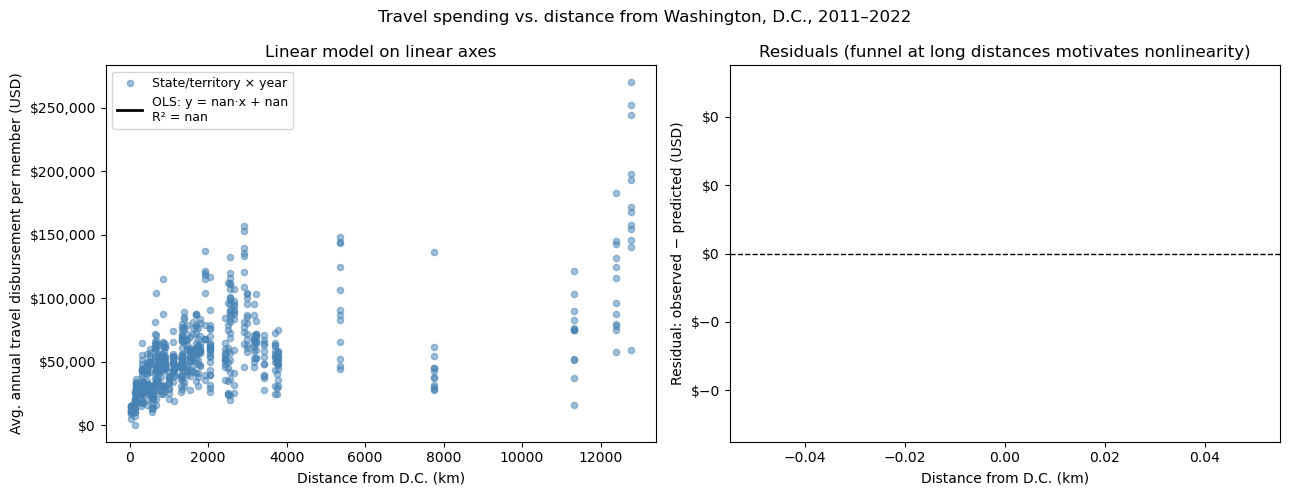

In [145]:
# Figure 13 (revised, R1 to Reviewer 3):
# Reviewer correctly noted that a log distance axis is inconsistent with the
# linear regression model. The revision uses linear–linear axes for the
# model fit panel, and adds a residual panel so the curvature/funnel
# pattern at long distances (which motivates the discussion of nonlinearity
# for far-flung states/territories) is visible.
# Colour key (for caption): steelblue points = state-year observations;
# black line = OLS fit; dashed line in residual panel = zero residual.

dist_travel_reg = stats.linregress(_merged['DC_DIST'], _merged['amount'])

state_yhats = {}
for _state, _dist in cop_df[['STATE_NAME', 'DC_DIST']].values:
    state_yhats[_state] = dist_travel_reg.slope * _dist + dist_travel_reg.intercept
travel_dist_yhat_df = pd.DataFrame(
    data=state_yhats.values(), index=state_yhats.keys(), columns=['yhat']
)
travel_dist_yhat_merged = pd.merge(
    left=_merged, right=travel_dist_yhat_df,
    left_on='STATE_NAME', right_index=True, how='left',
)
travel_dist_yhat_merged['residual'] = (
    travel_dist_yhat_merged['amount'] - travel_dist_yhat_merged['yhat']
)
travel_dist_yhat_merged['residual_pct'] = (
    travel_dist_yhat_merged['residual'] / travel_dist_yhat_merged['amount']
)

f, axs = plt.subplots(1, 2, figsize=(13, 5))

# Panel A: linear–linear, consistent with the linear OLS model.
ax = axs[0]
ax.scatter(
    _merged['DC_DIST'], _merged['amount'],
    alpha=0.5, color='steelblue', s=20, label='State/territory × year',
)
_x = np.linspace(_merged['DC_DIST'].min(), _merged['DC_DIST'].max(), 100)
ax.plot(
    _x, dist_travel_reg.slope * _x + dist_travel_reg.intercept,
    color='black', lw=2,
    label=(f'OLS: y = {dist_travel_reg.slope:.2f}·x + '
           f'{dist_travel_reg.intercept:.0f}\nR² = {dist_travel_reg.rvalue ** 2:.3f}'),
)
ax.set_xlabel('Distance from D.C. (km)')
ax.set_ylabel('Avg. annual travel disbursement per member (USD)')
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
ax.set_title('Linear model on linear axes')
ax.legend(loc='upper left', fontsize=9)

# Panel B: residuals — motivates the nonlinearity discussion.
ax = axs[1]
ax.scatter(
    _merged['DC_DIST'], travel_dist_yhat_merged['residual'],
    alpha=0.5, color='steelblue', s=20,
)
ax.axhline(0, color='black', lw=1, ls='--')
ax.set_xlabel('Distance from D.C. (km)')
ax.set_ylabel('Residual: observed − predicted (USD)')
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
ax.set_title('Residuals (funnel at long distances motivates nonlinearity)')

f.suptitle('Travel spending vs. distance from Washington, D.C., 2011–2022',
           fontsize=12)
f.tight_layout()
f.savefig('distance_travel.png', dpi=300, bbox_inches='tight')


In [146]:
travel_dist_yhat_merged.loc[travel_dist_yhat_merged['residual'].abs().nlargest(20).index]

,STATEFP,STUSAB,STATE_NAME,POPULATION,LATITUDE,LONGITUDE,DC_DIST,state,year,amount,yhat,residual,residual_pct
0,02,AK,Alaska,733391.00,61.41,-148.96,5369.48,AK,2011,143701.57,NaN,NaN,NaN
1,02,AK,Alaska,733391.00,61.41,-148.96,5369.48,AK,2012,148198.44,NaN,NaN,NaN
2,02,AK,Alaska,733391.00,61.41,-148.96,5369.48,AK,2013,90550.37,NaN,NaN,NaN
3,02,AK,Alaska,733391.00,61.41,-148.96,5369.48,AK,2014,144266.27,NaN,NaN,NaN
4,02,AK,Alaska,733391.00,61.41,-148.96,5369.48,AK,2015,65804.14,NaN,NaN,NaN
5,02,AK,Alaska,733391.00,61.41,-148.96,5369.48,AK,2016,106577.65,NaN,NaN,NaN
6,02,AK,Alaska,733391.00,61.41,-148.96,5369.48,AK,2017,82992.10,NaN,NaN,NaN
7,02,AK,Alaska,733391.00,61.41,-148.96,5369.48,AK,2018,124799.67,NaN,NaN,NaN
8,02,AK,Alaska,733391.00,61.41,-148.96,5369.48,AK,2019,86709.95,NaN,NaN,NaN
9,02,AK,Alaska,733391.00,61.41,-148.96,5369.48,AK,2020,52647.07,NaN,NaN,NaN


In [147]:
travel_dist_yhat_merged.loc[travel_dist_yhat_merged['residual_pct'].abs().nlargest(20).index,'STATE_NAME'].value_counts()

STATE_NAME
Alaska     12
Alabama     8
Name: count, dtype: int64

In [148]:
travel_dist_yhat_merged.loc[travel_dist_yhat_merged['residual_pct'].abs().nlargest(20).index,:]

,STATEFP,STUSAB,STATE_NAME,POPULATION,LATITUDE,LONGITUDE,DC_DIST,state,year,amount,yhat,residual,residual_pct
0,02,AK,Alaska,733391.00,61.41,-148.96,5369.48,AK,2011,143701.57,NaN,NaN,NaN
1,02,AK,Alaska,733391.00,61.41,-148.96,5369.48,AK,2012,148198.44,NaN,NaN,NaN
2,02,AK,Alaska,733391.00,61.41,-148.96,5369.48,AK,2013,90550.37,NaN,NaN,NaN
3,02,AK,Alaska,733391.00,61.41,-148.96,5369.48,AK,2014,144266.27,NaN,NaN,NaN
4,02,AK,Alaska,733391.00,61.41,-148.96,5369.48,AK,2015,65804.14,NaN,NaN,NaN
5,02,AK,Alaska,733391.00,61.41,-148.96,5369.48,AK,2016,106577.65,NaN,NaN,NaN
6,02,AK,Alaska,733391.00,61.41,-148.96,5369.48,AK,2017,82992.10,NaN,NaN,NaN
7,02,AK,Alaska,733391.00,61.41,-148.96,5369.48,AK,2018,124799.67,NaN,NaN,NaN
8,02,AK,Alaska,733391.00,61.41,-148.96,5369.48,AK,2019,86709.95,NaN,NaN,NaN
9,02,AK,Alaska,733391.00,61.41,-148.96,5369.48,AK,2020,52647.07,NaN,NaN,NaN


In [149]:
travel_dist_yhat_merged.loc[travel_dist_yhat_merged['residual_pct'].nlargest(20).index,:]

,STATEFP,STUSAB,STATE_NAME,POPULATION,LATITUDE,LONGITUDE,DC_DIST,state,year,amount,yhat,residual,residual_pct
0,02,AK,Alaska,733391.00,61.41,-148.96,5369.48,AK,2011,143701.57,NaN,NaN,NaN
1,02,AK,Alaska,733391.00,61.41,-148.96,5369.48,AK,2012,148198.44,NaN,NaN,NaN
2,02,AK,Alaska,733391.00,61.41,-148.96,5369.48,AK,2013,90550.37,NaN,NaN,NaN
3,02,AK,Alaska,733391.00,61.41,-148.96,5369.48,AK,2014,144266.27,NaN,NaN,NaN
4,02,AK,Alaska,733391.00,61.41,-148.96,5369.48,AK,2015,65804.14,NaN,NaN,NaN
5,02,AK,Alaska,733391.00,61.41,-148.96,5369.48,AK,2016,106577.65,NaN,NaN,NaN
6,02,AK,Alaska,733391.00,61.41,-148.96,5369.48,AK,2017,82992.10,NaN,NaN,NaN
7,02,AK,Alaska,733391.00,61.41,-148.96,5369.48,AK,2018,124799.67,NaN,NaN,NaN
8,02,AK,Alaska,733391.00,61.41,-148.96,5369.48,AK,2019,86709.95,NaN,NaN,NaN
9,02,AK,Alaska,733391.00,61.41,-148.96,5369.48,AK,2020,52647.07,NaN,NaN,NaN


#### Office building proximity

In [150]:
annual_category_spending = pd.pivot_table(
    data = members_df,
    index = ['YEAR','BIOGUIDE_ID'],
    columns = ['CATEGORY'],
    values = 'AMOUNT',
    aggfunc = 'sum'
)

# Filter to relevant years and columns
annual_category_spending = annual_category_spending.loc[2015:,top_cats]

# Calculate z-scores for spending in each category
# annual_category_spending_zscore = annual_category_spending.groupby(level=0).apply(stats.zscore,nan_policy='omit')
# annual_category_spending_zscore.index = annual_category_spending_zscore.index.droplevel(0)

annual_category_spending_office = pd.merge(
    left = annual_category_spending.reset_index(),
    right = member_office_df,
    left_on = ['BIOGUIDE_ID','YEAR'],
    right_on = ['bioguideID','year'],
    how = 'inner'
)

annual_category_spending_office['YEAR'] = annual_category_spending_office['YEAR'].astype('Int64')

annual_category_spending_office.head()

,YEAR,BIOGUIDE_ID,PERSONNEL COMPENSATION,FRANKED MAIL,TRAVEL,RENT COMMUNICATION UTILITIES,PRINTING AND REPRODUCTION,OTHER SERVICES,SUPPLIES AND MATERIALS,EQUIPMENT,year,bioguideID,office-building,office-room,office-floor


In [152]:
within_floor_std = annual_category_spending_office.groupby(['YEAR','office-floor']).agg({i:np.std for i in top_cats})

within_building_std = annual_category_spending_office.groupby(['YEAR','office-building']).agg({i:np.std for i in top_cats})

within_year_std = annual_category_spending_office.groupby(['YEAR']).agg({i:np.std for i in top_cats})


In [ ]:
_df = within_floor_std.loc[2015].apply(stats.zscore)

pw_df = pd.DataFrame(
    data = 1 - squareform(pdist(_df,'cosine')),
    columns = _df.index,
    index = _df.index
)

sb.heatmap(pw_df)

## Textual anomalies

HC: Benford's for words  
HC: Variance in payee, purpose, etc. by category or is it drop-down  
HC: Consistency in purposes within categories - confirm that some purposes only belong to specific categories/payees. Find a good, bad, and ugly  
HC: Dictionary-based approach of unexpected or undesireable words found in corpus  
HC: Fuzzy matching  

People showing up as payee under supplies? "GRONEMAN BELINDA M." as "OFFICE SUPPLIES (OUTSIDE)"

In [154]:
members_df.loc[members_df['CATEGORY'] == 'SUPPLIES AND MATERIALS']#,'PURPOSE'].value_counts()

,YEAR-QUARTER,YEAR,QUARTER,TERM_QUARTER,BIOGUIDE_ID,OFFICE,PROGRAM,CATEGORY,PAYEE,PURPOSE,AMOUNT,DATE,PERIOD_DATE,DATE_IS_RECONSTRUCTED,START DATE,END DATE,TRANSCODE,RECORDID,VOUCHER_ID
6515,2011Q1,2011,Q1,1,A000022,HON. GARY L. ACKERMAN,NaN,SUPPLIES AND MATERIALS,HAGUE QUALITY WATER,BOTTLED WATER,63.00,2011-01-14,2011-01-14,False,2011-01-08,2011-02-07,AP,00071155,HAGUE QUALITY WATER
6516,2011Q1,2011,Q1,1,A000022,HON. GARY L. ACKERMAN,NaN,SUPPLIES AND MATERIALS,ALLIANCE MICRO,OFFICE SUPPLIES (OUTSIDE),30.00,2011-01-24,2011-01-24,False,2011-01-20,2011-01-20,AP,00078604,ALLIANCE MICRO
6517,2011Q1,2011,Q1,1,A000022,HON. GARY L. ACKERMAN,NaN,SUPPLIES AND MATERIALS,NaN,OFFICE SUPPLY (TRANSFER),371.82,2011-01-31,2011-01-31,False,2011-01-01,2011-01-31,GL,RMS0004671,NaN
6518,2011Q1,2011,Q1,1,A000022,HON. GARY L. ACKERMAN,NaN,SUPPLIES AND MATERIALS,NaN,OFFICE SUPPLY (TRANSFER),783.46,2011-02-28,2011-02-28,False,2011-02-01,2011-02-28,GL,RMS0005839,NaN
6519,2011Q1,2011,Q1,1,A000022,HON. GARY L. ACKERMAN,NaN,SUPPLIES AND MATERIALS,HAGUE QUALITY WATER,BOTTLED WATER,63.00,2011-03-02,2011-03-02,False,2011-02-08,2011-03-07,AP,00104249,HAGUE QUALITY WATER
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4779540,2022Q4,2022,Q4,8,Z000017,2022 HON. LEE M. ZELDIN,OFFICIAL EXPENSES OF MEMBERS,SUPPLIES AND MATERIALS,CITI PCARD-NEWSDAY SUBSCRIPTION,PUBLICATIONS/REFERENCE MAT'L,-4.55,2022-12-19,2022-12-19,False,2022-11-12,2022-11-12,AP,1619972,33707
4779541,2022Q4,2022,Q4,8,Z000017,2022 HON. LEE M. ZELDIN,OFFICIAL EXPENSES OF MEMBERS,SUPPLIES AND MATERIALS,CITI PCARD-PUNCHBOWL.NEWS,MISC. SUPPLIES & MATERIALS,31.80,2022-12-19,2022-12-19,False,2022-11-01,2022-11-30,AP,1619972,33707
4779542,2022Q4,2022,Q4,8,Z000017,2022 HON. LEE M. ZELDIN,OFFICIAL EXPENSES OF MEMBERS,SUPPLIES AND MATERIALS,CITI PCARD-READYREFRESH/WATERSERV,OFFICE SUPPLIES (OUTSIDE),140.87,2022-12-19,2022-12-19,False,2022-10-27,2022-11-26,AP,1619972,33707
4779543,2022Q4,2022,Q4,8,Z000017,2022 HON. LEE M. ZELDIN,OFFICIAL EXPENSES OF MEMBERS,SUPPLIES AND MATERIALS,CITI PCARD-READYREFRESH/WATERSERV,OFFICE SUPPLIES (OUTSIDE),-9.40,2022-12-19,2022-12-19,False,2022-10-29,2022-10-29,AP,1619972,33707


In [155]:
members_df[members_df['PAYEE'].fillna('').str.lower().str.contains('disney')]

,YEAR-QUARTER,YEAR,QUARTER,TERM_QUARTER,BIOGUIDE_ID,OFFICE,PROGRAM,CATEGORY,PAYEE,PURPOSE,AMOUNT,DATE,PERIOD_DATE,DATE_IS_RECONSTRUCTED,START DATE,END DATE,TRANSCODE,RECORDID,VOUCHER_ID
3772805,2020Q2,2020,Q2,6,S001200,2020 HON. DARREN SOTO,OFFICIAL EXPENSES OF MEMBERS,RENT COMMUNICATION UTILITIES,CITI PCARD-DISNEY RESORTS-RESE,TEMPORARY SPACE RENTAL,1816.05,2020-06-17,2020-06-17,False,2020-03-09,2020-03-09,AP,1301303,NaN
3772886,2020Q2,2020,Q2,6,S001200,2020 HON. DARREN SOTO,OFFICIAL EXPENSES OF MEMBERS,SUPPLIES AND MATERIALS,CITI PCARD-DISNEY RESORTS-RESE,FOOD & BEVERAGE,183.95,2020-06-17,2020-06-17,False,2020-03-09,2020-03-09,AP,1301303,NaN


In [156]:
members_df[members_df['PAYEE'].fillna('').str.lower().str.contains('golf')]

,YEAR-QUARTER,YEAR,QUARTER,TERM_QUARTER,BIOGUIDE_ID,OFFICE,PROGRAM,CATEGORY,PAYEE,PURPOSE,AMOUNT,DATE,PERIOD_DATE,DATE_IS_RECONSTRUCTED,START DATE,END DATE,TRANSCODE,RECORDID,VOUCHER_ID
29182,2011Q1,2011,Q1,1,D000197,HON. DIANA DEGETTE,NaN,SUPPLIES AND MATERIALS,PARK HILL GOLF CLUB,FOOD & BEVERAGE,3467.26,2011-03-07,2011-03-07,False,2011-02-01,2011-02-03,AP,00108127,PARK HILL GOLF CLUB
136712,2011Q2,2011,Q2,2,C000059,HON. KEN CALVERT,NaN,SUPPLIES AND MATERIALS,EAGLE GLEN GOLF CLUB,FOOD & BEVERAGE,822.15,2011-06-24,2011-06-24,False,2011-06-11,2011-06-11,AP,00202664,EAGLE GLEN GOLF CLUB
157383,2011Q2,2011,Q2,2,G000377,HON. KAY GRANGER,NaN,SUPPLIES AND MATERIALS,FOSSIL CREEK GOLF CLUB,FOOD & BEVERAGE,172.79,2011-06-06,2011-06-06,False,2011-01-20,2011-01-20,AP,00182880,FOSSIL CREEK GOLF CLUB
183356,2011Q2,2011,Q2,2,M001154,HON. BRAD MILLER,NaN,SUPPLIES AND MATERIALS,CASWELL PINES GOLF COURSE,FOOD & BEVERAGE,250.00,2011-04-21,2011-04-21,False,2011-03-21,2011-03-21,AP,00142196,CASWELL PINES GOLF COURSE
470201,2012Q1,2012,Q1,5,D000197,HON. DIANA DEGETTE,NaN,SUPPLIES AND MATERIALS,PARK HILL GOLF CLUB,FOOD & BEVERAGE,2264.18,2012-02-29,2012-02-29,False,2012-02-22,2012-02-22,AP,00391106,PARK HILL GOLF CLUB
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4155938,2021Q3,2021,Q3,3,B001302,2021 HON. ANDY BIGGS,OFFICIAL EXPENSES OF MEMBERS,SUPPLIES AND MATERIALS,CITI PCARD-TOPGOLF GILBERT 014-2,LEGISLATIVE PLNNG FOOD AND BEV,278.60,2021-08-31,2021-08-31,False,2021-08-16,2021-08-16,AP,1460212,NaN
4384136,2022Q1,2022,Q1,5,G000553,2022 HON. AL GREEN,OFFICIAL EXPENSES OF MEMBERS,SUPPLIES AND MATERIALS,CITI PCARD-QUAIL VALLEY GOLF COURSE,FOOD & BEVERAGE,301.14,2022-03-15,2022-03-15,False,2022-02-12,2022-02-12,AP,1535060,NaN
4668135,2022Q3,2022,Q3,7,W000823,2022 HON. MICHAEL WALTZ,OFFICIAL EXPENSES OF MEMBERS,RENT COMMUNICATION UTILITIES,HALIFAX GOLF CLUB LLC,TEMPORARY SPACE RENTAL,200.00,2022-08-05,2022-08-05,False,2022-05-21,2022-05-21,AP,X0016150,NaN
4668200,2022Q3,2022,Q3,7,W000823,2022 HON. MICHAEL WALTZ,OFFICIAL EXPENSES OF MEMBERS,SUPPLIES AND MATERIALS,HALIFAX GOLF CLUB LLC,FOOD & BEVERAGE,360.00,2022-08-05,2022-08-05,False,2022-05-21,2022-05-21,AP,X0016150,NaN


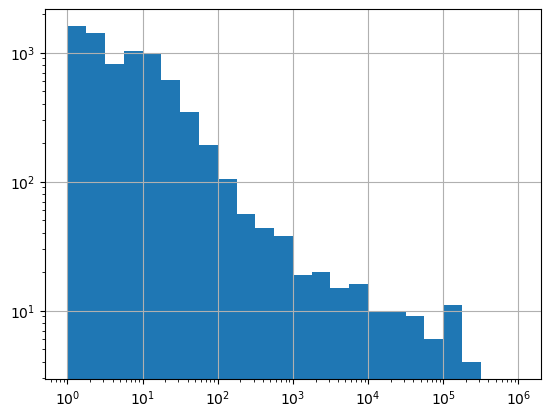

In [157]:
ax = pd.Series(members_df['PURPOSE'].value_counts().values).hist(bins=np.logspace(0,6,25))
ax.set_xscale('log')
ax.set_yscale('log')

In [158]:
members_df[members_df['PAYEE'].fillna('').str.contains('GRONEMAN')]

,YEAR-QUARTER,YEAR,QUARTER,TERM_QUARTER,BIOGUIDE_ID,OFFICE,PROGRAM,CATEGORY,PAYEE,PURPOSE,AMOUNT,DATE,PERIOD_DATE,DATE_IS_RECONSTRUCTED,START DATE,END DATE,TRANSCODE,RECORDID,VOUCHER_ID
1701911,2015Q1,2015,Q1,1,Z000017,HON. LEE M. ZELDIN,NaN,PERSONNEL COMPENSATION,"GRONEMAN,BELINDA M",CONGRESSIONAL AIDE,8583.34,NaT,2015-02-01,True,2015-02-01,2015-03-31,NaN,NaN,"GRONEMAN,BELINDA M"
1798272,2015Q2,2015,Q2,2,Z000017,HON. LEE M. ZELDIN,NaN,PERSONNEL COMPENSATION,"GRONEMAN,BELINDA M",CONGRESSIONAL AIDE,12875.01,NaT,2015-04-01,True,2015-04-01,2015-06-30,NaN,NaN,"GRONEMAN,BELINDA M"
1798308,2015Q2,2015,Q2,2,Z000017,HON. LEE M. ZELDIN,NaN,TRAVEL,"GRONEMAN, BELINDA M",TRAVEL SUBSISTENCE,1984.75,2015-05-08,2015-05-08,False,2015-04-12,2015-04-12,AP,E0276948,"GRONEMAN, BELINDA M"
1798447,2015Q2,2015,Q2,2,Z000017,HON. LEE M. ZELDIN,NaN,SUPPLIES AND MATERIALS,"GRONEMAN, BELINDA M",FOOD & BEVERAGE,239.18,2015-06-30,2015-06-30,False,2015-02-06,2015-02-06,AP,E0294888,"GRONEMAN, BELINDA M"
1798448,2015Q2,2015,Q2,2,Z000017,HON. LEE M. ZELDIN,NaN,SUPPLIES AND MATERIALS,"GRONEMAN, BELINDA M",FOOD & BEVERAGE,156.81,2015-06-30,2015-06-30,False,2015-03-12,2015-03-12,AP,E0294888,"GRONEMAN, BELINDA M"
1889992,2015Q3,2015,Q3,3,Z000017,HON. LEE M. ZELDIN,NaN,PERSONNEL COMPENSATION,"GRONEMAN,BELINDA M",CONGRESSIONAL AIDE,12875.01,NaT,2015-07-01,True,2015-07-01,2015-09-30,NaN,NaN,"GRONEMAN,BELINDA M"
1985565,2015Q4,2015,Q4,4,Z000017,HON. LEE M. ZELDIN,NaN,PERSONNEL COMPENSATION,"GRONEMAN,BELINDA M",CONGRESSIONAL AIDE,13635.01,NaT,2015-10-01,True,2015-10-01,2015-12-31,NaN,NaN,"GRONEMAN,BELINDA M"
2087460,2016Q1,2016,Q1,5,Z000017,HON. LEE M. ZELDIN,NaN,PERSONNEL COMPENSATION,"GRONEMAN,BELINDA M",CONGRESSIONAL AIDE,12588.90,NaT,2016-01-03,True,2016-01-03,2016-03-31,NaN,NaN,"GRONEMAN,BELINDA M"
2087557,2016Q1,2016,Q1,5,Z000017,HON. LEE M. ZELDIN,NaN,PERSONNEL COMPENSATION,"GRONEMAN,BELINDA M",CONGRESSIONAL AIDE,286.11,NaT,2016-01-01,True,2016-01-01,2016-01-02,NaN,NaN,"GRONEMAN,BELINDA M"
2187774,2016Q2,2016,Q2,6,Z000017,HON. LEE M. ZELDIN,NaN,PERSONNEL COMPENSATION,"GRONEMAN,BELINDA M",CONGRESSIONAL AIDE,12875.01,NaT,2016-04-01,True,2016-04-01,2016-06-30,NaN,NaN,"GRONEMAN,BELINDA M"


In [159]:
members_df.loc[members_df['PAYEE'].fillna('').str.contains('GRONEMAN'),'PAYEE'].unique()

<StringArray>
[ 'GRONEMAN,BELINDA M', 'GRONEMAN, BELINDA M',  'GRONEMAN BELINDA M',
 'GRONEMAN BELINDA M.']
Length: 4, dtype: str

## Relational anomalies

HC: More than one anomaly across tests, are there anomalies robust across types of tests?  
BK: Aides working for multiple offices in a single year?   
HC: Relationships within data + relationships among anomalies  

In [160]:
personnel_compensation_df = members_df[members_df['CATEGORY'] == 'PERSONNEL COMPENSATION']

annual_office_personnel_df = personnel_compensation_df.groupby(['YEAR','BIOGUIDE_ID','PAYEE']).agg({'AMOUNT':'sum'})
annual_office_personnel_df.reset_index(inplace=True)
annual_office_personnel_df.dropna(subset=['PAYEE'],inplace=True)
annual_office_personnel_df.head()

,YEAR,BIOGUIDE_ID,PAYEE,AMOUNT
0,2011,A000014,"WESTFALL, ERIN K",-16.67
1,2011,A000022,"BERRY, UNA M",80000.04
2,2011,A000022,"BRIANCON,ALICIA V",13124.98
3,2011,A000022,"CONNOLLY, BRENDA J",58705.59
4,2011,A000022,"CRAMER,VANESSA L",5833.33


Try to clean up PAYEE names.

In [161]:
yq_total_personnel = personnel_compensation_df.groupby(['YEAR-QUARTER','BIOGUIDE_ID','PAYEE']).agg({'AMOUNT':'sum'})
yq_total_personnel.reset_index(inplace=True)
yq_total_personnel['PAYEE_CLEANED'] = np.nan

In [162]:
def name_reorganizer(s):
    _split_l = s.strip().split(' ')
    _len = len(_split_l)
    if _len == 1:
        return _split_l
    elif _len == 2:
        return _split_l[-1] + ' ' + _split_l[0]
    elif _len == 3:
        return _split_l[-2] + ' ' + _split_l[-1] + ' ' + _split_l[0]
    elif _len == 4:
        return _split_l[-2] + ' ' + _split_l[-1] + ' ' + _split_l[0] + ' ' + _split_l[1]
    elif _len == 5:
        return _split_l[-2] + ' ' + _split_l[-1] + ' ' + _split_l[0] + ' ' + _split_l[1] + ' ' + _split_l[2]

In [164]:
_s = yq_total_personnel.groupby('YEAR-QUARTER').agg({'PAYEE':lambda x:x.str.contains(',').sum()})['PAYEE']
comma_in_name_quarters = _s[_s > 0].index

# Filter to quarters where there are commas present
pre_2016Q4 = yq_total_personnel['YEAR-QUARTER'].isin(comma_in_name_quarters)

# Make a series that separates PAYEE on commas and counts the number of name elements -- ideally 2
name_array_len_sep_comma = yq_total_personnel.loc[pre_2016Q4,'PAYEE'].str.split(',').apply(len)

# Re-order names with exactly two name elements and additional cleanup
exactly_2 = name_array_len_sep_comma[name_array_len_sep_comma == 2]
pre_2016Q4_cleaned_names = yq_total_personnel.loc[exactly_2.index,'PAYEE'].str.split(',').apply(lambda x:x[1] + ' ' + x[0])
pre_2016Q4_cleaned_names = pre_2016Q4_cleaned_names.str.replace('  ', ' ').str.strip()

# Filter to quarters where there are no commas present
post_2016Q4 = ~yq_total_personnel['YEAR-QUARTER'].isin(comma_in_name_quarters)
post_2016Q4_cleaned_names = yq_total_personnel.loc[post_2016Q4,'PAYEE']
post_2016Q4_cleaned_names = post_2016Q4_cleaned_names.str.replace('  ', ' ').str.strip()
post_2016Q4_cleaned_names = post_2016Q4_cleaned_names.apply(name_reorganizer)

# Assign back to a new column
yq_total_personnel.loc[pre_2016Q4_cleaned_names.index,'PAYEE_CLEANED'] = pre_2016Q4_cleaned_names
yq_total_personnel.loc[post_2016Q4_cleaned_names.index,'PAYEE_CLEANED'] = post_2016Q4_cleaned_names

# Remove periods from names
yq_total_personnel.loc[:,'PAYEE_CLEANED'] = yq_total_personnel.loc[:,'PAYEE_CLEANED'].str.replace('.','').fillna('')
yq_total_personnel['PAYEE_CLEANED'] = yq_total_personnel['PAYEE_CLEANED'].replace({'T E ANFINSON':'THOMAS E ANFINSON'})

TypeError: Invalid value '<StringArray>
[     'ERIN K WESTFALL',          'UNA M BERRY',    'BRENDA J CONNOLLY',
     'VANESSA L CRAMER',       'HOWARD DIAMOND',        'JARED A FROST',
      'DANIEL F GETMAN',      'JORDAN H GOLDES',    'JEFFREY O GUILLOT',
   'JACQUELINE A HSIEH',
 ...
 'GEORGE R MCKEMEY III',     'MATTHEW W PITZER',       'JUDITH F ROLFE',
      'WILLIAM R SELPH',     'LACEY A SMETHERS',    'MAGGIE J STEFFENS',
  'ALEXANDER J STERHAN',      'HEATHER N SWIFT',       'AARON J THIELE',
          'RANDY VOGEL']
Length: 192311, dtype: str' for dtype 'float64'

In [165]:
yq_total_personnel_filtered = yq_total_personnel[yq_total_personnel['AMOUNT'] >= 1000]

_agg = {'AMOUNT':'sum'}
personnel_el_df = yq_total_personnel_filtered.groupby(['YEAR-QUARTER','BIOGUIDE_ID','PAYEE_CLEANED']).agg(_agg)
# personnel_el_df.index.names = ['yearquarter','id','payee']
personnel_el_df.reset_index(inplace=True)
personnel_el_df['member'] = personnel_el_df['BIOGUIDE_ID'].map(member_names_map).str.upper()
personnel_el_df.columns = ['yearquarter','id','payee','amount','member']

personnel_el_df[['gender','party']] = personnel_el_df['id'].apply(lambda x:pd.Series(bioguide_gender_party_map.get(x)))
personnel_el_df.dropna(subset=['member'],inplace=True)

filtered_personnel_el = personnel_el_df[personnel_el_df['party'].isin(['D','R'])]

ValueError: Columns must be same length as key

In [ ]:
personnel_bp_g = nx.from_pandas_edgelist(
    df = filtered_personnel_el,
    source = 'member',
    target = 'payee',
    edge_attr = ['amount']
)

nx.write_gexf(personnel_bp_g,'personnel_bp.gexf')

personnel_bp_g.number_of_nodes(), personnel_bp_g.number_of_edges()

In [ ]:
set(personnel_el_df['member']) & set(personnel_el_df['payee'])

In [ ]:
personnel_el_df[~personnel_el_df['party'].isin(['D','R','I'])]

In [ ]:
personnel_attrs = filtered_personnel_el.groupby('payee').agg({'party':'unique','gender':'unique'})
personnel_attrs['party'] = personnel_attrs['party'].fillna('').apply(sorted).str.join(',')
personnel_attrs['gender'] = personnel_attrs['gender'].fillna('').apply(sorted).str.join(',')
personnel_attrs['joint'] = personnel_attrs['party'] + ',' + personnel_attrs['gender']

personnel_attrs['joint'].value_counts()

In [ ]:
personnel_proj_g = nx.bipartite.projection.weighted_projected_graph(personnel_bp_g,filtered_personnel_el['payee'].unique())

joint_d = personnel_attrs['joint'].to_dict()
for node,d in personnel_proj_g.nodes(data=True):
    d['joint'] = joint_d.get(node,'')

nx.write_gexf(personnel_proj_g,'personnel_proj.gexf')

personnel_proj_g.number_of_nodes(), personnel_proj_g.number_of_edges()


### Figure 12 — inline rendering (revised)

Per Reviewer 1, the previous party-and-gender encoding was illegible. The revision drops the gender split and renders the network inline at landscape aspect ratio using party-only colours. The `.gexf` export above is preserved for higher-resolution layout in Gephi if desired.

In [121]:
# Figure 12 (revised, R1 to Reviewer 1 and Reviewer 3):
# Inline NetworkX rendering of the staff co-employment projection.
# Gender encoding dropped (Reviewer 1's suggestion); only party affiliation
# is encoded.
# Colour key (for caption): blue = staff who only ever worked for
# Democratic offices; red = Republican-only; purple = bipartisan
# (worked for both parties at any point).

# Determine each staff member's party history.
staff_party = {}
for payee, group in filtered_personnel_el.groupby('payee'):
    has_d = (group['party'] == 'D').any()
    has_r = (group['party'] == 'R').any()
    if has_d and has_r:
        staff_party[payee] = 'B'
    elif has_d:
        staff_party[payee] = 'D'
    elif has_r:
        staff_party[payee] = 'R'

color_map = {'D': '#3274A1', 'R': '#C44E52', 'B': '#8172B2'}

# Filter to staff with non-trivial weighted degree for readability.
node_strength = dict(personnel_proj_g.degree(weight='weight'))
viz_nodes = [n for n, s in node_strength.items() if s >= 10]
viz_subgraph = personnel_proj_g.subgraph(viz_nodes).copy()
viz_subgraph.remove_nodes_from(list(nx.isolates(viz_subgraph)))

print(f"Rendering {viz_subgraph.number_of_nodes():,} nodes and "
      f"{viz_subgraph.number_of_edges():,} edges")

# Layout
pos = nx.spring_layout(viz_subgraph, k=0.15, seed=42, iterations=50)
node_colors = [color_map.get(staff_party.get(n), '#999999') for n in viz_subgraph.nodes()]

# Landscape figure (Reviewer 1: "full-page landscape orientation would help").
f, ax = plt.subplots(figsize=(16, 10))
nx.draw_networkx_edges(viz_subgraph, pos, ax=ax, alpha=0.08,
                       width=0.3, edge_color='grey')
nx.draw_networkx_nodes(viz_subgraph, pos, ax=ax, node_color=node_colors,
                       node_size=14, alpha=0.85, linewidths=0)
ax.axis('off')
ax.set_title("Staff co-employment network (projected onto staff)", fontsize=14)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#3274A1',
           markersize=10, label='Democratic offices only'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#C44E52',
           markersize=10, label='Republican offices only'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#8172B2',
           markersize=10, label='Bipartisan (both parties)'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=11, frameon=True)

f.tight_layout()
f.savefig('staff_network.png', dpi=200, bbox_inches='tight', facecolor='white')


NameError: name 'filtered_personnel_el' is not defined

### Revised summary of staff affiliations

Reviewer 3 asked how the mean number of affiliations could be `1.31 ± 2.02` when the minimum and median are 1. The mean ± SD summary is misleading for this extremely right-skewed distribution. The revised summary reports median, IQR, max, and tail shares instead.

In [ ]:
# Revised affiliation summary (R1 to Reviewer 3):
# Mean ± SD is misleading for a heavily right-skewed count distribution with
# median 1 and minimum 1. Report median, IQR, max, and tail shares.

affil_counts = all_bio_payee_el_df.groupby('payee')['member'].nunique()

print(f"Number of distinct member offices per staffer:")
print(f"  N staffers:                          {len(affil_counts):,}")
print(f"  Minimum:                             {int(affil_counts.min())}")
print(f"  Median:                              {affil_counts.median():.0f}")
print(f"  Interquartile range:                 [{int(affil_counts.quantile(0.25))}, {int(affil_counts.quantile(0.75))}]")
print(f"  Mean (skew-sensitive, see caveat):   {affil_counts.mean():.2f}")
print(f"  Standard deviation:                  {affil_counts.std():.2f}")
print(f"  Maximum:                             {int(affil_counts.max())}")
print(f"  Share with exactly 1 office:         {(affil_counts == 1).mean() * 100:.1f}%")
print(f"  Share with >= 5  offices:            {(affil_counts >= 5 ).mean() * 100:.1f}%")
print(f"  Share with >= 10 offices:            {(affil_counts >= 10).mean() * 100:.1f}%")
print(f"  Share with >= 50 offices:            {(affil_counts >= 50).mean() * 100:.1f}%")


In [ ]:
all_bio_payee_el_df = yq_total_personnel_filtered.groupby(['BIOGUIDE_ID','PAYEE_CLEANED']).agg({'AMOUNT':'sum'})
all_bio_payee_el_df.reset_index(inplace=True)
all_bio_payee_el_df.columns = ['id','payee','amount']

all_bio_payee_el_df['payee'].value_counts().head(20)

In [ ]:
top_payees = ['KRYSTAL C KAAI','MICHAEL P DARNER','BRADLEY M BAUMAN','MARIA L LAVERDIERE', 'JOHN D GROM']
_df = yq_total_personnel_filtered.loc[yq_total_personnel_filtered['PAYEE_CLEANED'].isin(top_payees),:]

pd.pivot_table(
    data = _df,
    index = 'YEAR-QUARTER',
    columns = 'PAYEE_CLEANED',
    values = 'AMOUNT',
    aggfunc = 'sum'
).describe()

In [ ]:
all_bio_payee_el_df['payee'].value_counts()

What's up with the Anfinsons?

In [ ]:
_df = yq_total_personnel[yq_total_personnel['PAYEE_CLEANED'].str.contains('ANFINSON')]

pd.pivot_table(
    data = _df,
    index = 'YEAR-QUARTER',
    columns = 'PAYEE_CLEANED',
    values = 'BIOGUIDE_ID',
    aggfunc = 'nunique'
)

In [ ]:
pd.pivot_table(
    data = _df,
    index = 'YEAR-QUARTER',
    columns = 'PAYEE_CLEANED',
    values = 'AMOUNT',
    aggfunc = 'sum'
)

In [ ]:
space_count = yq_total_personnel.loc[:,'PAYEE'].str.split(' ').apply(len)
yq_total_personnel.loc[space_count == 6,'PAYEE_CLEANED']

In [ ]:
post_2016Q4_cleaned_names

In [ ]:
yq_total_personnel.loc[~yq_total_personnel['YEAR-QUARTER'].isin(comma_in_name_quarters),'PAYEE'].apply(name_reorganizer)

In [ ]:
yq_total_personnel.loc[yq_total_personnel['PAYEE'].str.contains('FALKOWSKI'),'YEAR-QUARTER'].values

In [ ]:
yq_total_personnel['PAYEE_CLEANED'].value_counts()

In [ ]:
annual_personnel_to_2016 = annual_office_personnel_df.loc[annual_office_personnel_df['YEAR'] <= 2015,:]
annual_personnel_to_2016[annual_personnel_to_2016.loc[:,'PAYEE'].str.split(',').apply(len) == 1]

#


In [ ]:
annual_office_personnel_df[annual_office_personnel_df['PAYEE'].str.contains('VENDOR')]

## Other data sources

HC: Spending based on ethical rhetoric on social media, public statements, legislation sponsored  
HC: George Santos! Let's look at his spending  
HC: Use House Ethics history to flag members who have previously been subject of an investigation